In [1]:
from pathlib import Path
import pandas as pd
from timesnet_encoder import TimesBlock
from sequences_peaks import SequenceConfig, _load_sequence_dataframe, _load_signal_from_row, _generate_peak_mask, TrainSequence, ValidationSequence, _wavelet_filter
from dataclasses import replace
from utils import setup_gpu
setup_gpu(memory_fraction=0.7)


2026-04-20 10:59:31.938229: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-20 10:59:31.938257: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-20 10:59:31.939086: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-20 10:59:31.943352: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


gpus: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-04-20 10:59:34.751390: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-20 10:59:34.757597: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-20 10:59:34.759501: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:
import os
from datetime import datetime

# Klasör ismini bugünün tarihiyle oluştur
date_str = datetime.now().strftime("%Y%m%d")
MODEL_FOLDER = f"{date_str}-GAN-v4.5"

# Klasörleri yarat
os.makedirs(MODEL_FOLDER, exist_ok=True)
os.makedirs(f"{MODEL_FOLDER}/weights", exist_ok=True) # Ağırlıklar buraya

# description.txt dosyasını oluştur ve yaz
description_text = """
MODEL VERSİYONU: GAN v4.5 (Style Transfer / Referanslı Koşullu GAN)

MİMARİ ÖZETİ:
1. ENCODER (Stil Çıkarıcı): 
   - Girdi: [Ham Sinyal (Z-Score), Peak Maskesi]
   - Görevi: Sinyalin arka plan gürültüsünü, zemin yapısını ve yürüme sertliğini analiz edip 512 boyutlu bir DNA'ya (z_encoded) sıkıştırmak. Konum bilgisini ezer.

2. GENERATOR (Sentezleyici):
   - Girdi: [z_encoded (Stil), Peak Maskesi (Şablon)]
   - Görevi: Encoder'dan gelen stili (boya paletini) kullanarak, Peak maskesinin (şablonun) gösterdiği noktalara yepyeni, %100 gerçekçi yürüme peakleri inşa etmek.

3. DISCRIMINATOR (Koşullu Hakem):
   - Girdi: [Sinyal, Peak Maskesi]
   - Görevi: Sinyalin "DAS formatında" olup olmadığını VE maske noktalarıyla uyumlu olup olmadığını aynı anda denetlemek.

VERİ VE ÇİZİM MANTIĞI:
- Model, Classifier'ın (clf939.h5) doğru karar verebilmesi için tamamen GÜRÜLTÜLÜ (Raw) DAS sinyalleriyle eğitilmiştir.
- Görselleştirme (Epoch sonu çizimleri) aşamasında ise, insanların sonuçları daha net analiz edebilmesi için çizimden hemen önce Wavelet Denoising (_wavelet_filter) uygulanır.
"""

with open(os.path.join(MODEL_FOLDER, "description.txt"), "w", encoding="utf-8") as f:
    f.write(description_text.strip())
    
print(f"Klasör ve Açıklama Dosyası Hazır: {MODEL_FOLDER}")

Klasör ve Açıklama Dosyası Hazır: 20260420-GAN-v4.5


In [3]:
DATA_FOLDER = Path("/tf/start_training/data/signal/2026-02-11-walking-with-peaks")

# CSV yolları (peaks sütunu içeren yeni dosyaların)
TRAIN_CSV = "train_all_peaks.csv"
VAL_CSV = DATA_FOLDER / "validation.csv"

WINDOW_SIZE = 5000
LABEL_NAMES = ['walking']
# Sequence ayarları
config = SequenceConfig(
    csv_path=TRAIN_CSV,
    batch_size=32,
    n_classes=len(LABEL_NAMES), # Örn: 3 sınıf
    window_size=WINDOW_SIZE,
    shuffle=True,
    balance=True
)
train_seq = TrainSequence(config)
val_seq = ValidationSequence(replace(config, csv_path=VAL_CSV))

In [4]:
encoder = TimesBlock.build_encoder_v4()
generator = TimesBlock.build_generator_v4()
discriminator = TimesBlock.build_discriminator_v4_1()

encoder.summary()
generator.summary()
discriminator.summary()

2026-04-20 10:59:40.027028: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-20 10:59:40.029248: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-20 10:59:40.031065: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Model: "Encoder_V4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 signal_input_only (InputLa  [(None, 5000, 2)]         0         
 yer)                                                            
                                                                 
 conv1d (Conv1D)             (None, 625, 64)           5312      
                                                                 
 batch_normalization (Batch  (None, 625, 64)           256       
 Normalization)                                                  
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 625, 64)           0         
                                                                 
 times_block (TimesBlock)    (None, 625, 64)           74112     
                                                                 
 times_block_1 (TimesBlock)  (None, 625, 64)           7

In [5]:
import tensorflow as tf
# import tf_keras as keras
classifier = tf.keras.models.load_model("/tf/models/clf939.h5")
classifier.trainable = False
WALKING_INDEX = 6

In [6]:
def prepare_for_classifier(fake_signals):
    # 1. Kanal boyutunu kaldır: (Batch, 5000, 1) -> (Batch, 5000)
    s = tf.squeeze(fake_signals, axis=-1)
    
    # 2. [1, 4] -> Zaman boyutunu 4 kez tekrarla (20.000 boyutuna ulaştır)
    s_20k = tf.tile(s, [1, 4])
    
    return s_20k

In [7]:
# Optimizer'lar
enc_gen_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5, clipnorm=1.0)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5, clipnorm=1.0)

# Kayıp fonksiyonları
bce = tf.keras.losses.BinaryCrossentropy()
mse = tf.keras.losses.MeanSquaredError()

# coefficients

alpha = 1.0 
beta = 0.5

In [8]:
import tensorflow as tf

@tf.function
def train_step(real_signals, peak_masks):
    batch_size = tf.shape(real_signals)[0]
    WALKING_INDEX = 6
    
    # --- Z-SCORE NORMALİZASYONU ---
    mean = tf.reduce_mean(real_signals, axis=1, keepdims=True)
    std = tf.math.reduce_std(real_signals, axis=1, keepdims=True) + 1e-8
    real_signals_normalized = (real_signals - mean) / std
    
    # 1. HEM DİSCRİMİNATÖR HEM ENCODER İÇİN GİRDİ BİRLEŞTİRME
    # (Batch, 5000, 2) formatına getiriyoruz
    concat_input = tf.concat([real_signals_normalized, peak_masks], axis=-1)

    # --- DISCRIMINATOR EĞİTİMİ ---
    with tf.GradientTape() as disc_tape:
        # Encoder artık Stili anlıyor
        z_encoded = encoder(concat_input, training=False)
        
        # Generator Stili ve Maskeyi kullanarak çizim yapıyor
        fake_signals = generator([z_encoded, peak_masks], training=False)
        fake_concat = tf.concat([fake_signals, peak_masks], axis=-1)
        
        pred_real = discriminator(concat_input, training=True)
        pred_fake = discriminator(fake_concat, training=True)
        
        d_loss = bce(tf.ones_like(pred_real), pred_real) + \
                 bce(tf.zeros_like(pred_fake), pred_fake)

    grads_disc = disc_tape.gradient(d_loss, discriminator.trainable_variables)
    disc_optimizer.apply_gradients(zip(grads_disc, discriminator.trainable_variables))

    # --- ENCODER & GENERATOR EĞİTİMİ ---
    with tf.GradientTape() as gen_tape:
        z_encoded = encoder(concat_input, training=True)
        fake_signals = generator([z_encoded, peak_masks], training=True)
        fake_concat = tf.concat([fake_signals, peak_masks], axis=-1)
        
        # 1. L_rec 
        pred_fake_disc = discriminator(fake_concat, training=False)
        l_adv = bce(tf.ones_like(pred_fake_disc), pred_fake_disc)
        
        l_mse = mse(real_signals_normalized, fake_signals)
        L_rec = l_adv + (50.0 * l_mse)
        
        # 2. L_cls
        fake_20k = prepare_for_classifier(fake_signals) 
        cls_predictions = classifier(fake_20k, training=False)
        
        walking_scores = cls_predictions[:, WALKING_INDEX]
        L_cls = bce(tf.ones((batch_size,)), walking_scores)
        
        total_gen_loss = (alpha * L_rec) + (beta * L_cls)

    var_list = encoder.trainable_variables + generator.trainable_variables
    grads_gen = gen_tape.gradient(total_gen_loss, var_list)
    enc_gen_optimizer.apply_gradients(zip(grads_gen, var_list))
    
    return d_loss, total_gen_loss, L_rec, L_cls

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import os

def visualize_epoch_results(epoch, encoder, generator, train_seq, folder_path):
    batch_idx = np.random.randint(0, len(train_seq))
    batch_data, _ = train_seq[batch_idx]
    
    real_sig = batch_data[0:1, :, 0:1] 
    peak_mask = batch_data[0:1, :, 1:2]
    
    mean = np.mean(real_sig, axis=1, keepdims=True)
    std = np.std(real_sig, axis=1, keepdims=True) + 1e-8
    real_sig_norm = (real_sig - mean) / std 
    
    # Inference Aşaması (Stil + Maske)
    encoder_input = tf.concat([real_sig_norm, peak_mask], axis=-1)
    z_encoded = encoder(encoder_input, training=False)
    fake_sig_norm = generator([z_encoded, peak_mask], training=False)
    
    # Vitrin Temizliği
    real_1d = real_sig_norm[0, :, 0]
    fake_1d = fake_sig_norm[0, :, 0].numpy()
    
    real_denoised = _wavelet_filter(real_1d)
    fake_denoised = _wavelet_filter(fake_1d)
    
    plt.figure(figsize=(18, 10), dpi=90) 
    
    # Üst Panel
    plt.subplot(2, 1, 1)
    plt.plot(real_denoised, color='gray', alpha=0.8, label='Orijinal Sinyal (Z-Score + Denoised)')
    plt.fill_between(range(5000), peak_mask[0, :, 0] * np.max(real_denoised), 
                     color='red', alpha=0.2, label='Gerçek Peak Iskeleti')
    plt.title(f"Epoch {epoch+1}: Orijinal Veri (Denoised) ve Peak Referansı")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    # Alt Panel
    plt.subplot(2, 1, 2)
    plt.plot(fake_denoised, color='dodgerblue', linewidth=1.2, label='AI Üretimi Sinyal (Z-Score + Denoised)')
    plt.fill_between(range(5000), peak_mask[0, :, 0] * np.max(fake_denoised), 
                     color='red', alpha=0.2, label='Aynı Peak Iskeleti')
    plt.title(f"Epoch {epoch+1}: Jeneratör Çıktısının Temizlenmiş (Denoised) Hali")
    plt.xlabel("Sample Index (5000)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout(pad=2.0)
    
    # Görseli belirlenen klasöre kaydet
    save_path = os.path.join(folder_path, f"epoch_{epoch+1}_sonucu.png")
    plt.savefig(save_path, bbox_inches='tight')
    plt.show() 
    plt.close()

--- EPOCH 1 BAŞLADI ---


2026-04-20 10:59:56.562292: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2026-04-20 10:59:58.751392: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f31d3422c20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-20 10:59:58.751414: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-04-20 10:59:58.754899: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776682798.806945    6261 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 1 | Step 427/428 | D_Loss: 0.0009 | G_Total: 42.46
Epoch 1 Özet | D_Loss: 0.1508 | G_Total: 78.03 | Rec: 42.46 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 1)
--- EPOCH 2 BAŞLADI ---
Epoch 2 | Step 427/428 | D_Loss: 0.0002 | G_Total: 36.76
Epoch 2 Özet | D_Loss: 0.0008 | G_Total: 32.18 | Rec: 36.76 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 2)
--- EPOCH 3 BAŞLADI ---
Epoch 3 | Step 427/428 | D_Loss: 0.0003 | G_Total: 32.84
Epoch 3 Özet | D_Loss: 0.0002 | G_Total: 26.96 | Rec: 32.84 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 3)
--- EPOCH 4 BAŞLADI ---
Epoch 4 | Step 427/428 | D_Loss: 0.0014 | G_Total: 30.23
Epoch 4 Özet | D_Loss: 0.0001 | G_Total: 24.28 | Rec: 30.23 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 4)
--- EPOCH 5 BAŞLADI ---
Epoch 5 | Step 427/428 | D_Loss: 0.0001 | G_Total: 28.51
Epoch 5 Özet | D_Loss: 0.0169 | G_Total: 22.60 | Rec: 28.51 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 5)


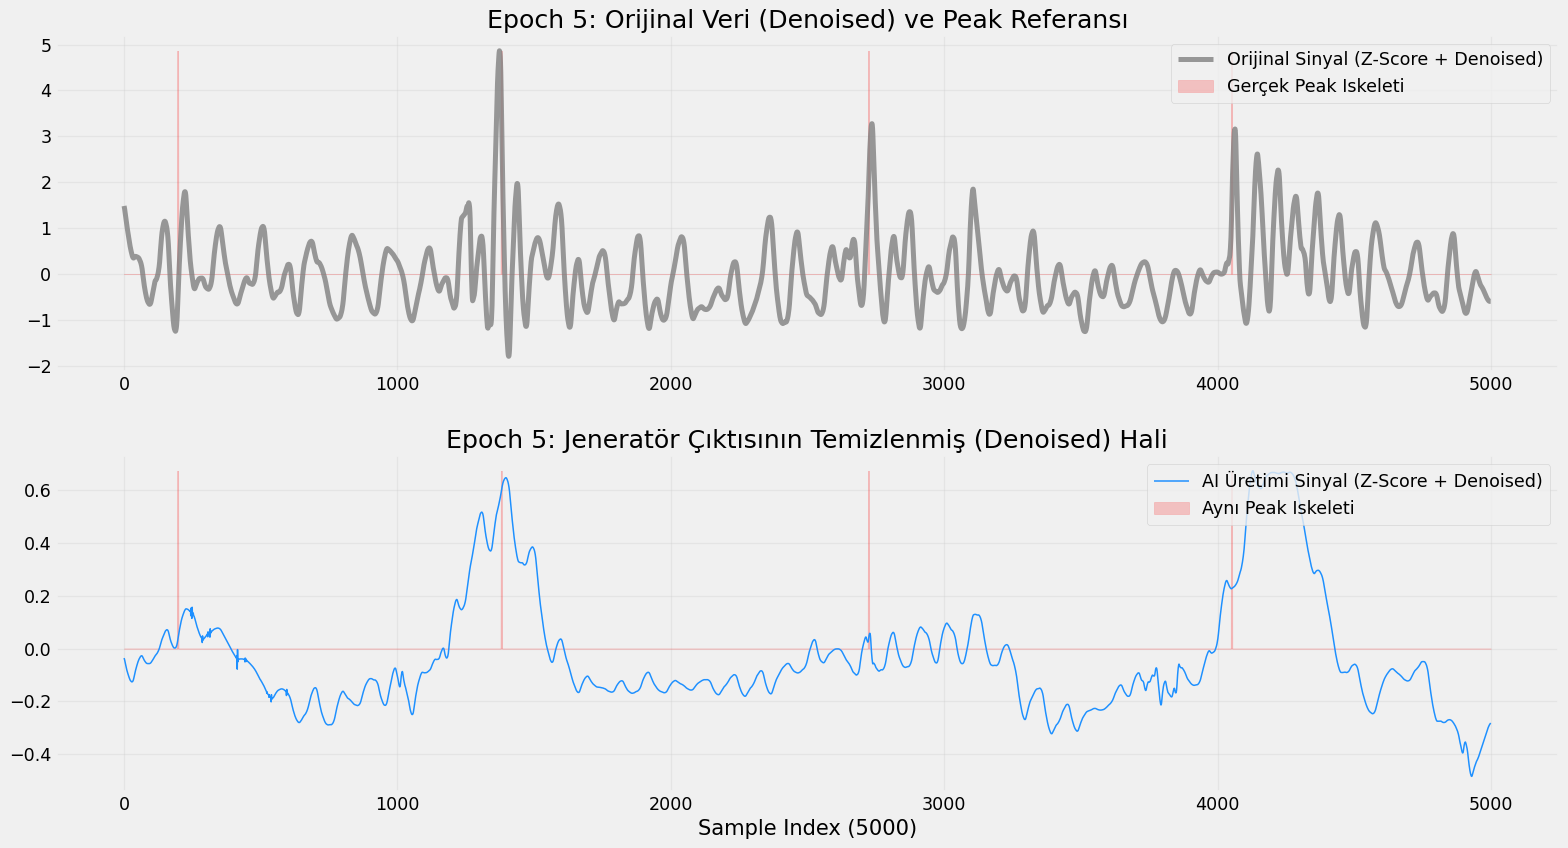

💾 Epoch 5 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 6 BAŞLADI ---
Epoch 6 | Step 427/428 | D_Loss: 0.0001 | G_Total: 28.29
Epoch 6 Özet | D_Loss: 0.0000 | G_Total: 21.54 | Rec: 28.29 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 6)
--- EPOCH 7 BAŞLADI ---
Epoch 7 | Step 427/428 | D_Loss: 0.0000 | G_Total: 27.66
Epoch 7 Özet | D_Loss: 0.0000 | G_Total: 20.97 | Rec: 27.39 | Cls: 0.53
Yeni En Düşük G_Loss! (Best Epoch şu an: 7)
--- EPOCH 8 BAŞLADI ---
Epoch 8 | Step 427/428 | D_Loss: 0.0000 | G_Total: 26.98
Epoch 8 Özet | D_Loss: 0.0000 | G_Total: 20.55 | Rec: 26.97 | Cls: 0.01
Yeni En Düşük G_Loss! (Best Epoch şu an: 8)
--- EPOCH 9 BAŞLADI ---
Epoch 9 | Step 427/428 | D_Loss: 0.0001 | G_Total: 25.91
Epoch 9 Özet | D_Loss: 0.0000 | G_Total: 20.15 | Rec: 25.75 | Cls: 0.33
Yeni En Düşük G_Loss! (Best Epoch şu an: 9)
--- EPOCH 10 BAŞLADI ---
Epoch 10 | Step 427/428 | D_Loss: 0.0000 | G_Total: 25.39
Epoch 10 Özet | D_Loss: 0.0000 | G_Total: 19.78 | Rec: 25.38 | Cls: 0.02
Yeni En 

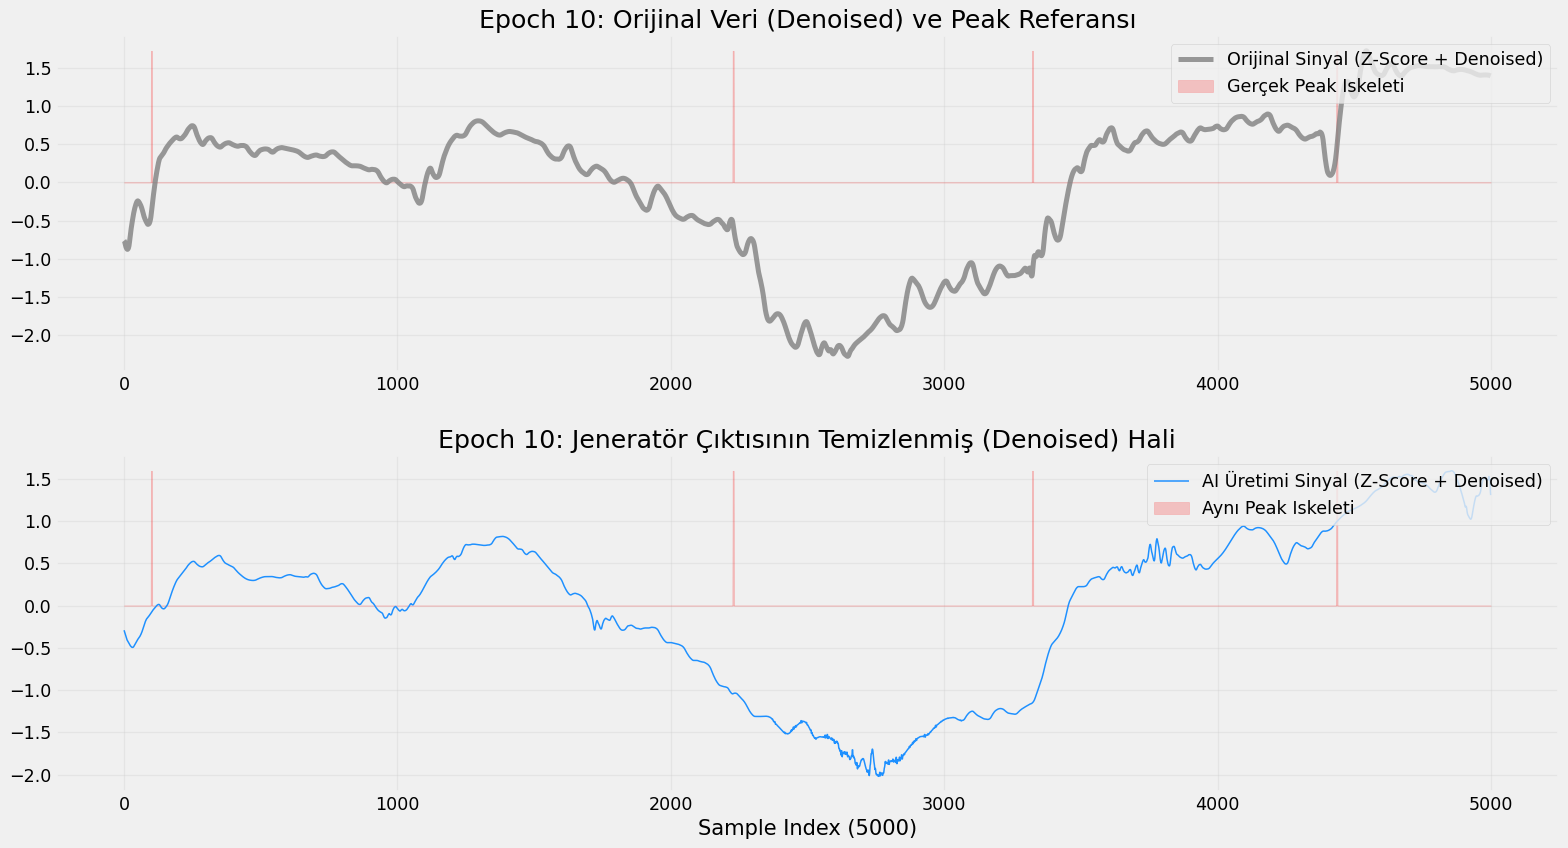

💾 Epoch 10 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 11 BAŞLADI ---
Epoch 11 | Step 427/428 | D_Loss: 0.0000 | G_Total: 24.52
Epoch 11 Özet | D_Loss: 0.0000 | G_Total: 19.46 | Rec: 24.52 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 11)
--- EPOCH 12 BAŞLADI ---
Epoch 12 | Step 427/428 | D_Loss: 0.0000 | G_Total: 23.98
Epoch 12 Özet | D_Loss: 0.0000 | G_Total: 19.17 | Rec: 23.97 | Cls: 0.01
Yeni En Düşük G_Loss! (Best Epoch şu an: 12)
--- EPOCH 13 BAŞLADI ---
Epoch 13 | Step 427/428 | D_Loss: 0.0000 | G_Total: 23.21
Epoch 13 Özet | D_Loss: 0.0000 | G_Total: 18.87 | Rec: 23.20 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 13)
--- EPOCH 14 BAŞLADI ---
Epoch 14 | Step 427/428 | D_Loss: 0.0000 | G_Total: 22.63
Epoch 14 Özet | D_Loss: 0.0000 | G_Total: 18.59 | Rec: 22.63 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 14)
--- EPOCH 15 BAŞLADI ---
Epoch 15 | Step 427/428 | D_Loss: 0.0000 | G_Total: 22.05
Epoch 15 Özet | D_Loss: 0.0000 | G_Total: 18.25 | Rec: 21.87 | C

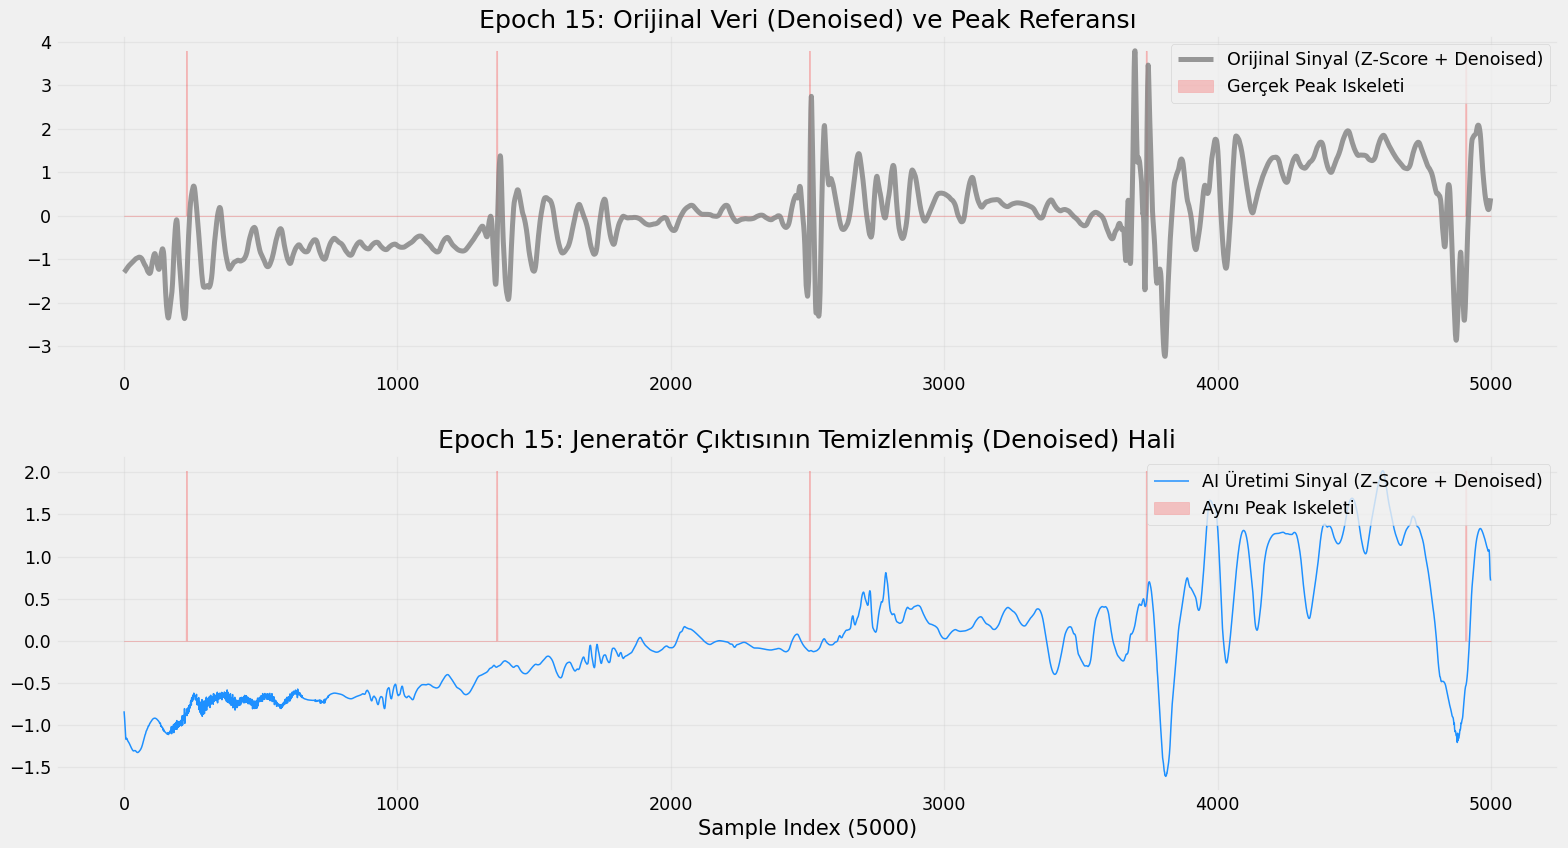

💾 Epoch 15 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 16 BAŞLADI ---
Epoch 16 | Step 427/428 | D_Loss: 0.0000 | G_Total: 21.60
Epoch 16 Özet | D_Loss: 0.0000 | G_Total: 17.92 | Rec: 21.60 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 16)
--- EPOCH 17 BAŞLADI ---
Epoch 17 | Step 427/428 | D_Loss: 0.0000 | G_Total: 20.98
Epoch 17 Özet | D_Loss: 0.0000 | G_Total: 17.58 | Rec: 20.88 | Cls: 0.19
Yeni En Düşük G_Loss! (Best Epoch şu an: 17)
--- EPOCH 18 BAŞLADI ---
Epoch 18 | Step 427/428 | D_Loss: 0.0000 | G_Total: 20.60
Epoch 18 Özet | D_Loss: 0.0000 | G_Total: 17.21 | Rec: 20.44 | Cls: 0.31
Yeni En Düşük G_Loss! (Best Epoch şu an: 18)
--- EPOCH 19 BAŞLADI ---
Epoch 19 | Step 427/428 | D_Loss: 0.0000 | G_Total: 20.22
Epoch 19 Özet | D_Loss: 0.0000 | G_Total: 16.82 | Rec: 20.17 | Cls: 0.08
Yeni En Düşük G_Loss! (Best Epoch şu an: 19)
--- EPOCH 20 BAŞLADI ---
Epoch 20 | Step 427/428 | D_Loss: 0.0000 | G_Total: 20.19
Epoch 20 Özet | D_Loss: 0.0000 | G_Total: 16.47 | Rec: 20.19 | C

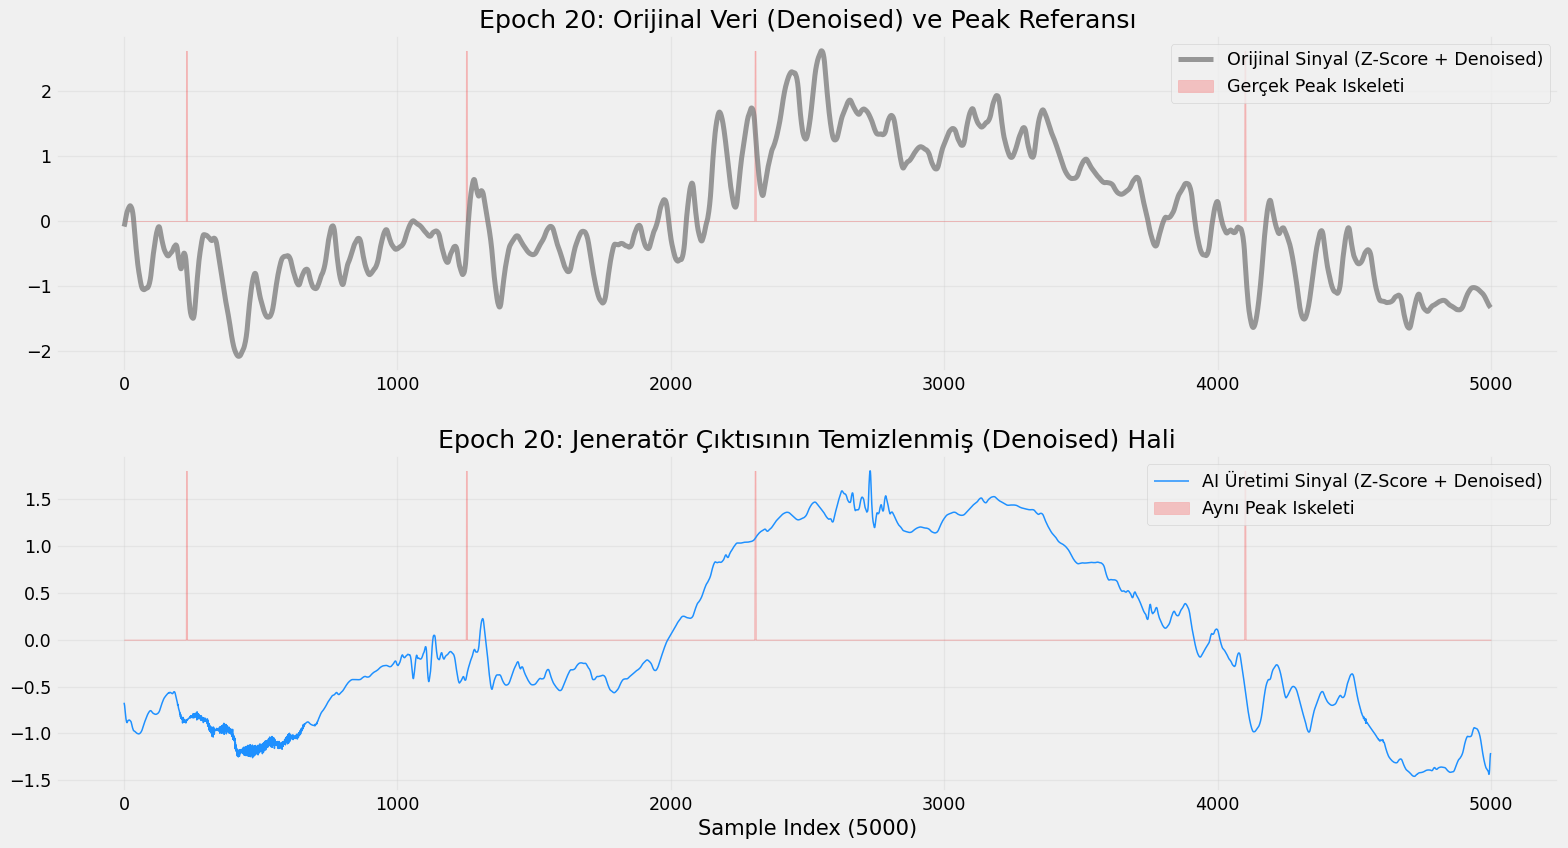

💾 Epoch 20 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 21 BAŞLADI ---
Epoch 21 | Step 427/428 | D_Loss: 0.0000 | G_Total: 19.06
Epoch 21 Özet | D_Loss: 0.0000 | G_Total: 16.09 | Rec: 19.02 | Cls: 0.08
Yeni En Düşük G_Loss! (Best Epoch şu an: 21)
--- EPOCH 22 BAŞLADI ---
Epoch 22 | Step 427/428 | D_Loss: 0.0017 | G_Total: 18.587
Epoch 22 Özet | D_Loss: 0.1522 | G_Total: 16.35 | Rec: 18.15 | Cls: 0.86
--- EPOCH 23 BAŞLADI ---
Epoch 23 | Step 427/428 | D_Loss: 0.0003 | G_Total: 17.54
Epoch 23 Özet | D_Loss: 0.0002 | G_Total: 15.51 | Rec: 17.11 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 23)
--- EPOCH 24 BAŞLADI ---
Epoch 24 | Step 427/428 | D_Loss: 0.0003 | G_Total: 17.23
Epoch 24 Özet | D_Loss: 0.0001 | G_Total: 15.10 | Rec: 16.54 | Cls: 1.37
Yeni En Düşük G_Loss! (Best Epoch şu an: 24)
--- EPOCH 25 BAŞLADI ---
Epoch 25 | Step 427/428 | D_Loss: 0.0001 | G_Total: 17.52
Epoch 25 Özet | D_Loss: 0.0000 | G_Total: 14.74 | Rec: 17.08 | Cls: 0.88
Yeni En Düşük G_Loss! (Best Epoch ş

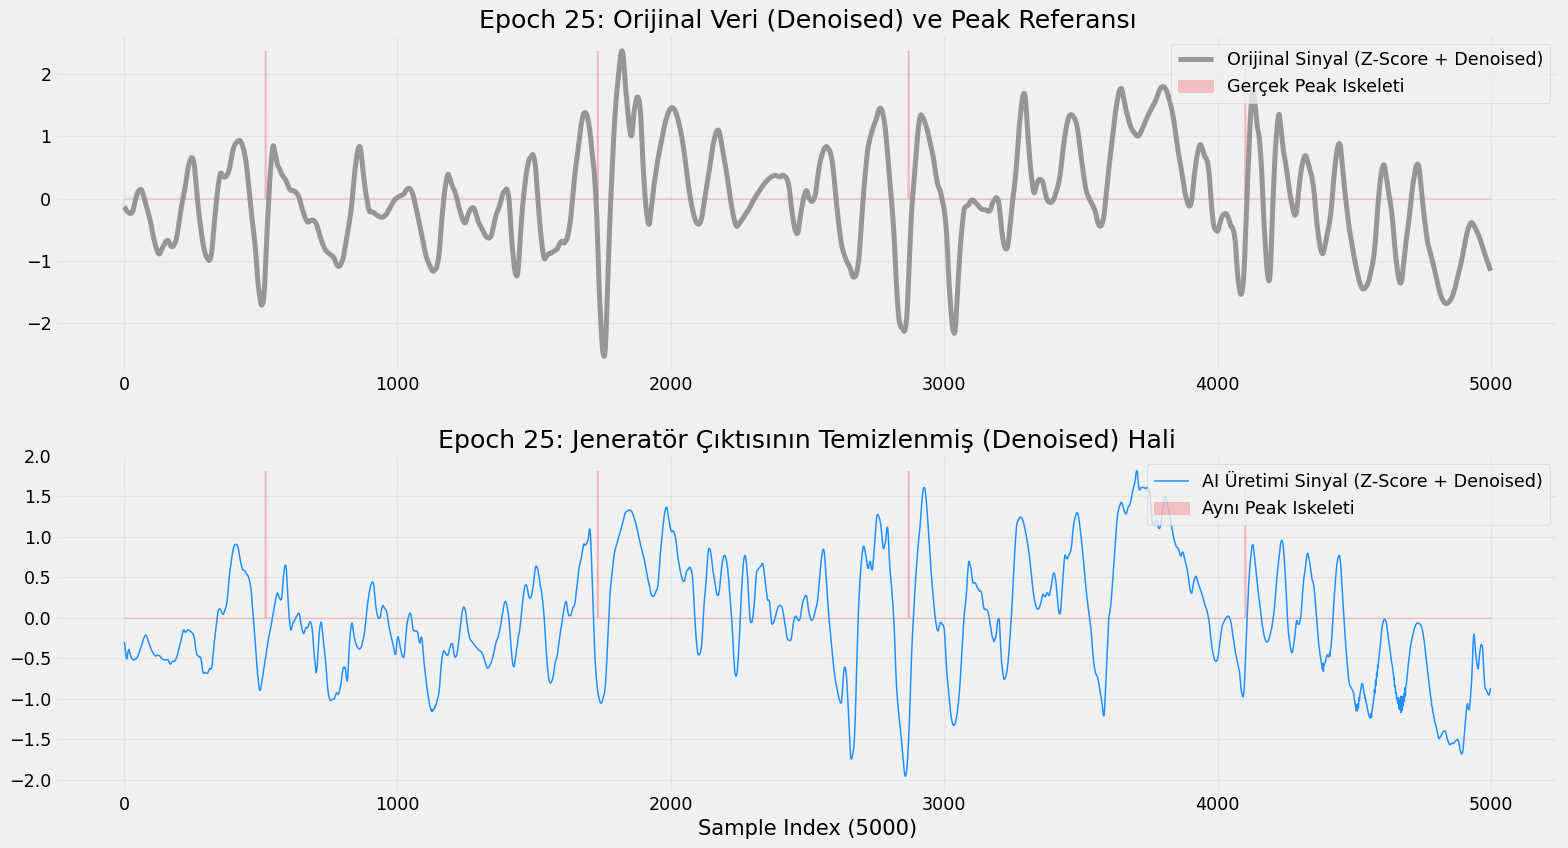

💾 Epoch 25 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 26 BAŞLADI ---
Epoch 26 | Step 427/428 | D_Loss: 0.0000 | G_Total: 16.67
Epoch 26 Özet | D_Loss: 0.0000 | G_Total: 14.42 | Rec: 16.20 | Cls: 0.95
Yeni En Düşük G_Loss! (Best Epoch şu an: 26)
--- EPOCH 27 BAŞLADI ---
Epoch 27 | Step 427/428 | D_Loss: 0.0000 | G_Total: 15.87
Epoch 27 Özet | D_Loss: 0.0000 | G_Total: 14.09 | Rec: 15.34 | Cls: 1.05
Yeni En Düşük G_Loss! (Best Epoch şu an: 27)
--- EPOCH 28 BAŞLADI ---
Epoch 28 | Step 427/428 | D_Loss: 0.0000 | G_Total: 15.41
Epoch 28 Özet | D_Loss: 0.0000 | G_Total: 13.78 | Rec: 14.97 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 28)
--- EPOCH 29 BAŞLADI ---
Epoch 29 | Step 427/428 | D_Loss: 0.0000 | G_Total: 14.72
Epoch 29 Özet | D_Loss: 0.0000 | G_Total: 13.45 | Rec: 14.29 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 29)
--- EPOCH 30 BAŞLADI ---
Epoch 30 | Step 427/428 | D_Loss: 0.0000 | G_Total: 14.76
Epoch 30 Özet | D_Loss: 0.0000 | G_Total: 13.19 | Rec: 14.33 | C

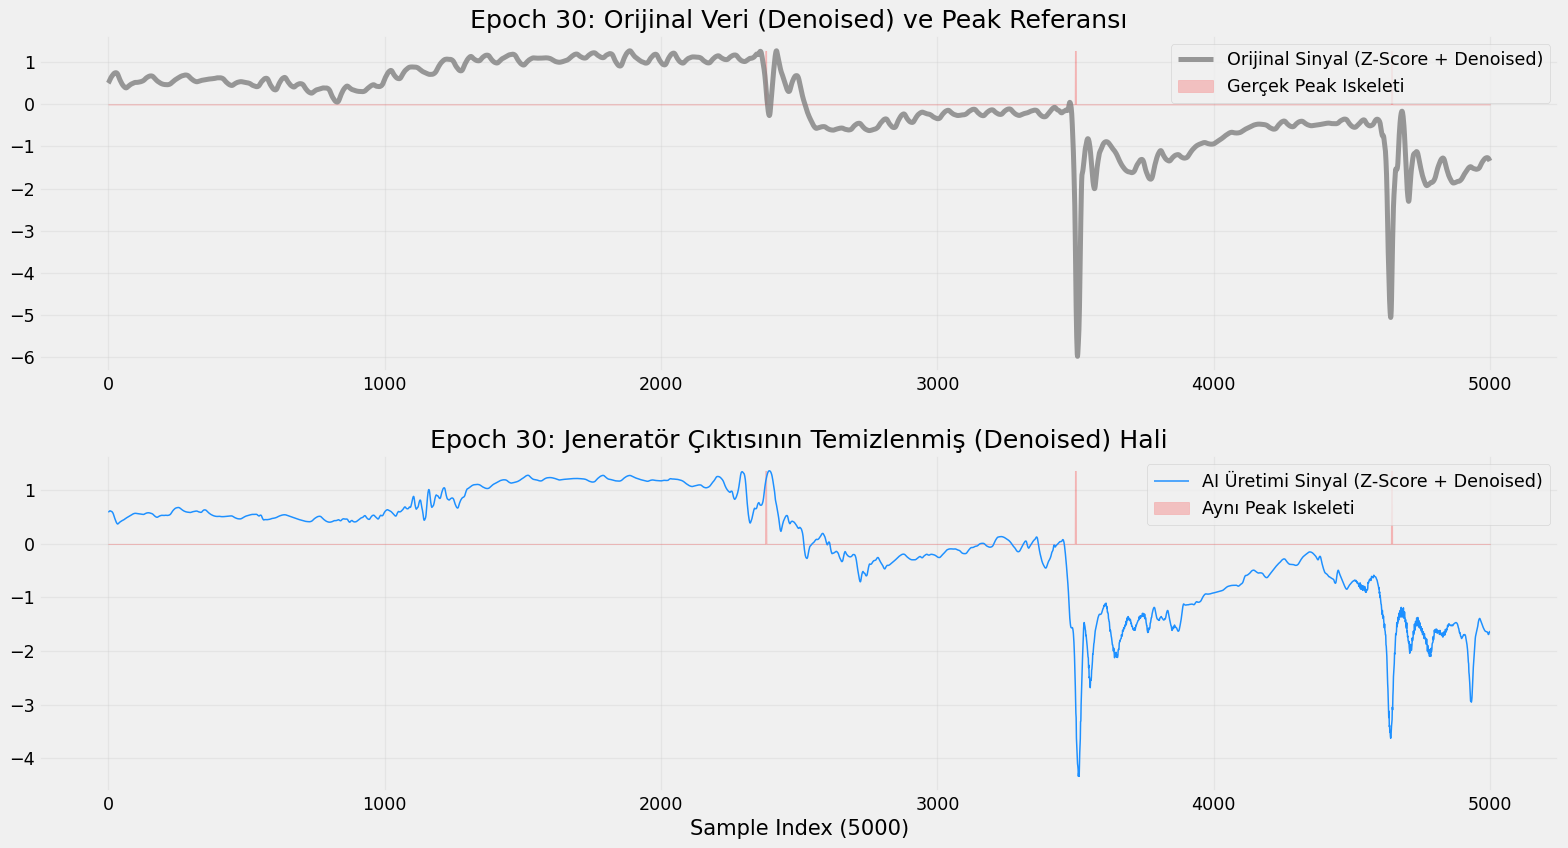

💾 Epoch 30 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 31 BAŞLADI ---
Epoch 31 | Step 427/428 | D_Loss: 0.0000 | G_Total: 14.11
Epoch 31 Özet | D_Loss: 0.0000 | G_Total: 12.87 | Rec: 13.62 | Cls: 0.99
Yeni En Düşük G_Loss! (Best Epoch şu an: 31)
--- EPOCH 32 BAŞLADI ---
Epoch 32 | Step 427/428 | D_Loss: 0.0000 | G_Total: 13.86
Epoch 32 Özet | D_Loss: 0.0000 | G_Total: 12.62 | Rec: 13.43 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 32)
--- EPOCH 33 BAŞLADI ---
Epoch 33 | Step 427/428 | D_Loss: 0.0000 | G_Total: 13.50
Epoch 33 Özet | D_Loss: 0.0000 | G_Total: 12.43 | Rec: 13.00 | Cls: 1.01
Yeni En Düşük G_Loss! (Best Epoch şu an: 33)
--- EPOCH 34 BAŞLADI ---
Epoch 34 | Step 427/428 | D_Loss: 0.0000 | G_Total: 13.24
Epoch 34 Özet | D_Loss: 0.0000 | G_Total: 12.20 | Rec: 12.79 | Cls: 0.91
Yeni En Düşük G_Loss! (Best Epoch şu an: 34)
--- EPOCH 35 BAŞLADI ---
Epoch 35 | Step 427/428 | D_Loss: 0.0000 | G_Total: 12.78
Epoch 35 Özet | D_Loss: 0.0000 | G_Total: 11.96 | Rec: 12.34 | C

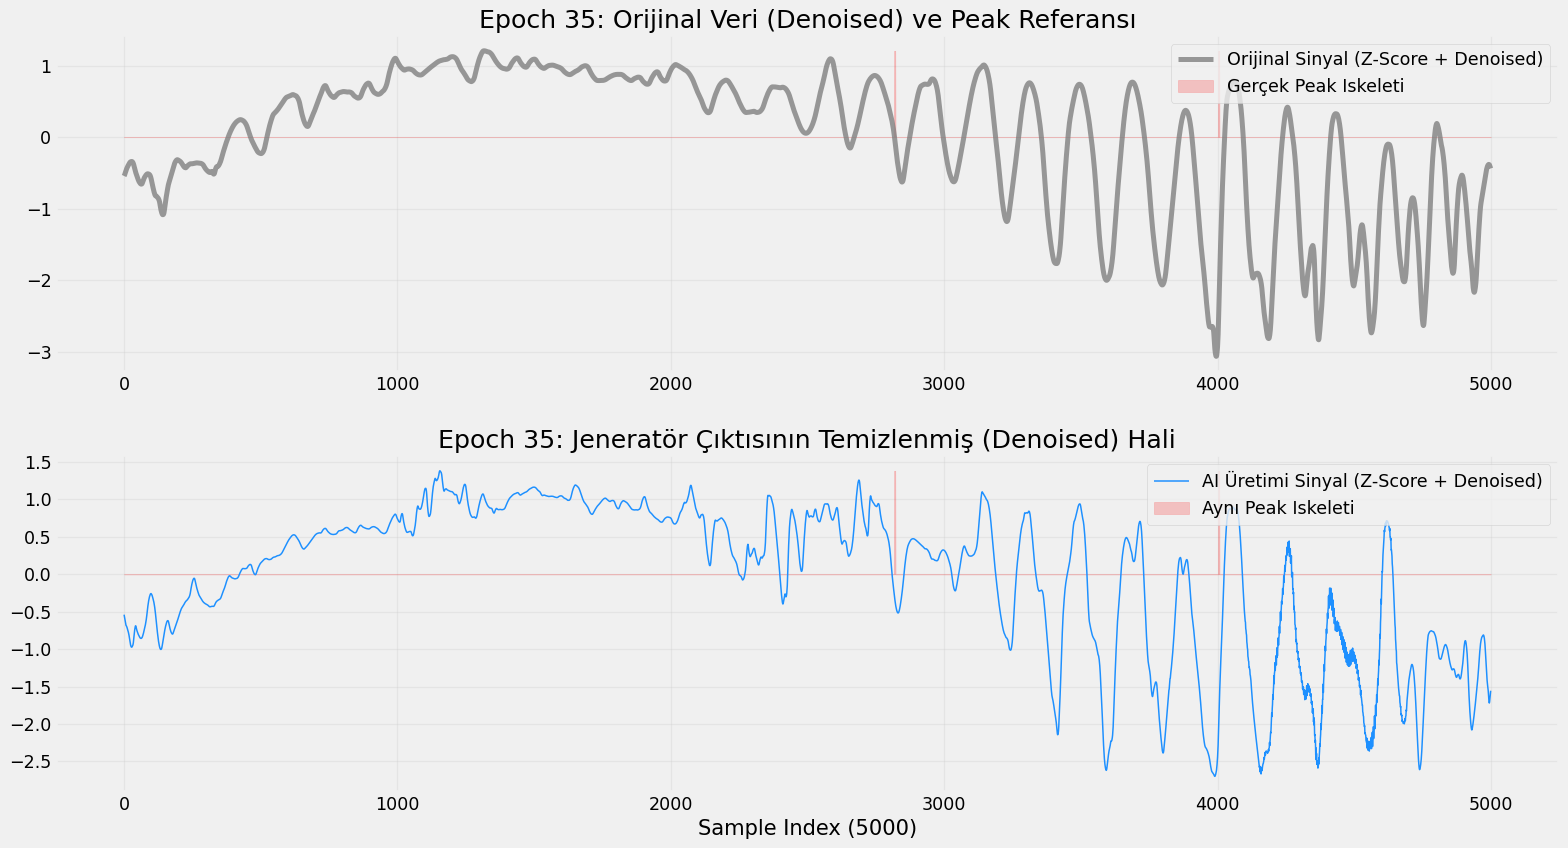

💾 Epoch 35 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 36 BAŞLADI ---
Epoch 36 | Step 427/428 | D_Loss: 0.0000 | G_Total: 12.87
Epoch 36 Özet | D_Loss: 0.0000 | G_Total: 11.78 | Rec: 12.33 | Cls: 1.07
Yeni En Düşük G_Loss! (Best Epoch şu an: 36)
--- EPOCH 37 BAŞLADI ---
Epoch 37 | Step 427/428 | D_Loss: 0.0000 | G_Total: 12.87
Epoch 37 Özet | D_Loss: 0.0000 | G_Total: 11.59 | Rec: 12.37 | Cls: 1.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 37)
--- EPOCH 38 BAŞLADI ---
Epoch 38 | Step 427/428 | D_Loss: 0.0000 | G_Total: 12.50
Epoch 38 Özet | D_Loss: 0.0000 | G_Total: 11.39 | Rec: 11.98 | Cls: 1.03
Yeni En Düşük G_Loss! (Best Epoch şu an: 38)
--- EPOCH 39 BAŞLADI ---
Epoch 39 | Step 427/428 | D_Loss: 0.0000 | G_Total: 12.52
Epoch 39 Özet | D_Loss: 0.0000 | G_Total: 11.19 | Rec: 12.04 | Cls: 0.95
Yeni En Düşük G_Loss! (Best Epoch şu an: 39)
--- EPOCH 40 BAŞLADI ---
Epoch 40 | Step 427/428 | D_Loss: 0.0000 | G_Total: 12.00
Epoch 40 Özet | D_Loss: 0.0000 | G_Total: 11.04 | Rec: 11.56 | C

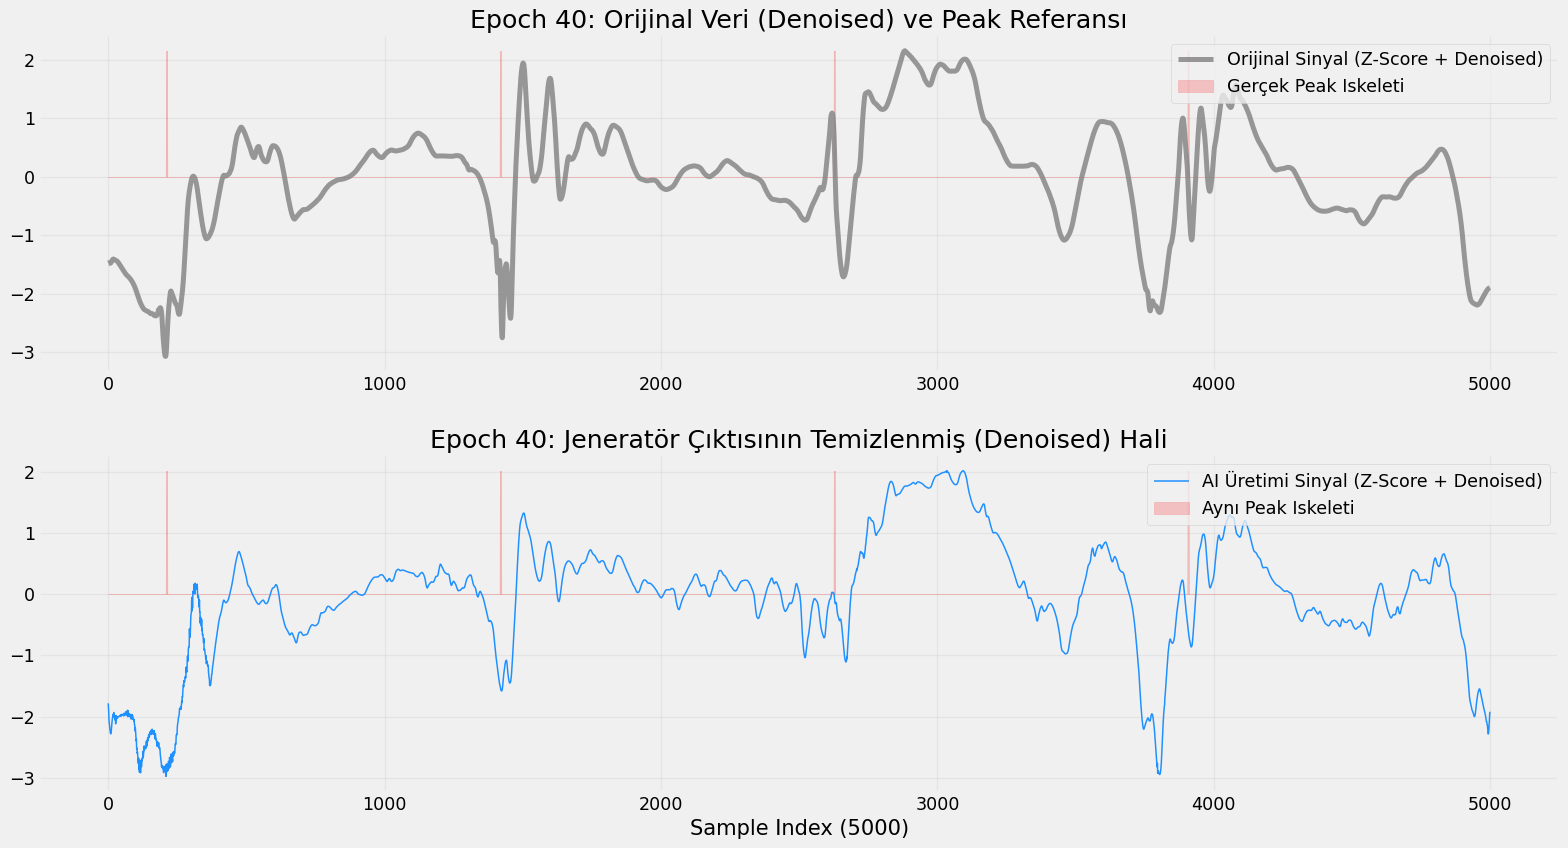

💾 Epoch 40 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 41 BAŞLADI ---
Epoch 41 | Step 427/428 | D_Loss: 0.0000 | G_Total: 12.03
Epoch 41 Özet | D_Loss: 0.0000 | G_Total: 10.89 | Rec: 11.56 | Cls: 0.93
Yeni En Düşük G_Loss! (Best Epoch şu an: 41)
--- EPOCH 42 BAŞLADI ---
Epoch 42 | Step 427/428 | D_Loss: 0.0005 | G_Total: 12.18
Epoch 42 Özet | D_Loss: 0.1086 | G_Total: 10.98 | Rec: 11.73 | Cls: 0.89
--- EPOCH 43 BAŞLADI ---
Epoch 43 | Step 427/428 | D_Loss: 0.0001 | G_Total: 11.99
Epoch 43 Özet | D_Loss: 0.0002 | G_Total: 10.57 | Rec: 11.54 | Cls: 0.88
Yeni En Düşük G_Loss! (Best Epoch şu an: 43)
--- EPOCH 44 BAŞLADI ---
Epoch 44 | Step 427/428 | D_Loss: 0.0001 | G_Total: 11.48
Epoch 44 Özet | D_Loss: 0.0000 | G_Total: 10.34 | Rec: 11.04 | Cls: 0.88
Yeni En Düşük G_Loss! (Best Epoch şu an: 44)
--- EPOCH 45 BAŞLADI ---
Epoch 45 | Step 427/428 | D_Loss: 0.0001 | G_Total: 11.53
Epoch 45 Özet | D_Loss: 0.0000 | G_Total: 10.18 | Rec: 11.04 | Cls: 0.98
Yeni En Düşük G_Loss! (Best Epoch şu

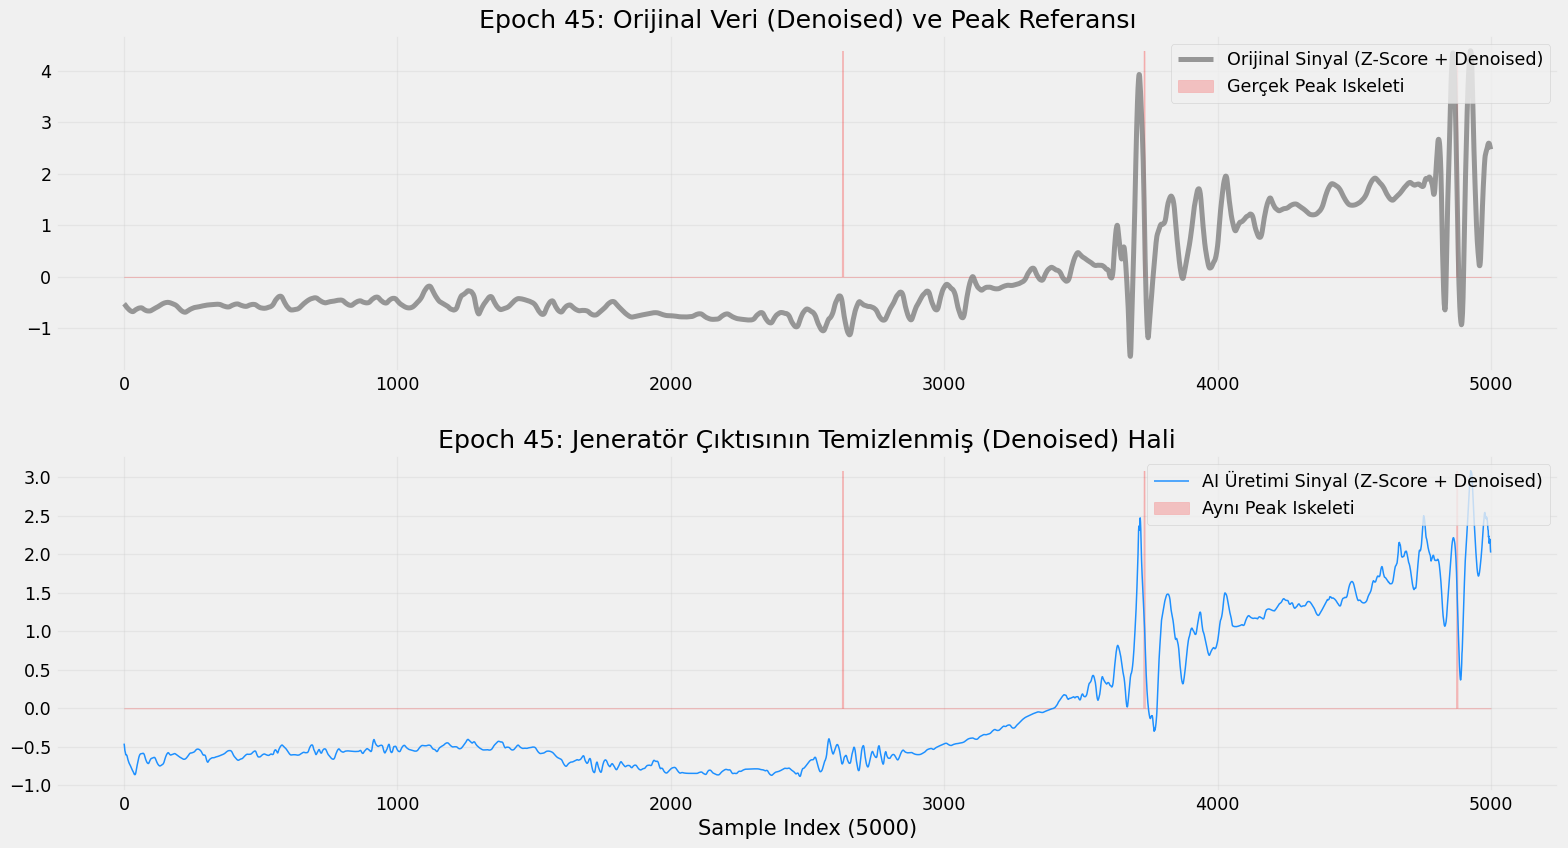

💾 Epoch 45 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 46 BAŞLADI ---
Epoch 46 | Step 427/428 | D_Loss: 0.0000 | G_Total: 11.85
Epoch 46 Özet | D_Loss: 0.0000 | G_Total: 10.08 | Rec: 11.41 | Cls: 0.88
Yeni En Düşük G_Loss! (Best Epoch şu an: 46)
--- EPOCH 47 BAŞLADI ---
Epoch 47 | Step 427/428 | D_Loss: 0.0000 | G_Total: 11.79
Epoch 47 Özet | D_Loss: 0.0248 | G_Total: 10.21 | Rec: 11.23 | Cls: 1.10
--- EPOCH 48 BAŞLADI ---
Epoch 48 | Step 427/428 | D_Loss: 0.0000 | G_Total: 12.08
Epoch 48 Özet | D_Loss: 0.0000 | G_Total: 9.96 | Rec: 11.34 | Cls: 1.47
Yeni En Düşük G_Loss! (Best Epoch şu an: 48)
--- EPOCH 49 BAŞLADI ---
Epoch 49 | Step 427/428 | D_Loss: 0.0000 | G_Total: 11.70
Epoch 49 Özet | D_Loss: 0.0000 | G_Total: 9.77 | Rec: 11.27 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 49)
--- EPOCH 50 BAŞLADI ---
Epoch 50 | Step 427/428 | D_Loss: 0.0000 | G_Total: 11.48
Epoch 50 Özet | D_Loss: 0.0000 | G_Total: 9.65 | Rec: 11.05 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an

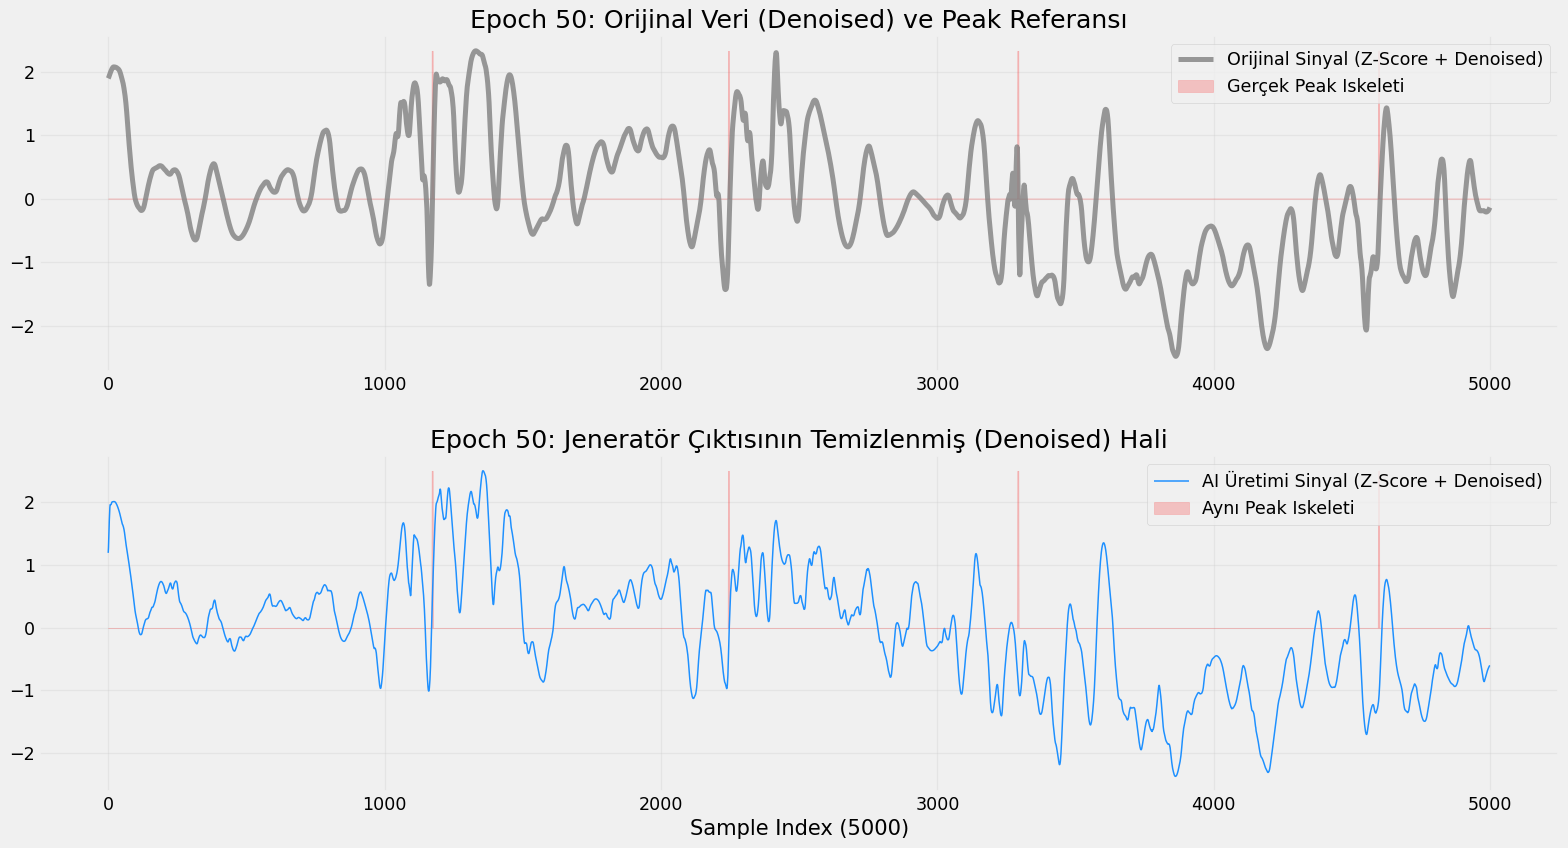

💾 Epoch 50 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 51 BAŞLADI ---
Epoch 51 | Step 427/428 | D_Loss: 0.0000 | G_Total: 10.95
Epoch 51 Özet | D_Loss: 0.0000 | G_Total: 9.51 | Rec: 10.52 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 51)
--- EPOCH 52 BAŞLADI ---
Epoch 52 | Step 427/428 | D_Loss: 0.0000 | G_Total: 10.98
Epoch 52 Özet | D_Loss: 0.0000 | G_Total: 9.42 | Rec: 10.54 | Cls: 0.88
Yeni En Düşük G_Loss! (Best Epoch şu an: 52)
--- EPOCH 53 BAŞLADI ---
Epoch 53 | Step 427/428 | D_Loss: 0.0000 | G_Total: 11.24
Epoch 53 Özet | D_Loss: 0.0000 | G_Total: 9.37 | Rec: 10.80 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 53)
--- EPOCH 54 BAŞLADI ---
Epoch 54 | Step 427/428 | D_Loss: 0.0000 | G_Total: 10.77
Epoch 54 Özet | D_Loss: 0.0000 | G_Total: 9.28 | Rec: 10.32 | Cls: 0.91
Yeni En Düşük G_Loss! (Best Epoch şu an: 54)
--- EPOCH 55 BAŞLADI ---
Epoch 55 | Step 427/428 | D_Loss: 0.0000 | G_Total: 11.24
Epoch 55 Özet | D_Loss: 0.0000 | G_Total: 9.18 | Rec: 10.64 | Cls: 1

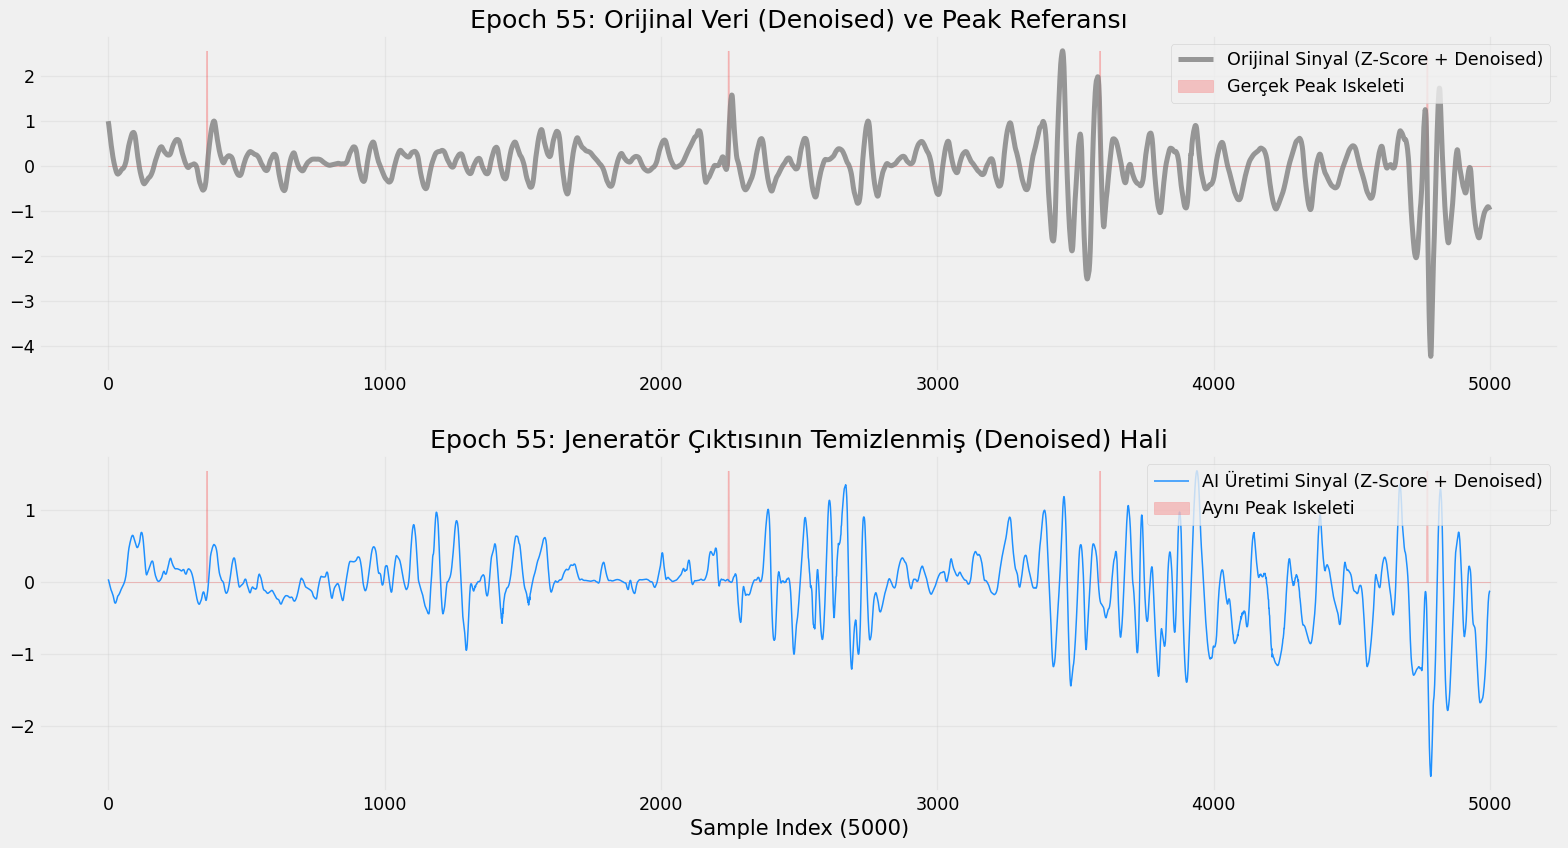

💾 Epoch 55 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 56 BAŞLADI ---
Epoch 56 | Step 427/428 | D_Loss: 0.0000 | G_Total: 11.14
Epoch 56 Özet | D_Loss: 0.0000 | G_Total: 9.05 | Rec: 10.70 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 56)
--- EPOCH 57 BAŞLADI ---
Epoch 57 | Step 427/428 | D_Loss: 0.0000 | G_Total: 10.73
Epoch 57 Özet | D_Loss: 0.0000 | G_Total: 8.97 | Rec: 10.30 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 57)
--- EPOCH 58 BAŞLADI ---
Epoch 58 | Step 427/428 | D_Loss: 0.0000 | G_Total: 10.62
Epoch 58 Özet | D_Loss: 0.0000 | G_Total: 8.90 | Rec: 10.19 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 58)
--- EPOCH 59 BAŞLADI ---
Epoch 59 | Step 427/428 | D_Loss: 0.0000 | G_Total: 10.50
Epoch 59 Özet | D_Loss: 0.0000 | G_Total: 8.83 | Rec: 10.07 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 59)
--- EPOCH 60 BAŞLADI ---
Epoch 60 | Step 427/428 | D_Loss: 0.0000 | G_Total: 10.49
Epoch 60 Özet | D_Loss: 0.0000 | G_Total: 8.76 | Rec: 10.04 | Cls: 0

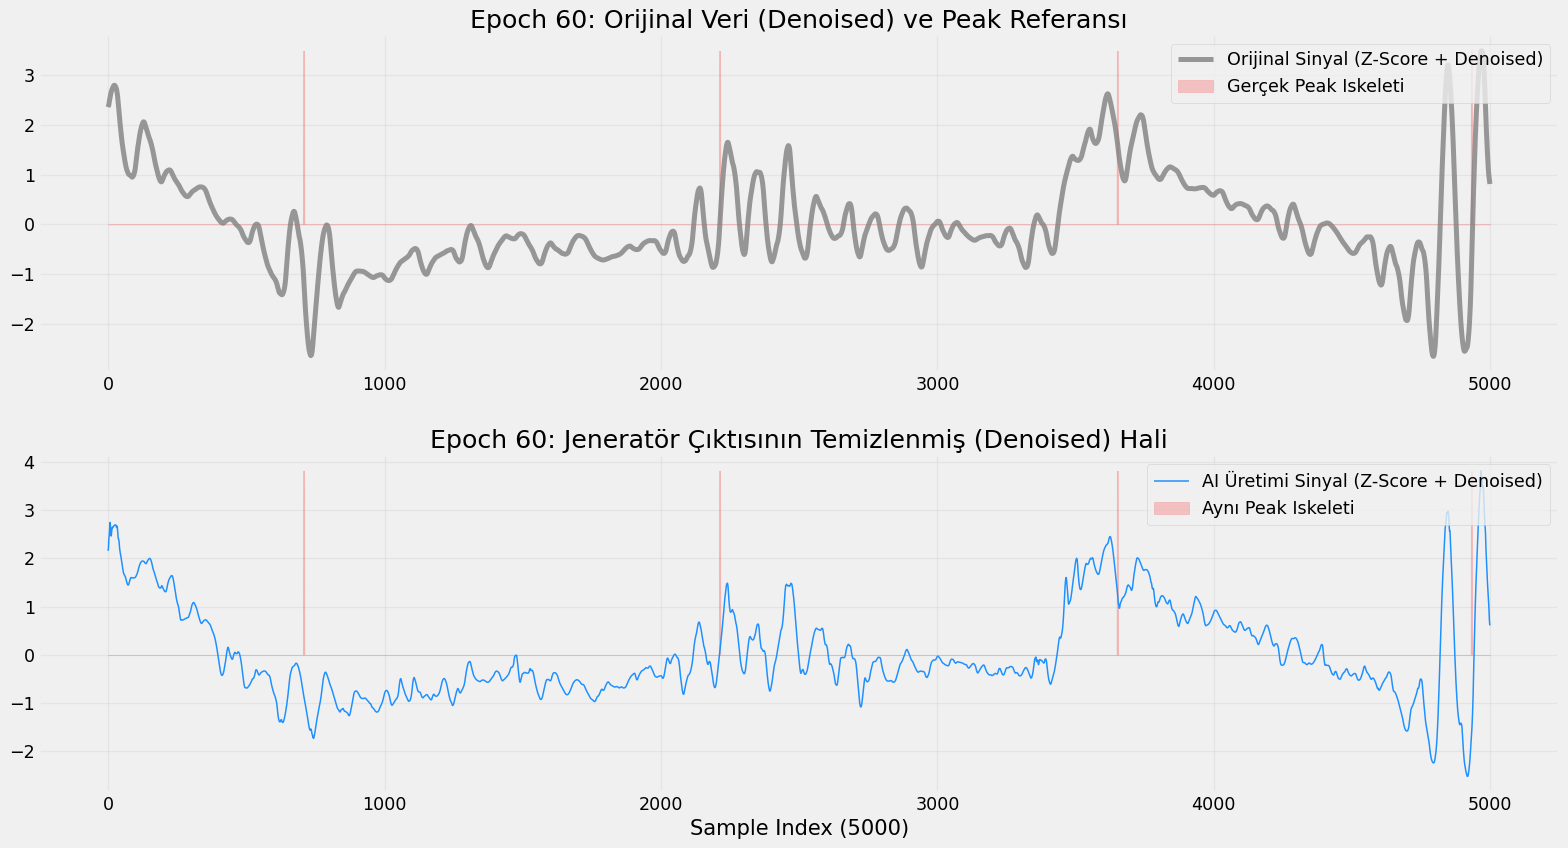

💾 Epoch 60 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 61 BAŞLADI ---
Epoch 61 | Step 427/428 | D_Loss: 0.0000 | G_Total: 10.30
Epoch 61 Özet | D_Loss: 0.0000 | G_Total: 8.69 | Rec: 9.87 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 61)
--- EPOCH 62 BAŞLADI ---
Epoch 62 | Step 427/428 | D_Loss: 0.0000 | G_Total: 10.26
Epoch 62 Özet | D_Loss: 0.0000 | G_Total: 8.65 | Rec: 9.79 | Cls: 0.93
Yeni En Düşük G_Loss! (Best Epoch şu an: 62)
--- EPOCH 63 BAŞLADI ---
Epoch 63 | Step 427/428 | D_Loss: 0.0000 | G_Total: 10.36
Epoch 63 Özet | D_Loss: 0.0000 | G_Total: 8.61 | Rec: 9.93 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 63)
--- EPOCH 64 BAŞLADI ---
Epoch 64 | Step 427/428 | D_Loss: 0.0000 | G_Total: 10.00
Epoch 64 Özet | D_Loss: 0.0000 | G_Total: 8.49 | Rec: 9.58 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 64)
--- EPOCH 65 BAŞLADI ---
Epoch 65 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.908
Epoch 65 Özet | D_Loss: 0.0000 | G_Total: 8.43 | Rec: 9.45 | Cls: 0.90
Y

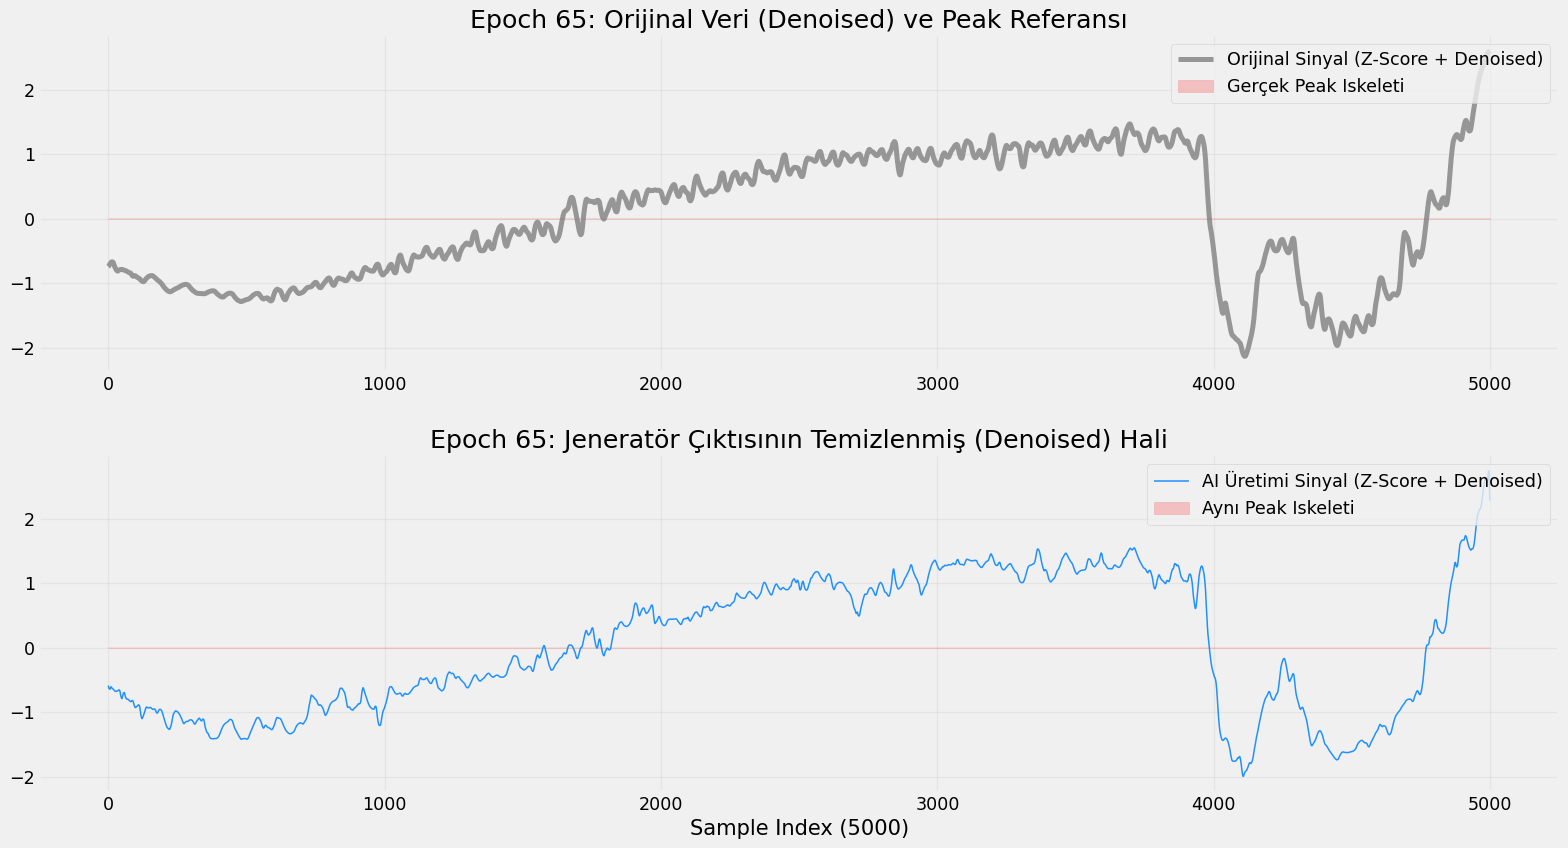

💾 Epoch 65 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 66 BAŞLADI ---
Epoch 66 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.855
Epoch 66 Özet | D_Loss: 0.0000 | G_Total: 8.39 | Rec: 9.42 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 66)
--- EPOCH 67 BAŞLADI ---
Epoch 67 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.903
Epoch 67 Özet | D_Loss: 0.0000 | G_Total: 8.34 | Rec: 9.34 | Cls: 1.12
Yeni En Düşük G_Loss! (Best Epoch şu an: 67)
--- EPOCH 68 BAŞLADI ---
Epoch 68 | Step 427/428 | D_Loss: 0.0000 | G_Total: 10.16
Epoch 68 Özet | D_Loss: 0.0000 | G_Total: 8.30 | Rec: 9.73 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 68)
--- EPOCH 69 BAŞLADI ---
Epoch 69 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.869
Epoch 69 Özet | D_Loss: 0.0000 | G_Total: 8.21 | Rec: 9.40 | Cls: 0.91
Yeni En Düşük G_Loss! (Best Epoch şu an: 69)
--- EPOCH 70 BAŞLADI ---
Epoch 70 | Step 427/428 | D_Loss: 0.0000 | G_Total: 10.33
Epoch 70 Özet | D_Loss: 0.0000 | G_Total: 8.18 | Rec: 9.90 | Cls: 0.87
Y

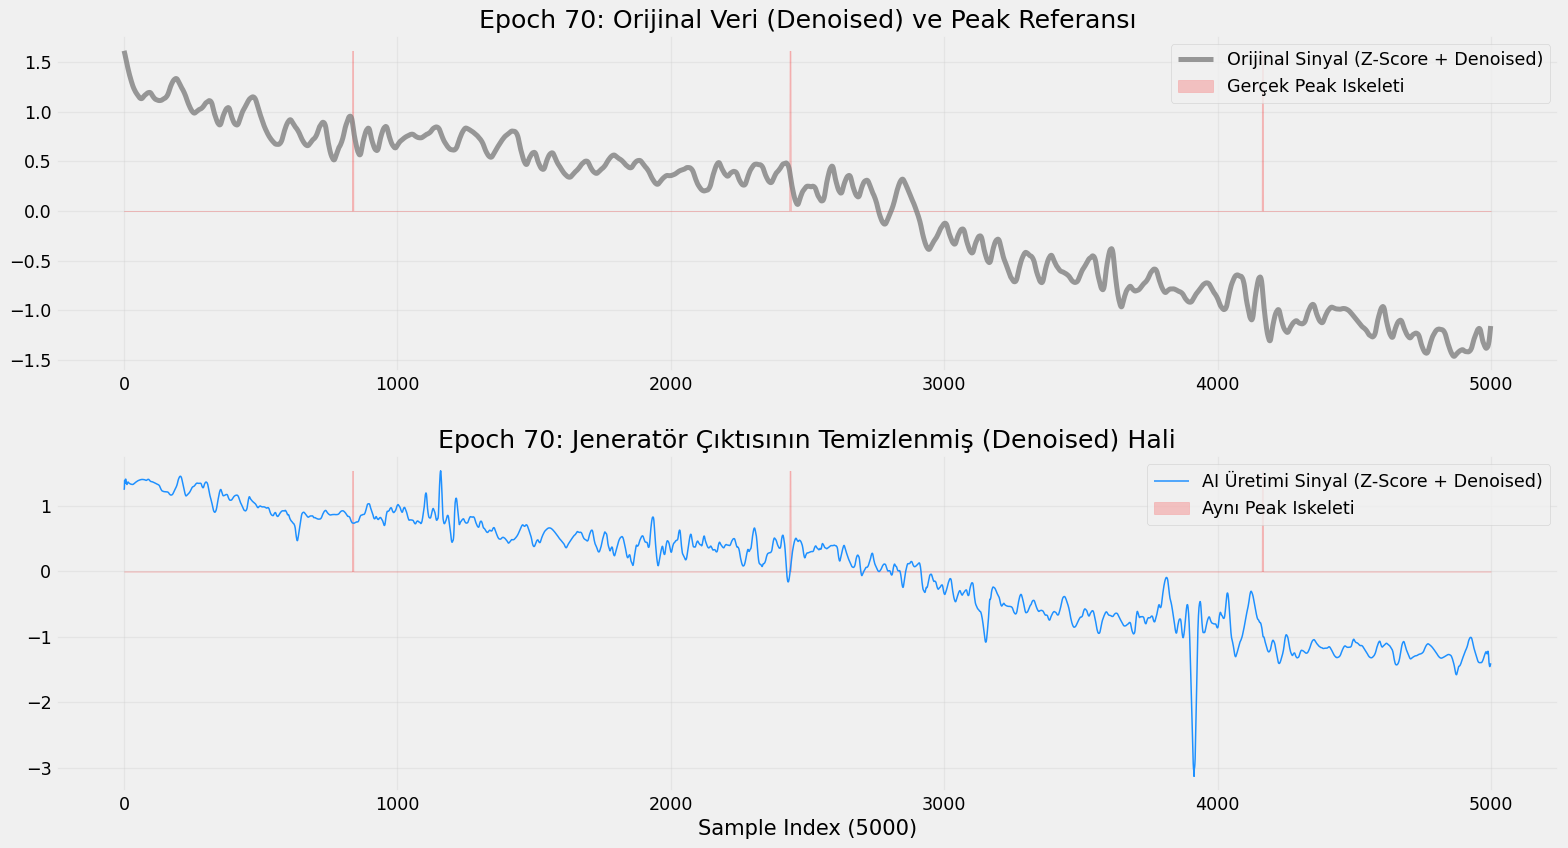

💾 Epoch 70 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 71 BAŞLADI ---
Epoch 71 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.851
Epoch 71 Özet | D_Loss: 0.0000 | G_Total: 8.14 | Rec: 9.42 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 71)
--- EPOCH 72 BAŞLADI ---
Epoch 72 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.774
Epoch 72 Özet | D_Loss: 0.0000 | G_Total: 8.09 | Rec: 9.33 | Cls: 0.88
Yeni En Düşük G_Loss! (Best Epoch şu an: 72)
--- EPOCH 73 BAŞLADI ---
Epoch 73 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.785
Epoch 73 Özet | D_Loss: 0.0000 | G_Total: 8.06 | Rec: 9.35 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 73)
--- EPOCH 74 BAŞLADI ---
Epoch 74 | Step 427/428 | D_Loss: 0.0004 | G_Total: 9.937
Epoch 74 Özet | D_Loss: 0.0807 | G_Total: 8.45 | Rec: 9.49 | Cls: 0.87
--- EPOCH 75 BAŞLADI ---
Epoch 75 | Step 427/428 | D_Loss: 0.0001 | G_Total: 9.593
Epoch 75 Özet | D_Loss: 0.0038 | G_Total: 8.05 | Rec: 9.12 | Cls: 0.94
Yeni En Düşük G_Loss! (Best Epoch şu an: 75)


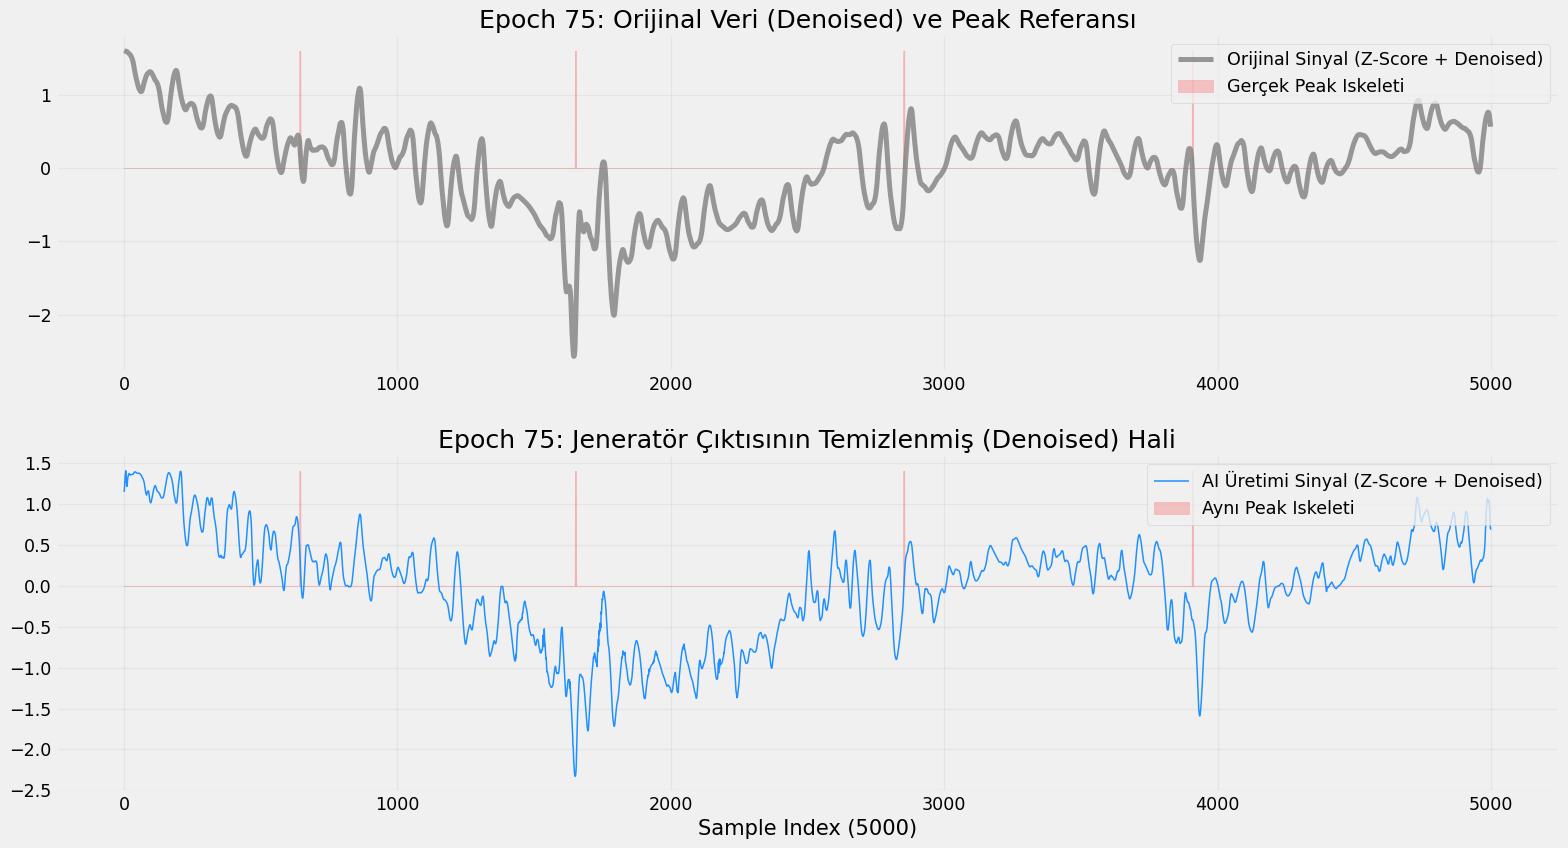

💾 Epoch 75 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 76 BAŞLADI ---
Epoch 76 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.503
Epoch 76 Özet | D_Loss: 0.0008 | G_Total: 8.01 | Rec: 9.06 | Cls: 0.88
Yeni En Düşük G_Loss! (Best Epoch şu an: 76)
--- EPOCH 77 BAŞLADI ---
Epoch 77 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.589
Epoch 77 Özet | D_Loss: 0.0000 | G_Total: 7.91 | Rec: 9.11 | Cls: 0.95
Yeni En Düşük G_Loss! (Best Epoch şu an: 77)
--- EPOCH 78 BAŞLADI ---
Epoch 78 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.750
Epoch 78 Özet | D_Loss: 0.0000 | G_Total: 7.85 | Rec: 9.32 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 78)
--- EPOCH 79 BAŞLADI ---
Epoch 79 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.606
Epoch 79 Özet | D_Loss: 0.0000 | G_Total: 7.84 | Rec: 9.17 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 79)
--- EPOCH 80 BAŞLADI ---
Epoch 80 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.433
Epoch 80 Özet | D_Loss: 0.0000 | G_Total: 7.80 | Rec: 9.00 | Cls: 0.86
Y

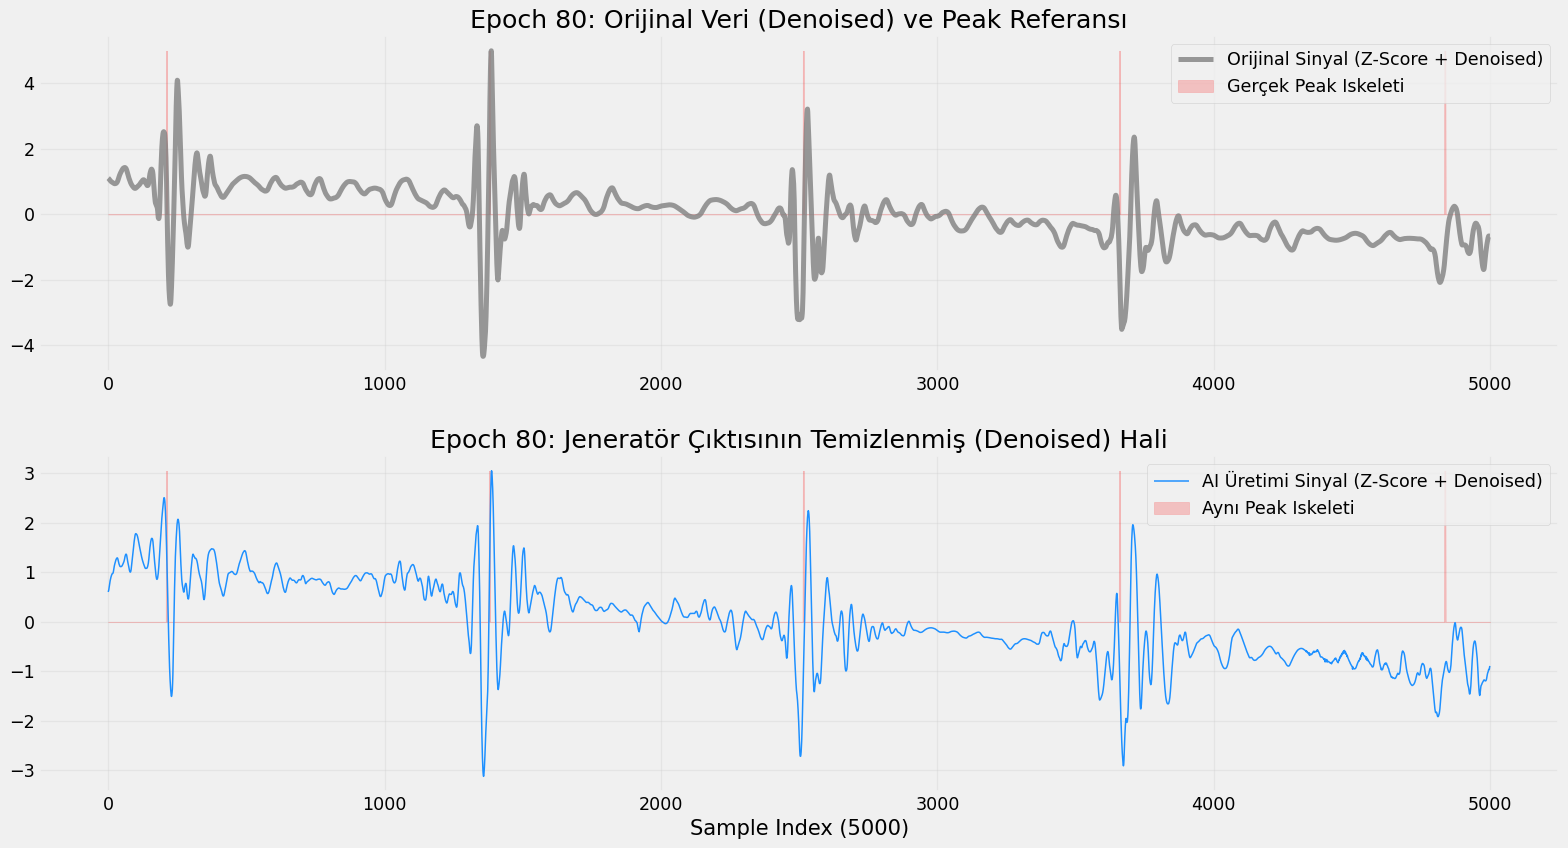

💾 Epoch 80 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 81 BAŞLADI ---
Epoch 81 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.258
Epoch 81 Özet | D_Loss: 0.0000 | G_Total: 7.75 | Rec: 8.82 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 81)
--- EPOCH 82 BAŞLADI ---
Epoch 82 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.325
Epoch 82 Özet | D_Loss: 0.0000 | G_Total: 7.69 | Rec: 8.77 | Cls: 1.08
Yeni En Düşük G_Loss! (Best Epoch şu an: 82)
--- EPOCH 83 BAŞLADI ---
Epoch 83 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.513
Epoch 83 Özet | D_Loss: 0.0000 | G_Total: 7.64 | Rec: 9.08 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 83)
--- EPOCH 84 BAŞLADI ---
Epoch 84 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.263
Epoch 84 Özet | D_Loss: 0.0000 | G_Total: 7.63 | Rec: 8.80 | Cls: 0.92
Yeni En Düşük G_Loss! (Best Epoch şu an: 84)
--- EPOCH 85 BAŞLADI ---
Epoch 85 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.332
Epoch 85 Özet | D_Loss: 0.0000 | G_Total: 7.58 | Rec: 8.90 | Cls: 0.86
Y

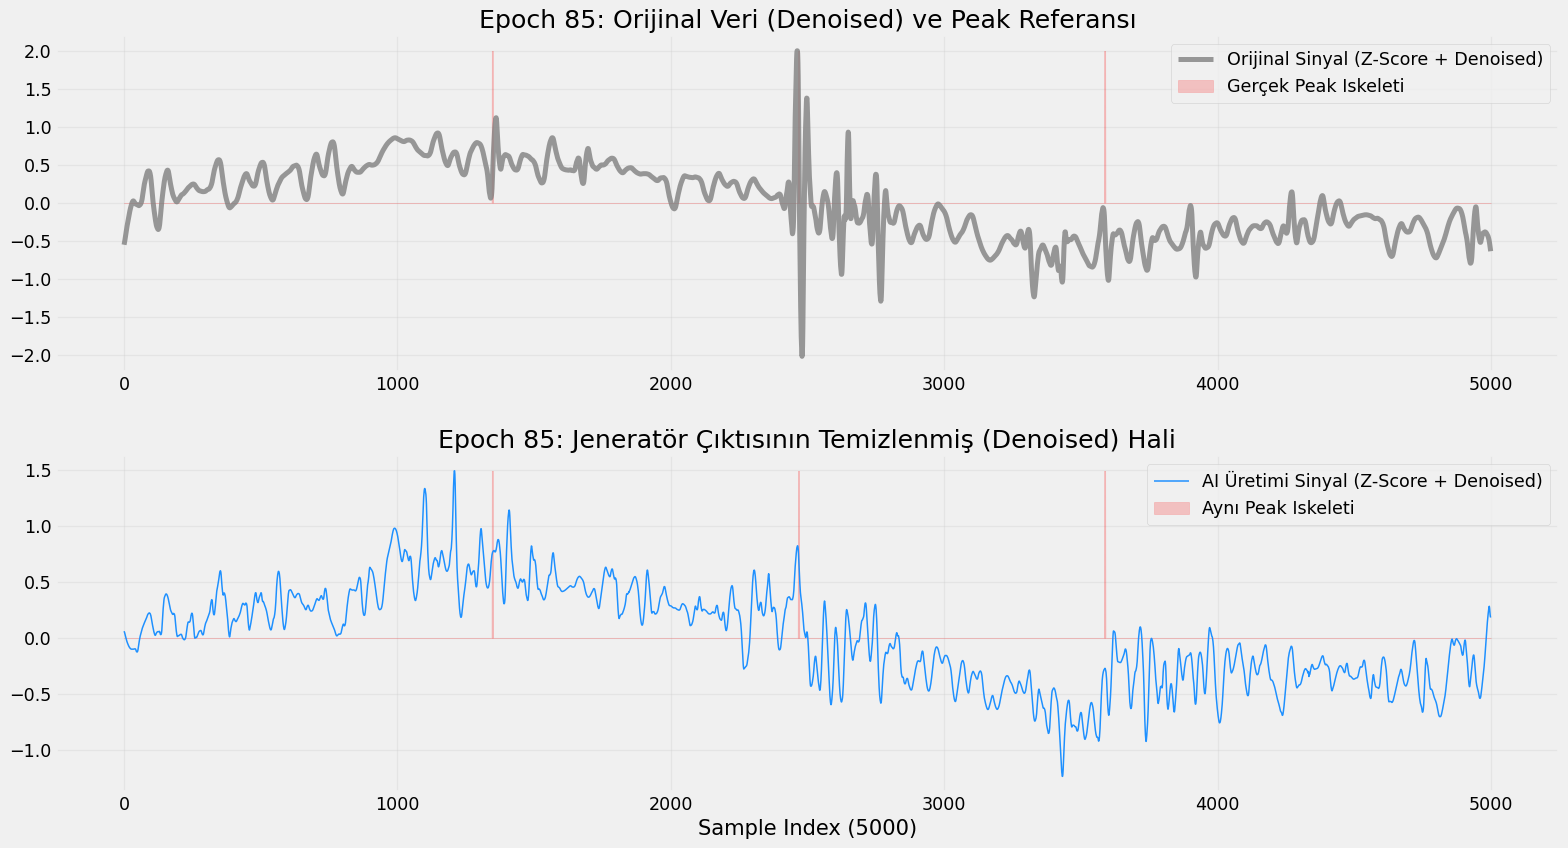

💾 Epoch 85 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 86 BAŞLADI ---
Epoch 86 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.435
Epoch 86 Özet | D_Loss: 0.0000 | G_Total: 7.55 | Rec: 8.75 | Cls: 1.37
Yeni En Düşük G_Loss! (Best Epoch şu an: 86)
--- EPOCH 87 BAŞLADI ---
Epoch 87 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.393
Epoch 87 Özet | D_Loss: 0.0000 | G_Total: 7.54 | Rec: 8.96 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 87)
--- EPOCH 88 BAŞLADI ---
Epoch 88 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.852
Epoch 88 Özet | D_Loss: 0.0000 | G_Total: 7.53 | Rec: 9.38 | Cls: 0.94
Yeni En Düşük G_Loss! (Best Epoch şu an: 88)
--- EPOCH 89 BAŞLADI ---
Epoch 89 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.385
Epoch 89 Özet | D_Loss: 0.0000 | G_Total: 7.48 | Rec: 8.95 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 89)
--- EPOCH 90 BAŞLADI ---
Epoch 90 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.999
Epoch 90 Özet | D_Loss: 0.0000 | G_Total: 7.43 | Rec: 8.56 | Cls: 0.86
Y

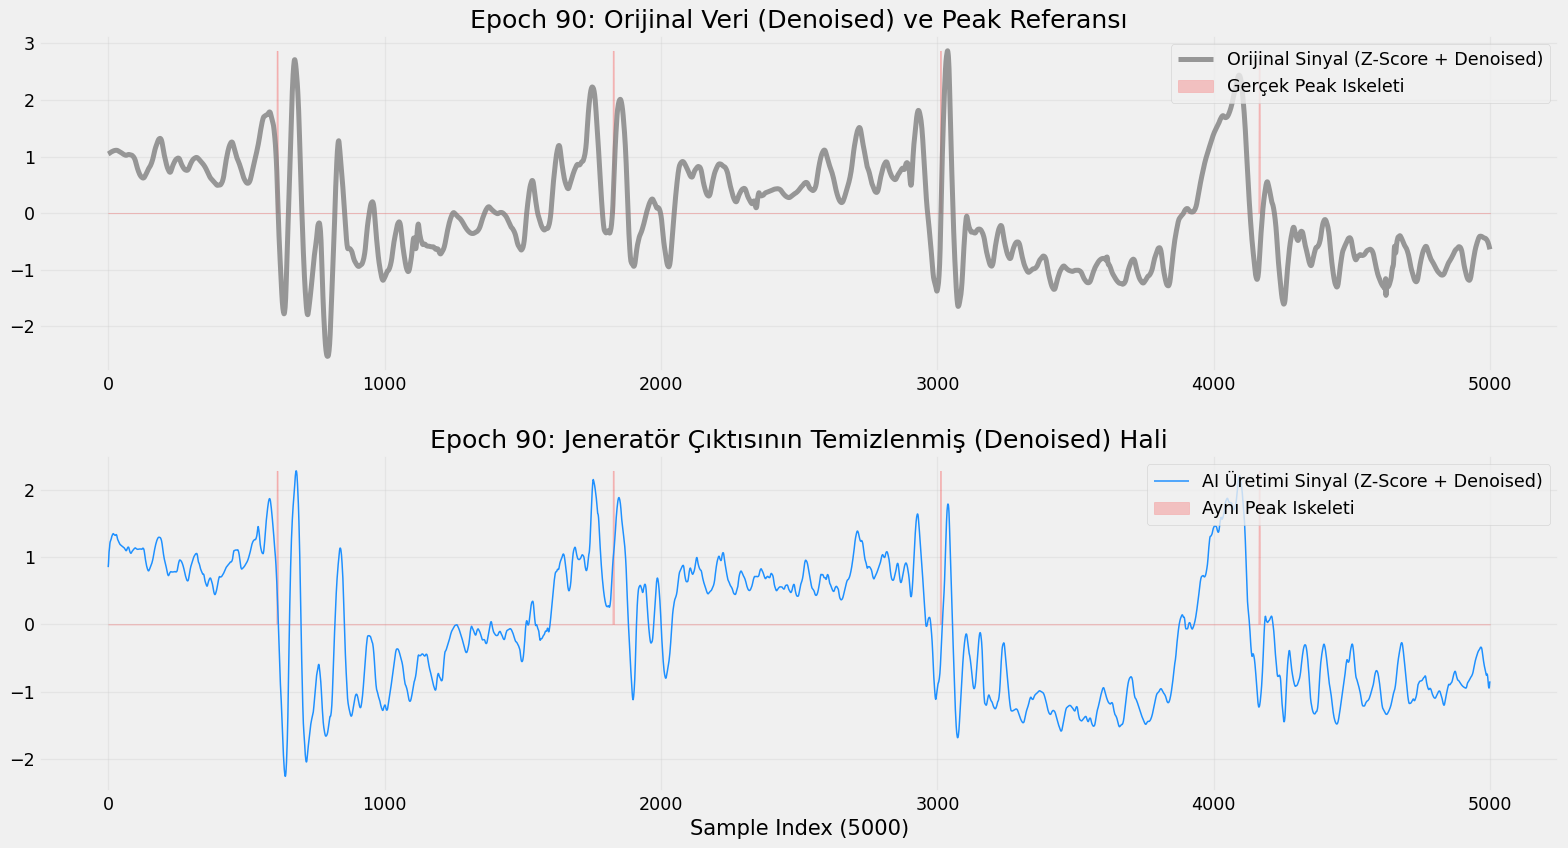

💾 Epoch 90 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 91 BAŞLADI ---
Epoch 91 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.173
Epoch 91 Özet | D_Loss: 0.0000 | G_Total: 7.41 | Rec: 8.67 | Cls: 0.99
Yeni En Düşük G_Loss! (Best Epoch şu an: 91)
--- EPOCH 92 BAŞLADI ---
Epoch 92 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.490
Epoch 92 Özet | D_Loss: 0.0000 | G_Total: 7.34 | Rec: 9.01 | Cls: 0.96
Yeni En Düşük G_Loss! (Best Epoch şu an: 92)
--- EPOCH 93 BAŞLADI ---
Epoch 93 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.205
Epoch 93 Özet | D_Loss: 0.0000 | G_Total: 7.34 | Rec: 8.76 | Cls: 0.87
--- EPOCH 94 BAŞLADI ---
Epoch 94 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.980
Epoch 94 Özet | D_Loss: 0.0000 | G_Total: 7.35 | Rec: 8.48 | Cls: 0.99
--- EPOCH 95 BAŞLADI ---
Epoch 95 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.356
Epoch 95 Özet | D_Loss: 0.0000 | G_Total: 7.29 | Rec: 8.49 | Cls: 1.73
Yeni En Düşük G_Loss! (Best Epoch şu an: 95)


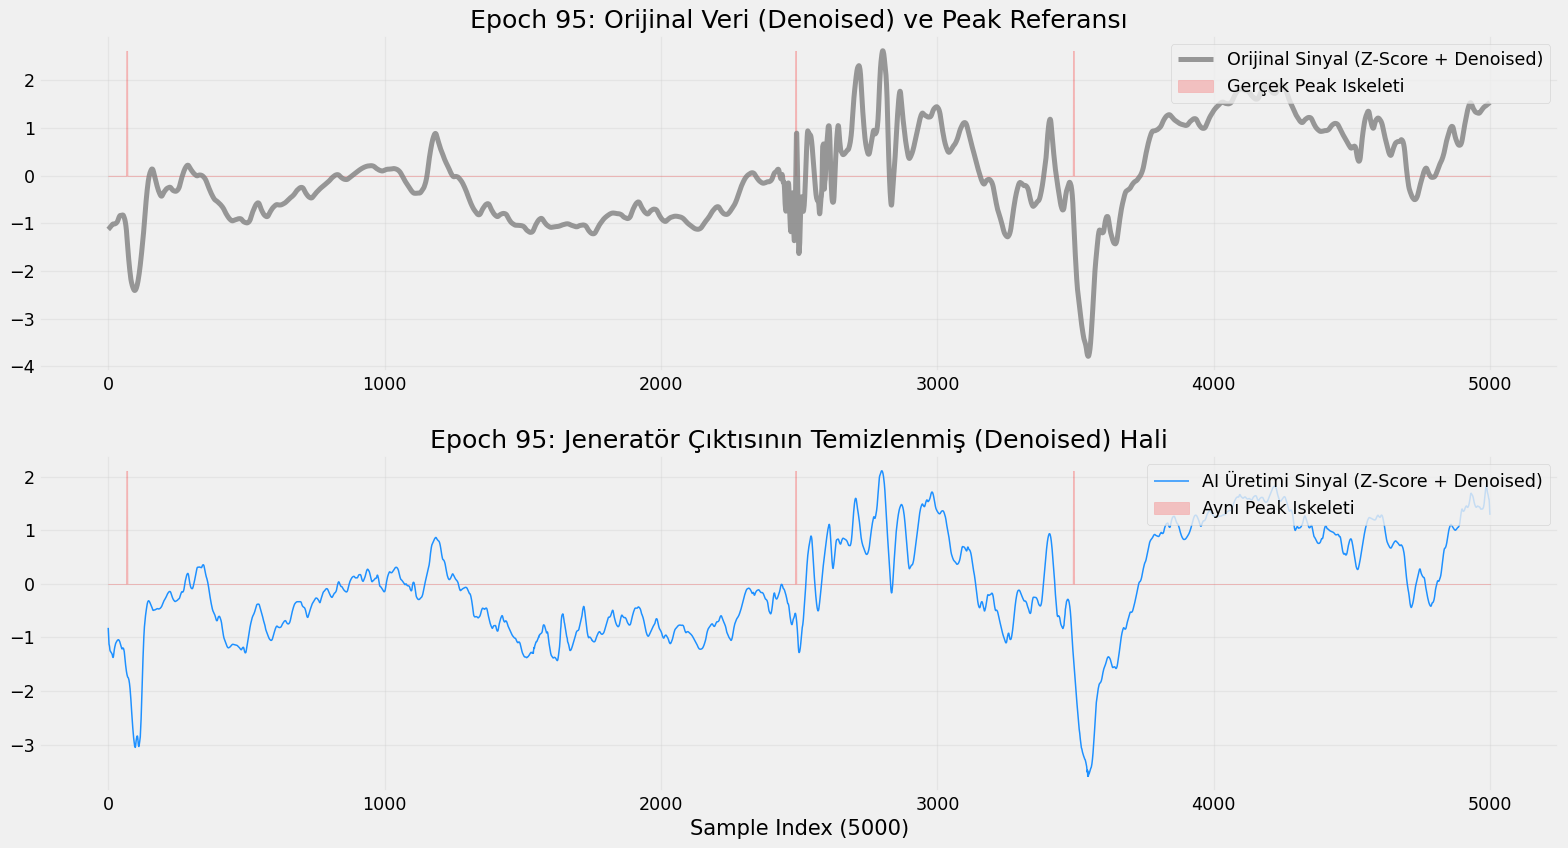

💾 Epoch 95 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 96 BAŞLADI ---
Epoch 96 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.175
Epoch 96 Özet | D_Loss: 0.0000 | G_Total: 7.30 | Rec: 8.70 | Cls: 0.95
--- EPOCH 97 BAŞLADI ---
Epoch 97 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.422
Epoch 97 Özet | D_Loss: 0.0000 | G_Total: 7.25 | Rec: 8.56 | Cls: 1.72
Yeni En Düşük G_Loss! (Best Epoch şu an: 97)
--- EPOCH 98 BAŞLADI ---
Epoch 98 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.900
Epoch 98 Özet | D_Loss: 0.0000 | G_Total: 7.20 | Rec: 8.40 | Cls: 1.01
Yeni En Düşük G_Loss! (Best Epoch şu an: 98)
--- EPOCH 99 BAŞLADI ---
Epoch 99 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.139
Epoch 99 Özet | D_Loss: 0.0000 | G_Total: 7.23 | Rec: 8.70 | Cls: 0.86
--- EPOCH 100 BAŞLADI ---
Epoch 100 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.893
Epoch 100 Özet | D_Loss: 0.0000 | G_Total: 7.21 | Rec: 8.46 | Cls: 0.86


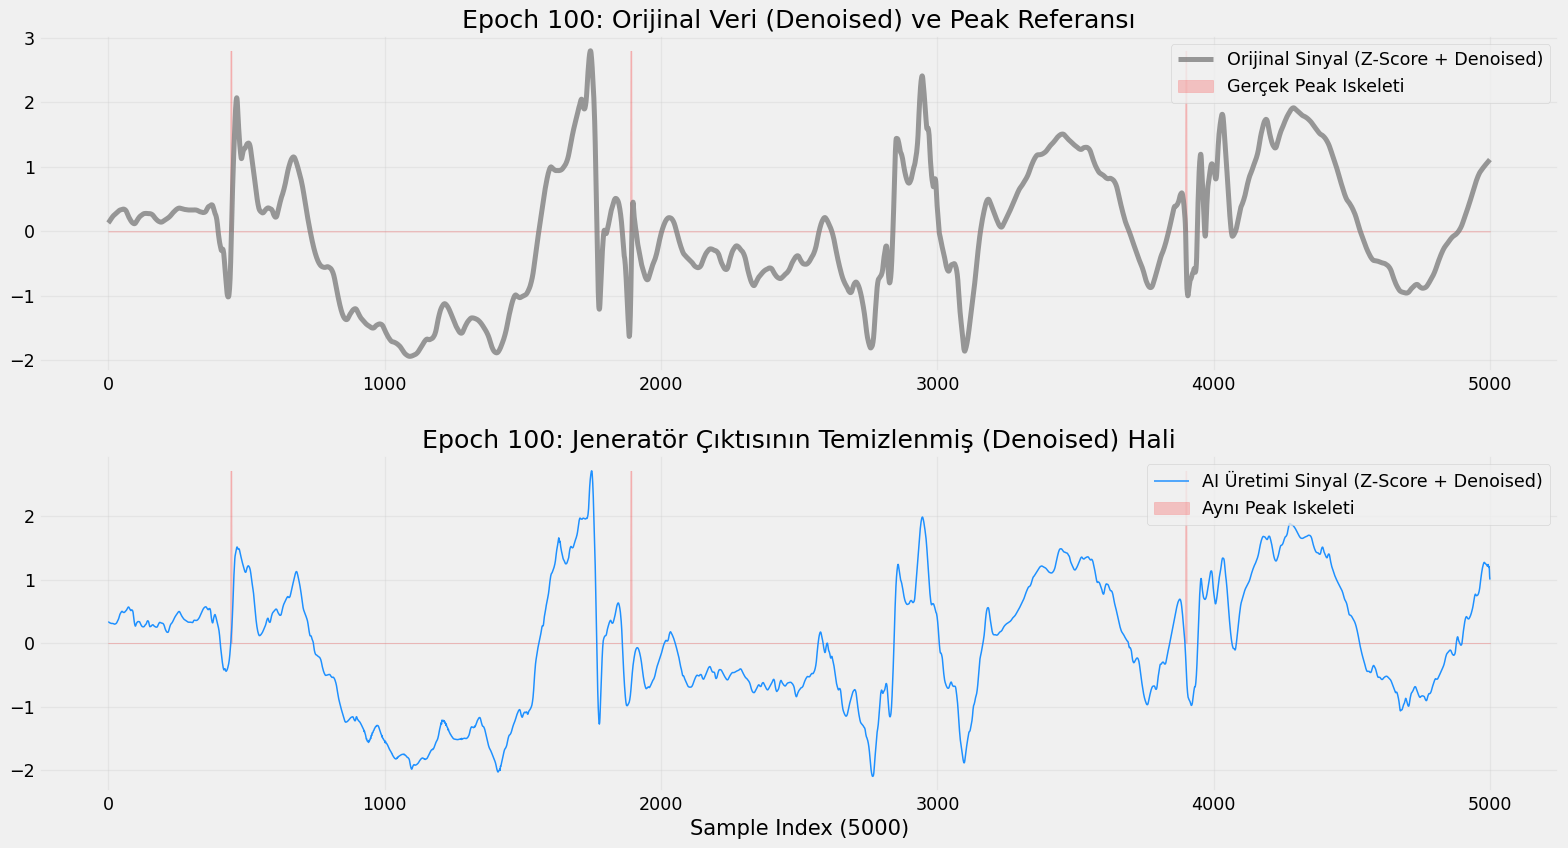

💾 Epoch 100 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 101 BAŞLADI ---
Epoch 101 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.840
Epoch 101 Özet | D_Loss: 0.0000 | G_Total: 7.17 | Rec: 8.41 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 101)
--- EPOCH 102 BAŞLADI ---
Epoch 102 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.735
Epoch 102 Özet | D_Loss: 0.0000 | G_Total: 7.16 | Rec: 8.31 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 102)
--- EPOCH 103 BAŞLADI ---
Epoch 103 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.919
Epoch 103 Özet | D_Loss: 0.0000 | G_Total: 7.11 | Rec: 8.35 | Cls: 1.12
Yeni En Düşük G_Loss! (Best Epoch şu an: 103)
--- EPOCH 104 BAŞLADI ---
Epoch 104 | Step 427/428 | D_Loss: 0.0000 | G_Total: 9.680
Epoch 104 Özet | D_Loss: 0.0000 | G_Total: 7.13 | Rec: 8.82 | Cls: 1.71
--- EPOCH 105 BAŞLADI ---
Epoch 105 | Step 427/428 | D_Loss: 0.0001 | G_Total: 8.7852
Epoch 105 Özet | D_Loss: 0.0751 | G_Total: 7.63 | Rec: 8.34 | Cls: 0.87


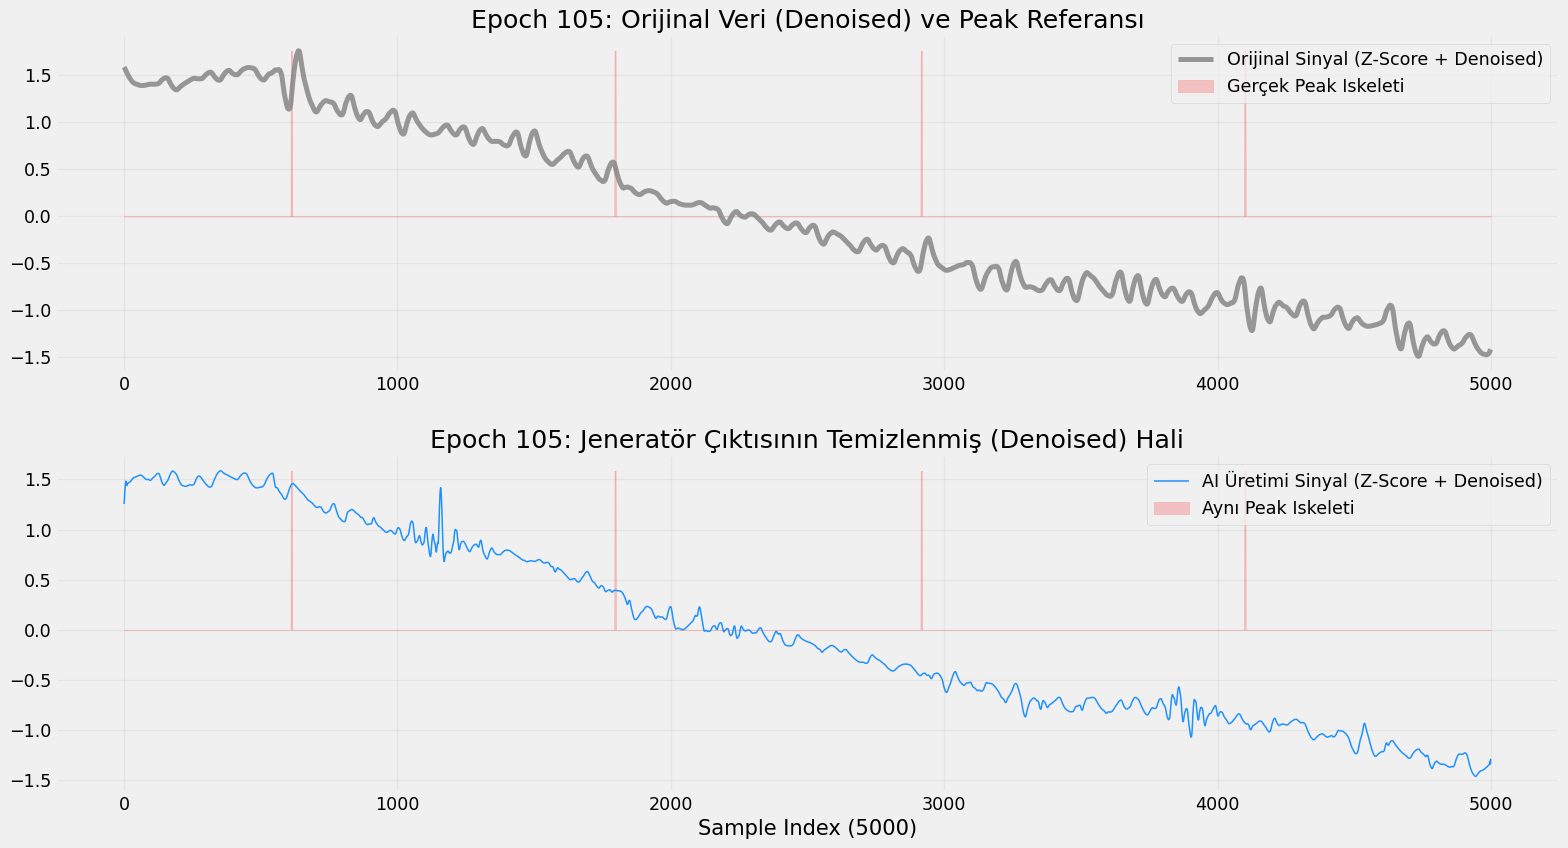

💾 Epoch 105 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 106 BAŞLADI ---
Epoch 106 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.698
Epoch 106 Özet | D_Loss: 0.0001 | G_Total: 7.09 | Rec: 8.23 | Cls: 0.94
Yeni En Düşük G_Loss! (Best Epoch şu an: 106)
--- EPOCH 107 BAŞLADI ---
Epoch 107 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.691
Epoch 107 Özet | D_Loss: 0.0000 | G_Total: 7.03 | Rec: 8.26 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 107)
--- EPOCH 108 BAŞLADI ---
Epoch 108 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.732
Epoch 108 Özet | D_Loss: 0.0000 | G_Total: 7.03 | Rec: 8.28 | Cls: 0.89
--- EPOCH 109 BAŞLADI ---
Epoch 109 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.740
Epoch 109 Özet | D_Loss: 0.0000 | G_Total: 6.99 | Rec: 8.31 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 109)
--- EPOCH 110 BAŞLADI ---
Epoch 110 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.509
Epoch 110 Özet | D_Loss: 0.0000 | G_Total: 6.94 | Rec: 8.05 | Cls: 0.90
Yeni En Düşük G_Loss! (Best

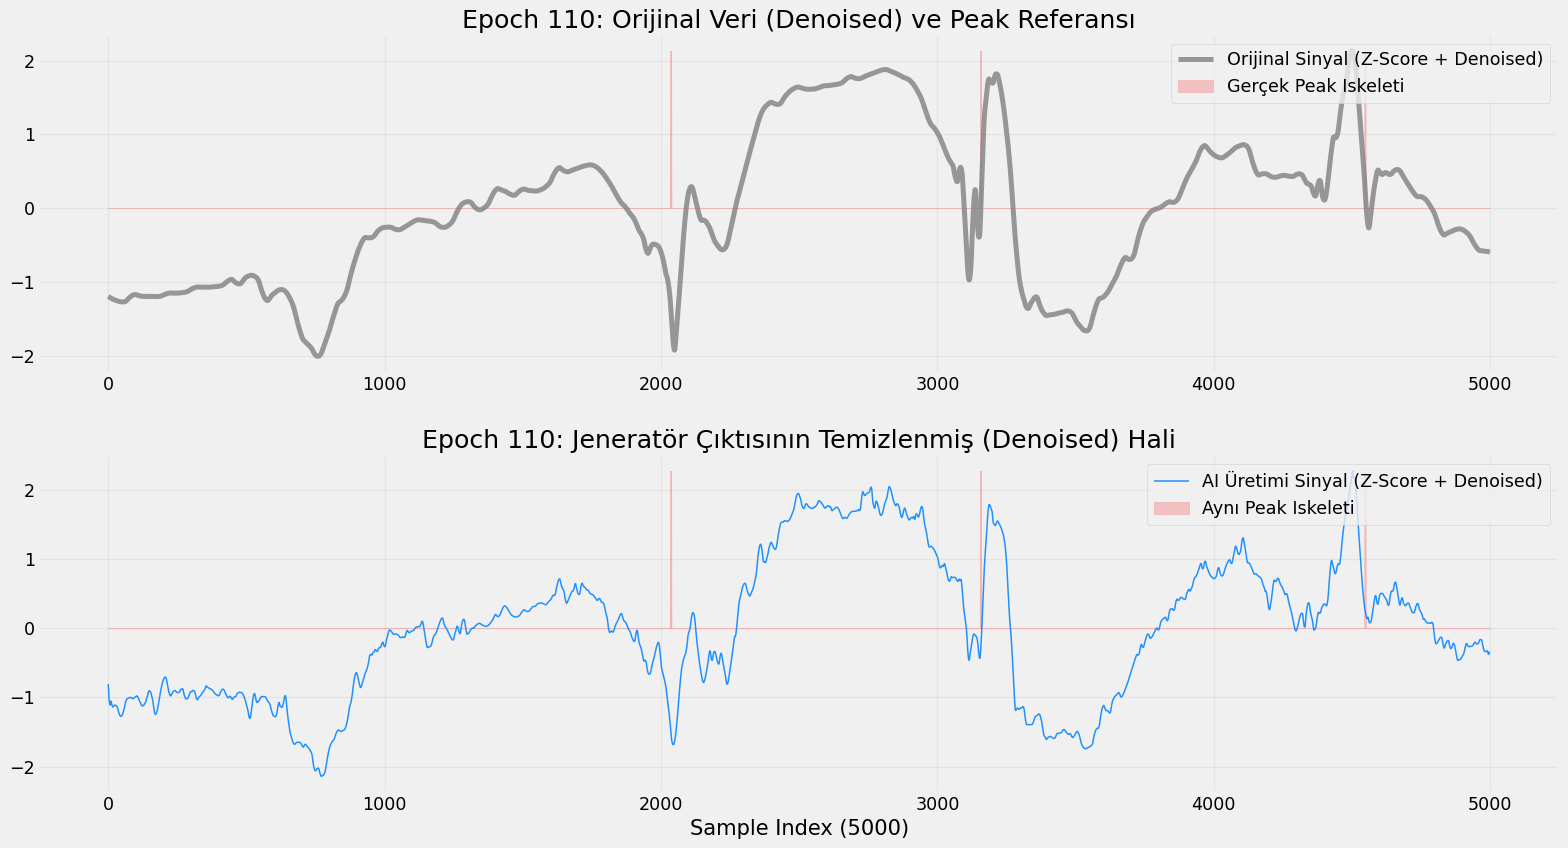

💾 Epoch 110 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 111 BAŞLADI ---
Epoch 111 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.458
Epoch 111 Özet | D_Loss: 0.0000 | G_Total: 6.93 | Rec: 8.01 | Cls: 0.89
Yeni En Düşük G_Loss! (Best Epoch şu an: 111)
--- EPOCH 112 BAŞLADI ---
Epoch 112 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.797
Epoch 112 Özet | D_Loss: 0.0000 | G_Total: 6.93 | Rec: 8.35 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 112)
--- EPOCH 113 BAŞLADI ---
Epoch 113 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.529
Epoch 113 Özet | D_Loss: 0.0000 | G_Total: 6.89 | Rec: 8.09 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 113)
--- EPOCH 114 BAŞLADI ---
Epoch 114 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.752
Epoch 114 Özet | D_Loss: 0.0000 | G_Total: 6.91 | Rec: 8.19 | Cls: 1.11
--- EPOCH 115 BAŞLADI ---
Epoch 115 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.972
Epoch 115 Özet | D_Loss: 0.0000 | G_Total: 6.89 | Rec: 8.19 | Cls: 1.57


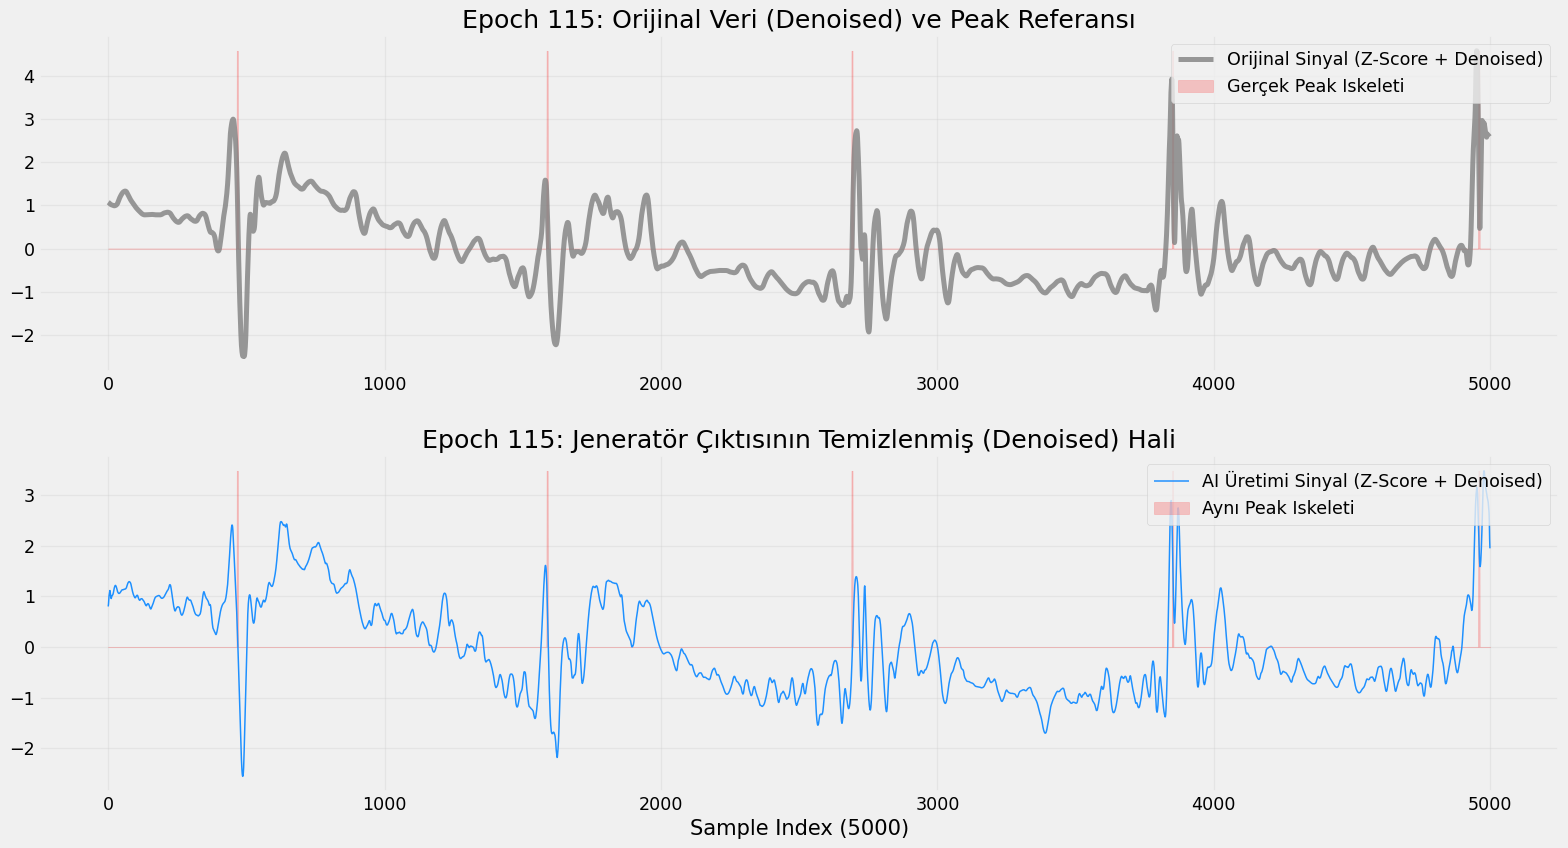

💾 Epoch 115 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 116 BAŞLADI ---
Epoch 116 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.644
Epoch 116 Özet | D_Loss: 0.0000 | G_Total: 6.86 | Rec: 8.21 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 116)
--- EPOCH 117 BAŞLADI ---
Epoch 117 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.783
Epoch 117 Özet | D_Loss: 0.0000 | G_Total: 6.87 | Rec: 8.33 | Cls: 0.89
--- EPOCH 118 BAŞLADI ---
Epoch 118 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.266
Epoch 118 Özet | D_Loss: 0.0000 | G_Total: 6.79 | Rec: 7.83 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 118)
--- EPOCH 119 BAŞLADI ---
Epoch 119 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.465
Epoch 119 Özet | D_Loss: 0.0000 | G_Total: 6.81 | Rec: 8.02 | Cls: 0.87
--- EPOCH 120 BAŞLADI ---
Epoch 120 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.393
Epoch 120 Özet | D_Loss: 0.0000 | G_Total: 6.78 | Rec: 7.96 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 120)


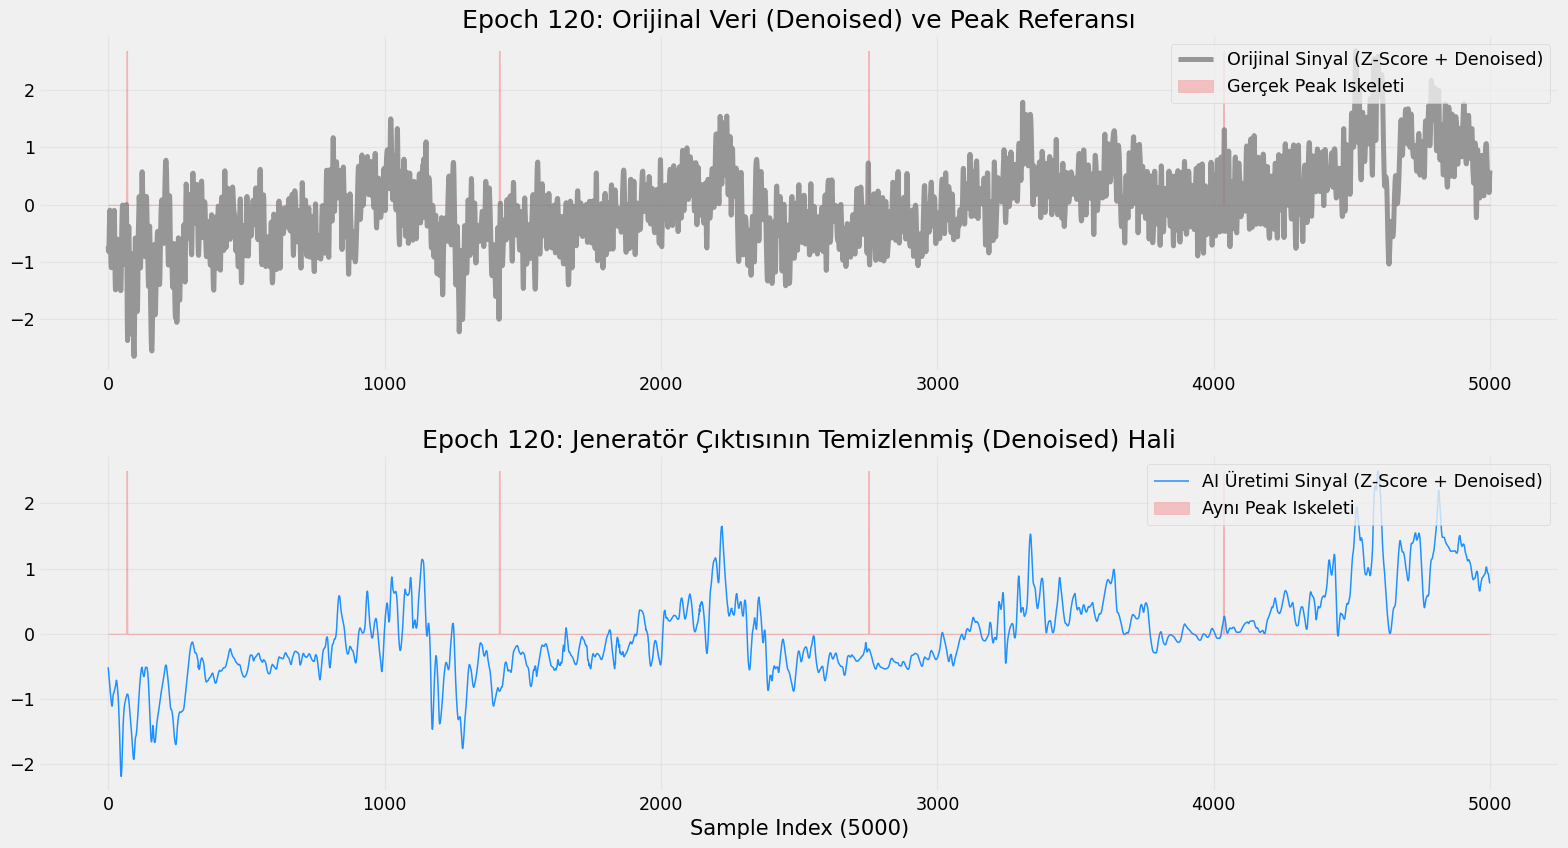

💾 Epoch 120 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 121 BAŞLADI ---
Epoch 121 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.429
Epoch 121 Özet | D_Loss: 0.0000 | G_Total: 6.82 | Rec: 7.97 | Cls: 0.90
--- EPOCH 122 BAŞLADI ---
Epoch 122 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.513
Epoch 122 Özet | D_Loss: 0.0000 | G_Total: 6.78 | Rec: 8.02 | Cls: 0.99
Yeni En Düşük G_Loss! (Best Epoch şu an: 122)
--- EPOCH 123 BAŞLADI ---
Epoch 123 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.487
Epoch 123 Özet | D_Loss: 0.0000 | G_Total: 6.74 | Rec: 8.04 | Cls: 0.88
Yeni En Düşük G_Loss! (Best Epoch şu an: 123)
--- EPOCH 124 BAŞLADI ---
Epoch 124 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.891
Epoch 124 Özet | D_Loss: 0.0000 | G_Total: 6.69 | Rec: 8.03 | Cls: 1.72
Yeni En Düşük G_Loss! (Best Epoch şu an: 124)
--- EPOCH 125 BAŞLADI ---
Epoch 125 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.329
Epoch 125 Özet | D_Loss: 0.0000 | G_Total: 6.74 | Rec: 7.87 | Cls: 0.91


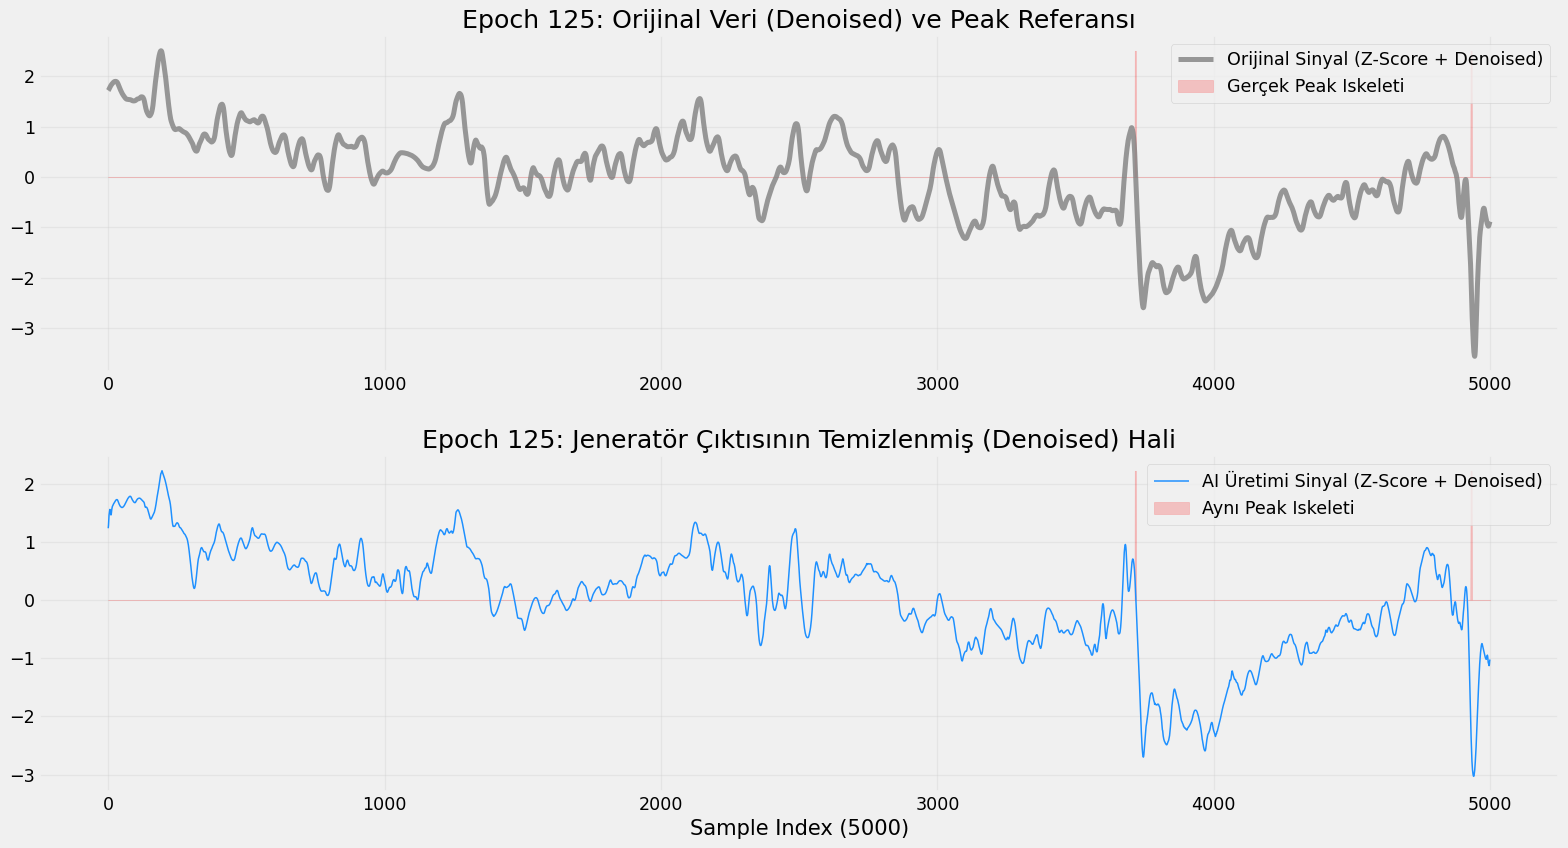

💾 Epoch 125 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 126 BAŞLADI ---
Epoch 126 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.546
Epoch 126 Özet | D_Loss: 0.0000 | G_Total: 6.73 | Rec: 8.11 | Cls: 0.86
--- EPOCH 127 BAŞLADI ---
Epoch 127 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.261
Epoch 127 Özet | D_Loss: 0.0000 | G_Total: 6.68 | Rec: 7.83 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 127)
--- EPOCH 128 BAŞLADI ---
Epoch 128 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.118
Epoch 128 Özet | D_Loss: 0.0000 | G_Total: 6.67 | Rec: 7.68 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 128)
--- EPOCH 129 BAŞLADI ---
Epoch 129 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.174
Epoch 129 Özet | D_Loss: 0.0000 | G_Total: 6.66 | Rec: 7.63 | Cls: 1.07
Yeni En Düşük G_Loss! (Best Epoch şu an: 129)
--- EPOCH 130 BAŞLADI ---
Epoch 130 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.492
Epoch 130 Özet | D_Loss: 0.0000 | G_Total: 6.63 | Rec: 7.87 | Cls: 1.25
Yeni En Düşük G_Loss! (Best

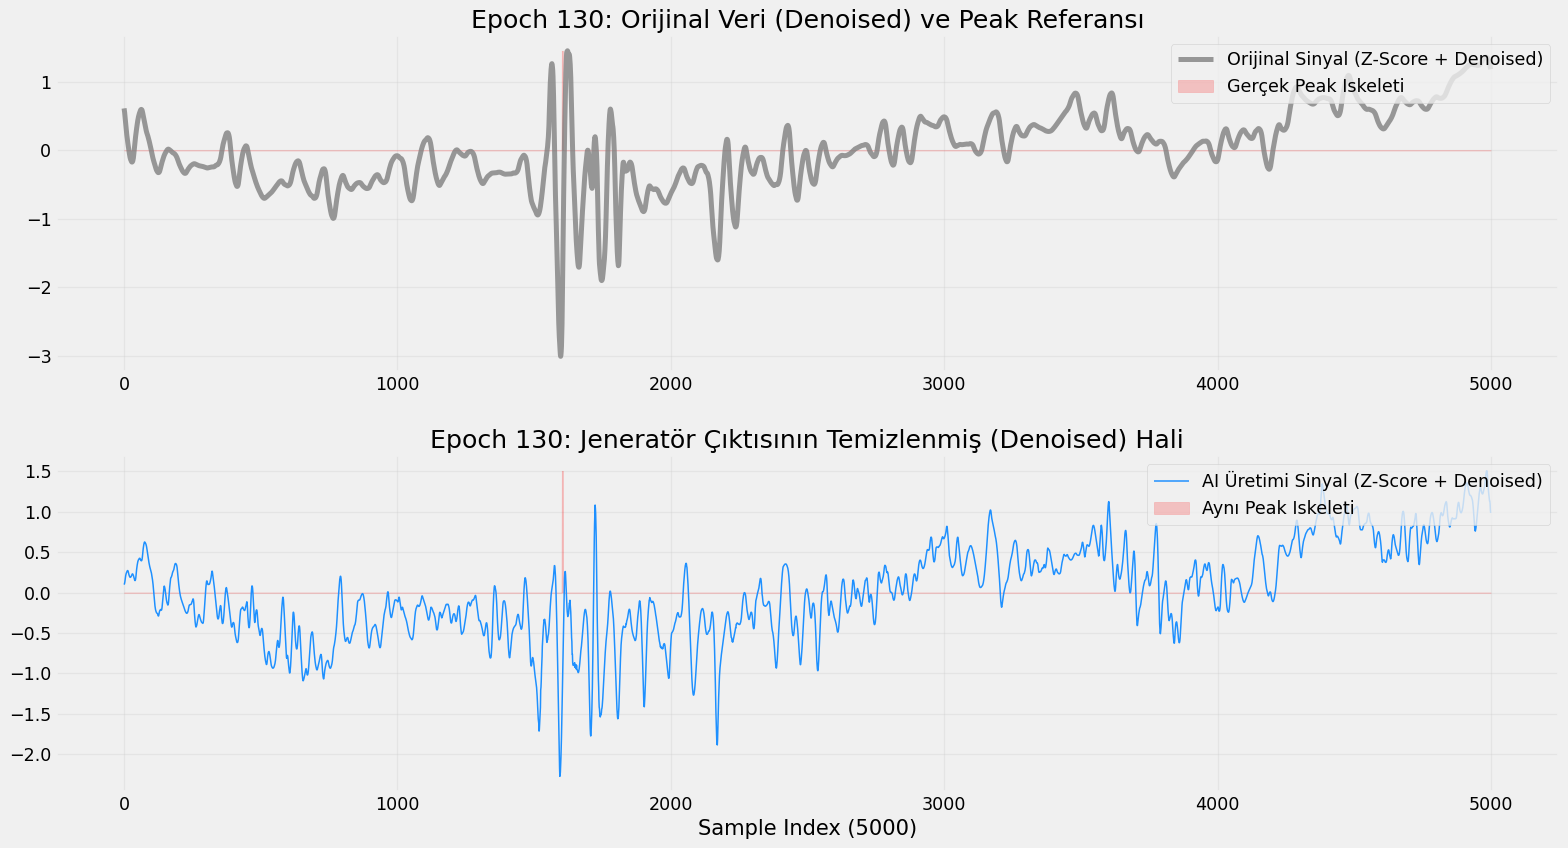

💾 Epoch 130 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 131 BAŞLADI ---
Epoch 131 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.866
Epoch 131 Özet | D_Loss: 0.0000 | G_Total: 6.63 | Rec: 8.21 | Cls: 1.31
Yeni En Düşük G_Loss! (Best Epoch şu an: 131)
--- EPOCH 132 BAŞLADI ---
Epoch 132 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.531
Epoch 132 Özet | D_Loss: 0.0266 | G_Total: 6.84 | Rec: 8.04 | Cls: 0.97
--- EPOCH 133 BAŞLADI ---
Epoch 133 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.721
Epoch 133 Özet | D_Loss: 0.0001 | G_Total: 6.68 | Rec: 8.29 | Cls: 0.86
--- EPOCH 134 BAŞLADI ---
Epoch 134 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.255
Epoch 134 Özet | D_Loss: 0.0000 | G_Total: 6.64 | Rec: 7.79 | Cls: 0.92
--- EPOCH 135 BAŞLADI ---
Epoch 135 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.435
Epoch 135 Özet | D_Loss: 0.0000 | G_Total: 6.60 | Rec: 7.99 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 135)


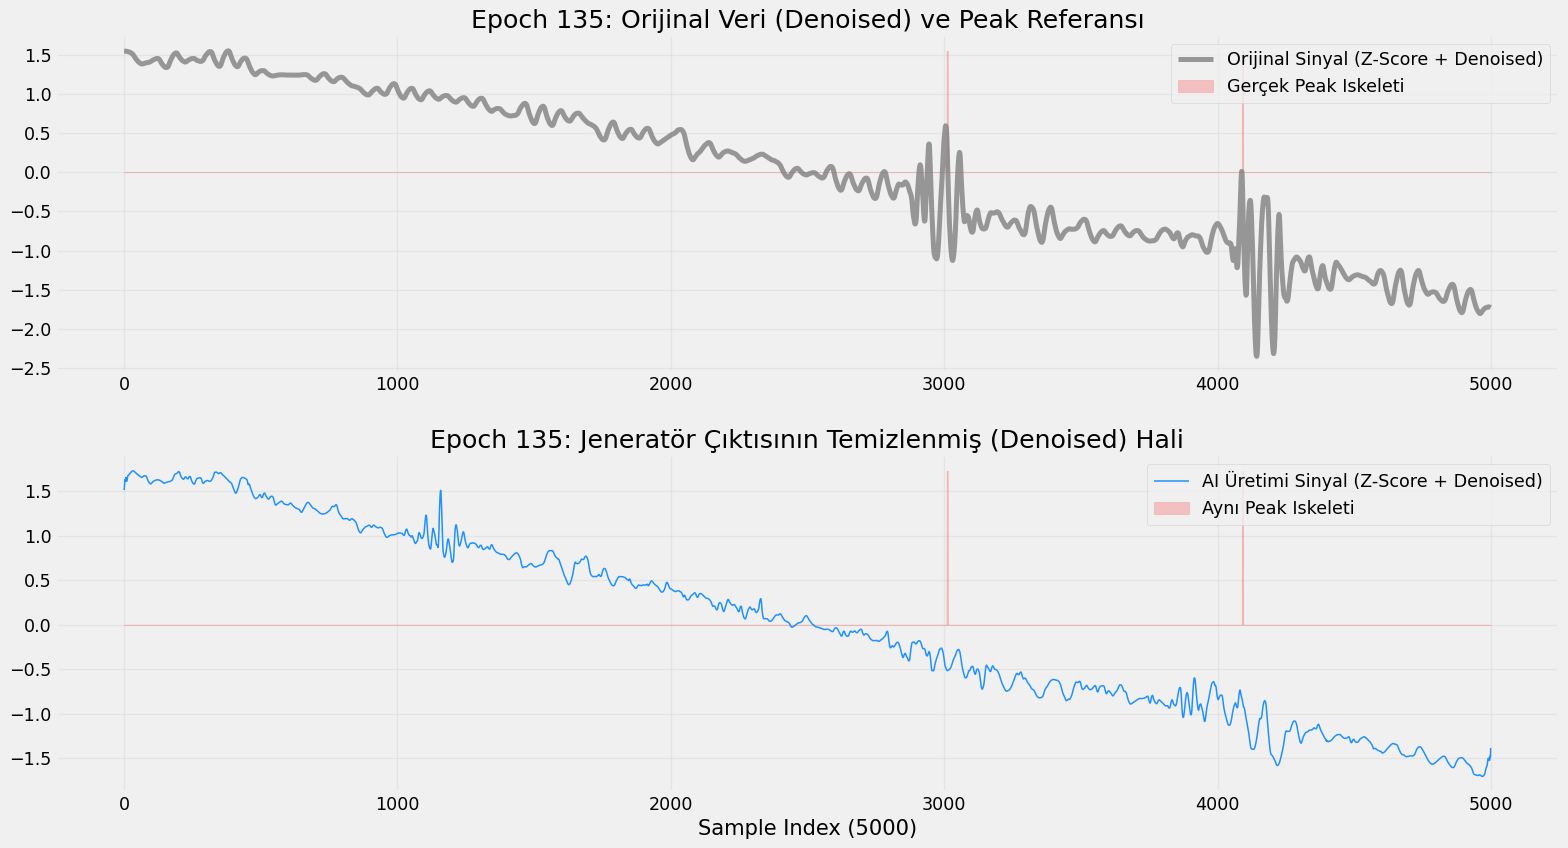

💾 Epoch 135 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 136 BAŞLADI ---
Epoch 136 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.290
Epoch 136 Özet | D_Loss: 0.0000 | G_Total: 6.62 | Rec: 7.86 | Cls: 0.86
--- EPOCH 137 BAŞLADI ---
Epoch 137 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.995
Epoch 137 Özet | D_Loss: 0.0000 | G_Total: 6.58 | Rec: 7.55 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 137)
--- EPOCH 138 BAŞLADI ---
Epoch 138 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.063
Epoch 138 Özet | D_Loss: 0.0000 | G_Total: 6.58 | Rec: 7.60 | Cls: 0.91
--- EPOCH 139 BAŞLADI ---
Epoch 139 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.453
Epoch 139 Özet | D_Loss: 0.0000 | G_Total: 6.56 | Rec: 8.02 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 139)
--- EPOCH 140 BAŞLADI ---
Epoch 140 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.291
Epoch 140 Özet | D_Loss: 0.0000 | G_Total: 6.58 | Rec: 7.86 | Cls: 0.86


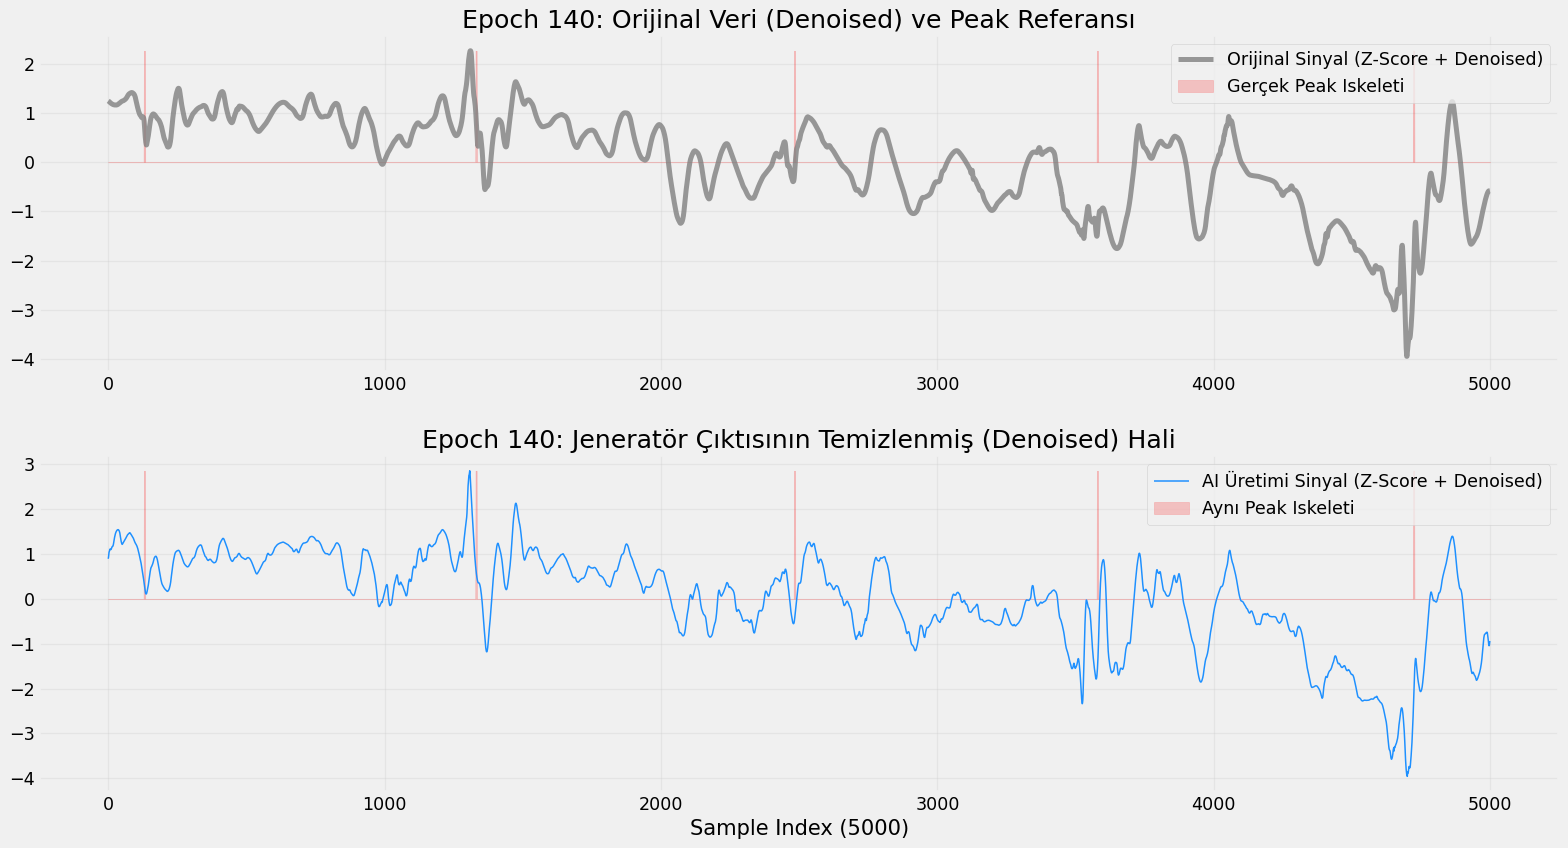

💾 Epoch 140 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 141 BAŞLADI ---
Epoch 141 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.023
Epoch 141 Özet | D_Loss: 0.0000 | G_Total: 6.53 | Rec: 7.59 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 141)
--- EPOCH 142 BAŞLADI ---
Epoch 142 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.051
Epoch 142 Özet | D_Loss: 0.0000 | G_Total: 6.54 | Rec: 7.57 | Cls: 0.95
--- EPOCH 143 BAŞLADI ---
Epoch 143 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.200
Epoch 143 Özet | D_Loss: 0.0000 | G_Total: 6.55 | Rec: 7.77 | Cls: 0.86
--- EPOCH 144 BAŞLADI ---
Epoch 144 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.940
Epoch 144 Özet | D_Loss: 0.0000 | G_Total: 6.48 | Rec: 7.51 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 144)
--- EPOCH 145 BAŞLADI ---
Epoch 145 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.911
Epoch 145 Özet | D_Loss: 0.0000 | G_Total: 6.47 | Rec: 7.42 | Cls: 0.98
Yeni En Düşük G_Loss! (Best Epoch şu an: 145)


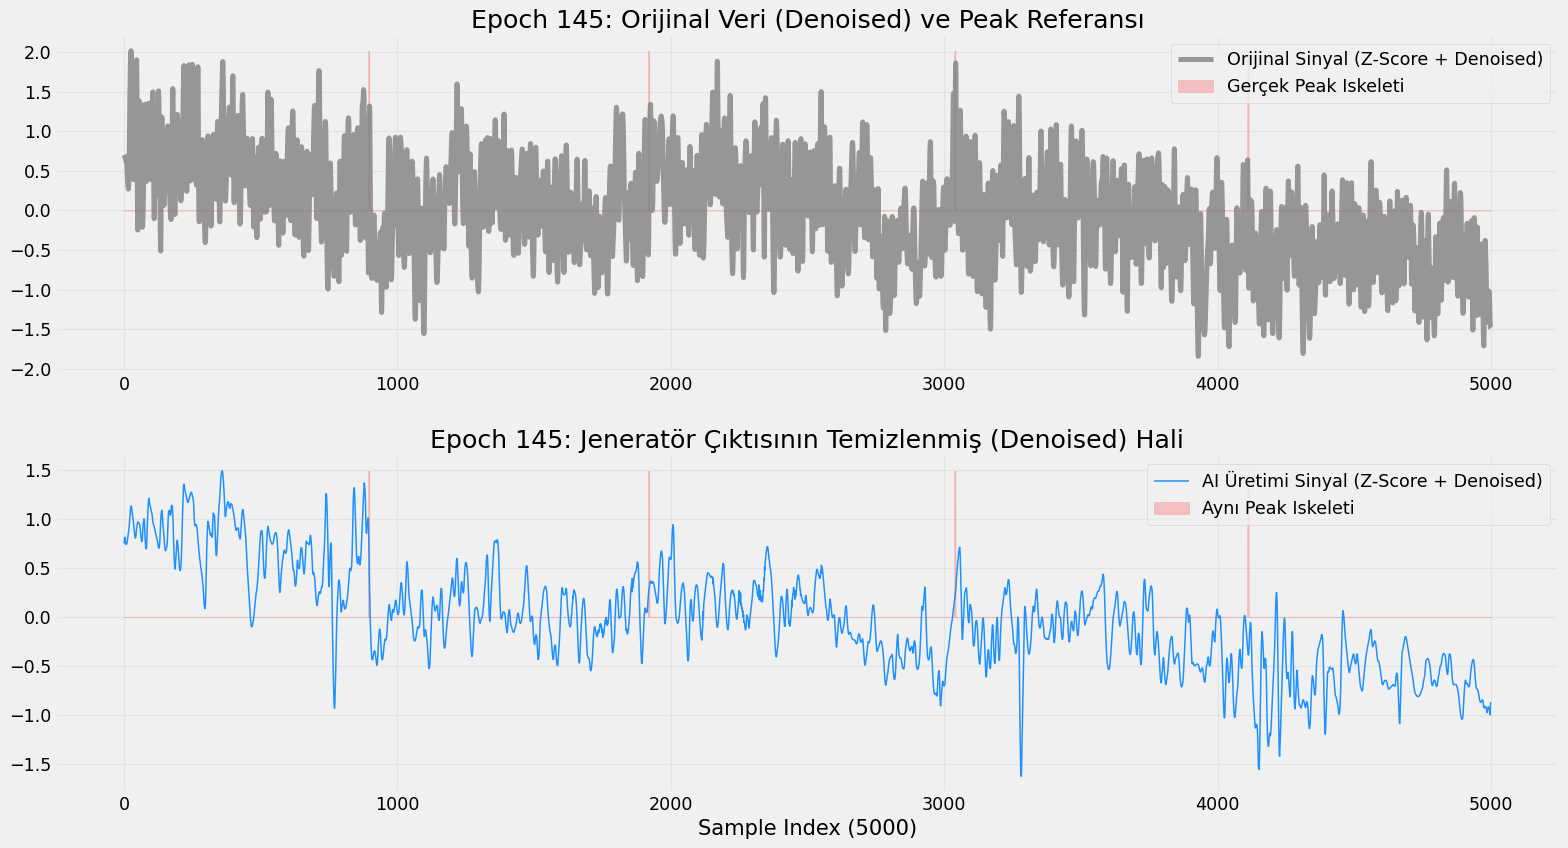

💾 Epoch 145 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 146 BAŞLADI ---
Epoch 146 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.910
Epoch 146 Özet | D_Loss: 0.0000 | G_Total: 6.48 | Rec: 7.63 | Cls: 2.57
--- EPOCH 147 BAŞLADI ---
Epoch 147 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.834
Epoch 147 Özet | D_Loss: 0.0000 | G_Total: 6.46 | Rec: 7.54 | Cls: 2.59
Yeni En Düşük G_Loss! (Best Epoch şu an: 147)
--- EPOCH 148 BAŞLADI ---
Epoch 148 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.247
Epoch 148 Özet | D_Loss: 0.0000 | G_Total: 6.45 | Rec: 7.61 | Cls: 1.27
Yeni En Düşük G_Loss! (Best Epoch şu an: 148)
--- EPOCH 149 BAŞLADI ---
Epoch 149 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.041
Epoch 149 Özet | D_Loss: 0.0000 | G_Total: 6.46 | Rec: 7.59 | Cls: 0.90
--- EPOCH 150 BAŞLADI ---
Epoch 150 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.338
Epoch 150 Özet | D_Loss: 0.0000 | G_Total: 6.43 | Rec: 7.89 | Cls: 0.88
Yeni En Düşük G_Loss! (Best Epoch şu an: 150)


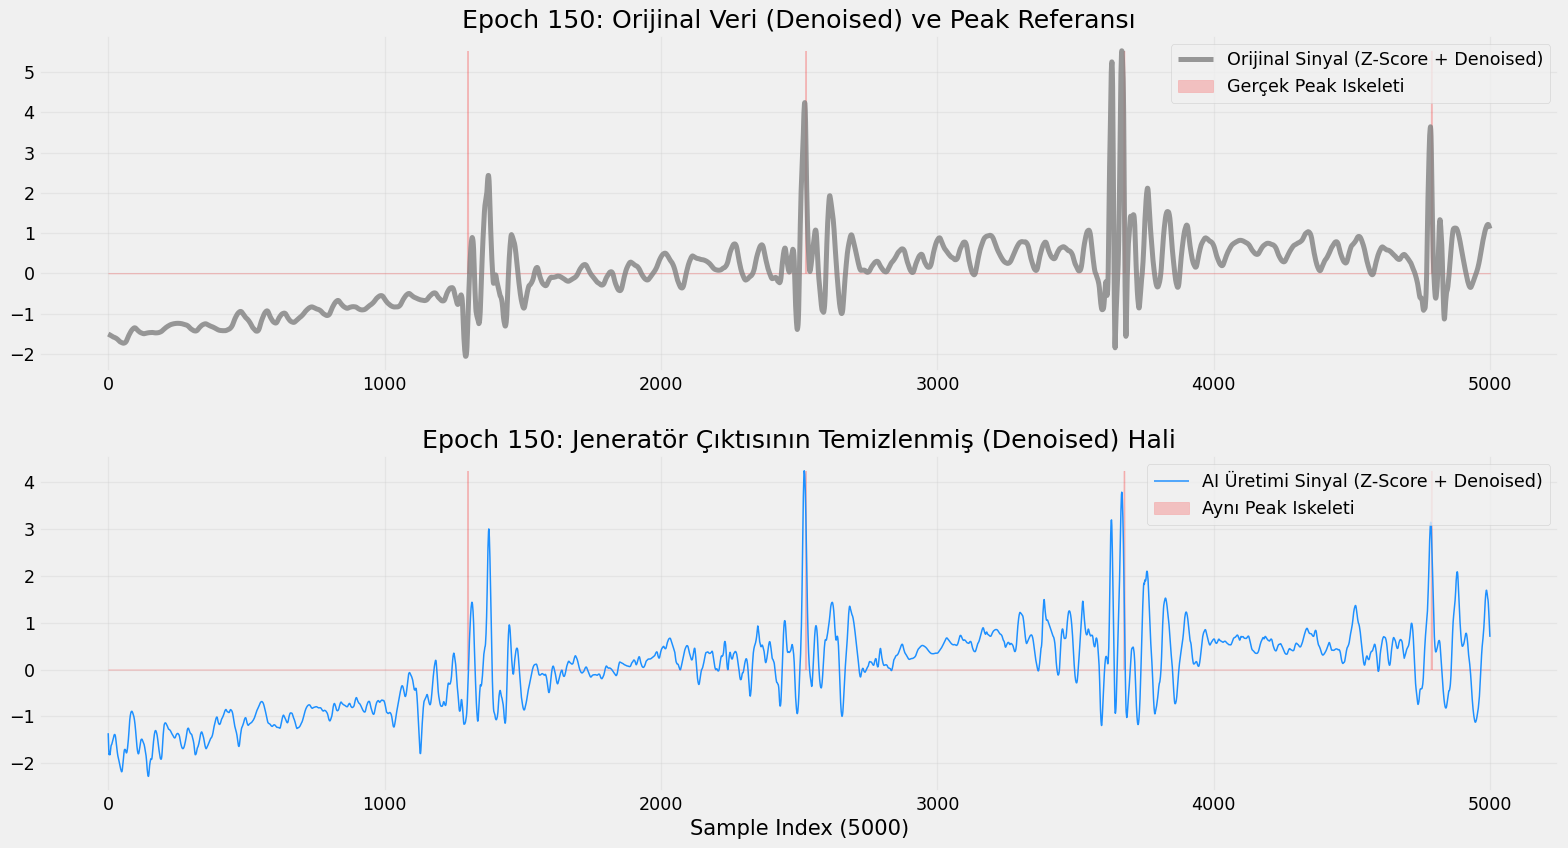

💾 Epoch 150 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 151 BAŞLADI ---
Epoch 151 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.216
Epoch 151 Özet | D_Loss: 0.0000 | G_Total: 6.40 | Rec: 7.77 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 151)
--- EPOCH 152 BAŞLADI ---
Epoch 152 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.079
Epoch 152 Özet | D_Loss: 0.0000 | G_Total: 6.40 | Rec: 7.63 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 152)
--- EPOCH 153 BAŞLADI ---
Epoch 153 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.747
Epoch 153 Özet | D_Loss: 0.0000 | G_Total: 6.39 | Rec: 7.31 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 153)
--- EPOCH 154 BAŞLADI ---
Epoch 154 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.307
Epoch 154 Özet | D_Loss: 0.0000 | G_Total: 6.39 | Rec: 7.43 | Cls: 1.72
Yeni En Düşük G_Loss! (Best Epoch şu an: 154)
--- EPOCH 155 BAŞLADI ---
Epoch 155 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.811
Epoch 155 Özet | D_Loss: 0.0000 | G_Total: 6.39 | Rec

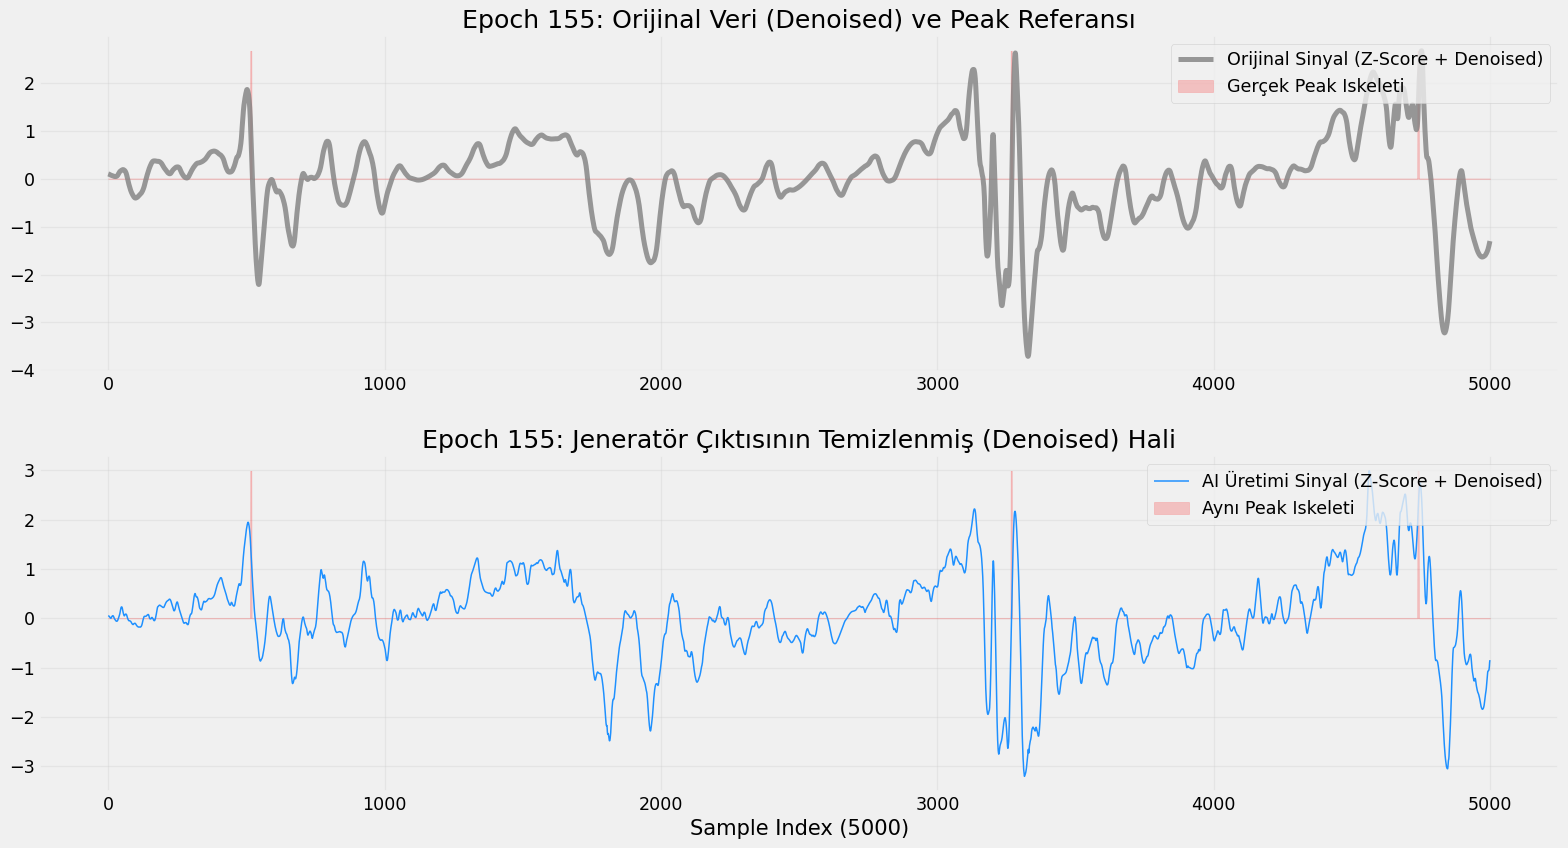

💾 Epoch 155 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 156 BAŞLADI ---
Epoch 156 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.700
Epoch 156 Özet | D_Loss: 0.0000 | G_Total: 6.37 | Rec: 7.26 | Cls: 0.88
Yeni En Düşük G_Loss! (Best Epoch şu an: 156)
--- EPOCH 157 BAŞLADI ---
Epoch 157 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.067
Epoch 157 Özet | D_Loss: 0.0000 | G_Total: 6.36 | Rec: 7.60 | Cls: 0.90
Yeni En Düşük G_Loss! (Best Epoch şu an: 157)
--- EPOCH 158 BAŞLADI ---
Epoch 158 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.993
Epoch 158 Özet | D_Loss: 0.0000 | G_Total: 6.38 | Rec: 7.56 | Cls: 0.86
--- EPOCH 159 BAŞLADI ---
Epoch 159 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.861
Epoch 159 Özet | D_Loss: 0.0000 | G_Total: 6.36 | Rec: 7.42 | Cls: 0.88
Yeni En Düşük G_Loss! (Best Epoch şu an: 159)
--- EPOCH 160 BAŞLADI ---
Epoch 160 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.758
Epoch 160 Özet | D_Loss: 0.0000 | G_Total: 6.34 | Rec: 7.31 | Cls: 0.87
Yeni En Düşük G_Loss! (Best

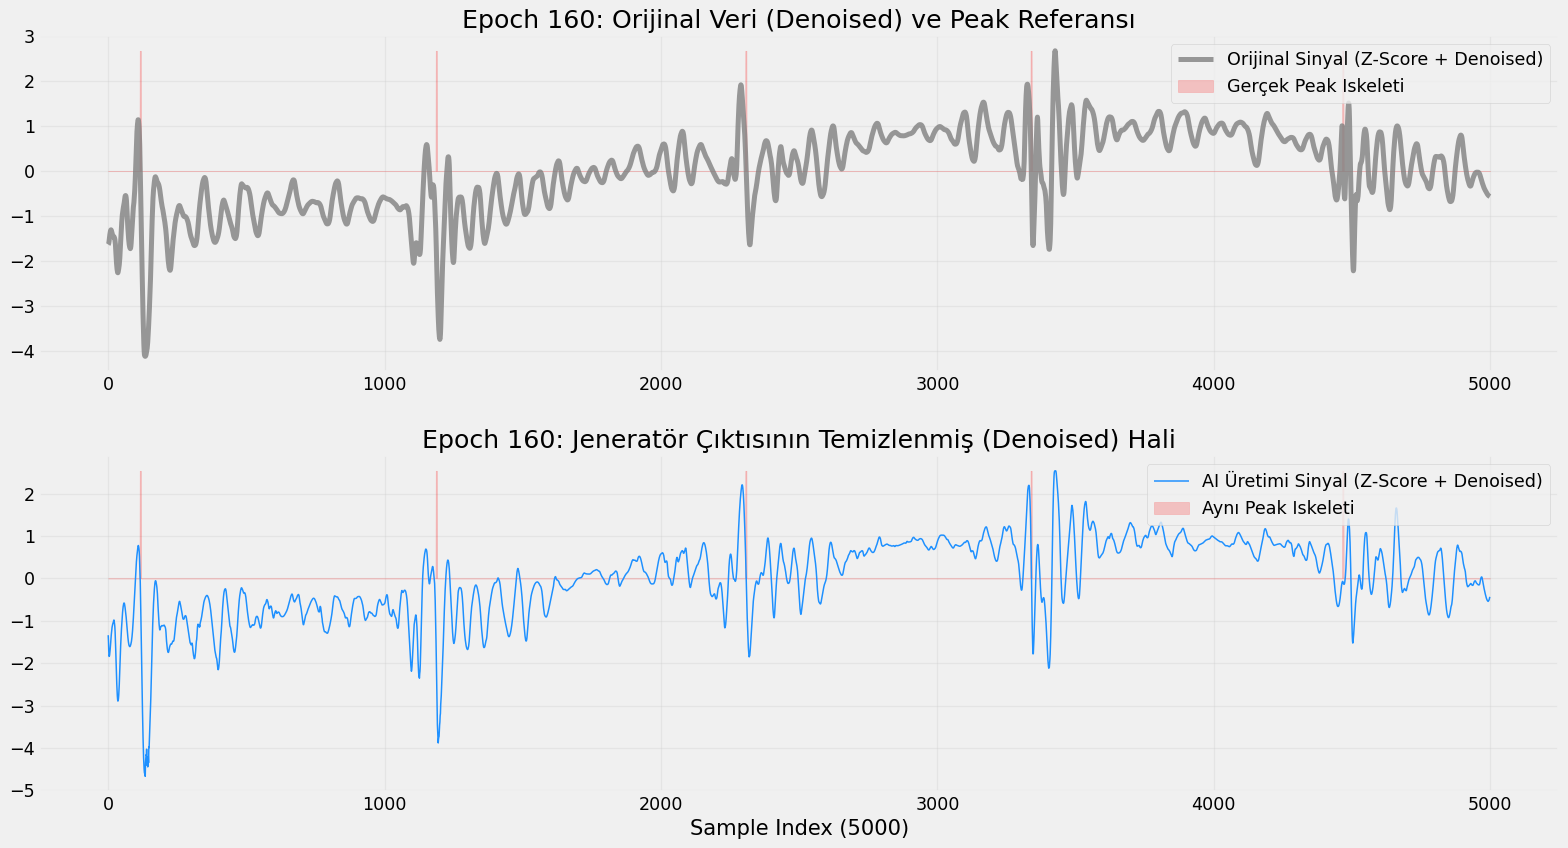

💾 Epoch 160 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 161 BAŞLADI ---
Epoch 161 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.122
Epoch 161 Özet | D_Loss: 0.0000 | G_Total: 6.37 | Rec: 7.32 | Cls: 1.60
--- EPOCH 162 BAŞLADI ---
Epoch 162 | Step 427/428 | D_Loss: 0.0001 | G_Total: 7.952
Epoch 162 Özet | D_Loss: 0.0172 | G_Total: 6.49 | Rec: 7.52 | Cls: 0.86
--- EPOCH 163 BAŞLADI ---
Epoch 163 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.636
Epoch 163 Özet | D_Loss: 0.0002 | G_Total: 6.36 | Rec: 7.19 | Cls: 0.90
--- EPOCH 164 BAŞLADI ---
Epoch 164 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.845
Epoch 164 Özet | D_Loss: 0.0000 | G_Total: 6.32 | Rec: 7.33 | Cls: 1.03
Yeni En Düşük G_Loss! (Best Epoch şu an: 164)
--- EPOCH 165 BAŞLADI ---
Epoch 165 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.961
Epoch 165 Özet | D_Loss: 0.0000 | G_Total: 6.29 | Rec: 7.45 | Cls: 1.01
Yeni En Düşük G_Loss! (Best Epoch şu an: 165)


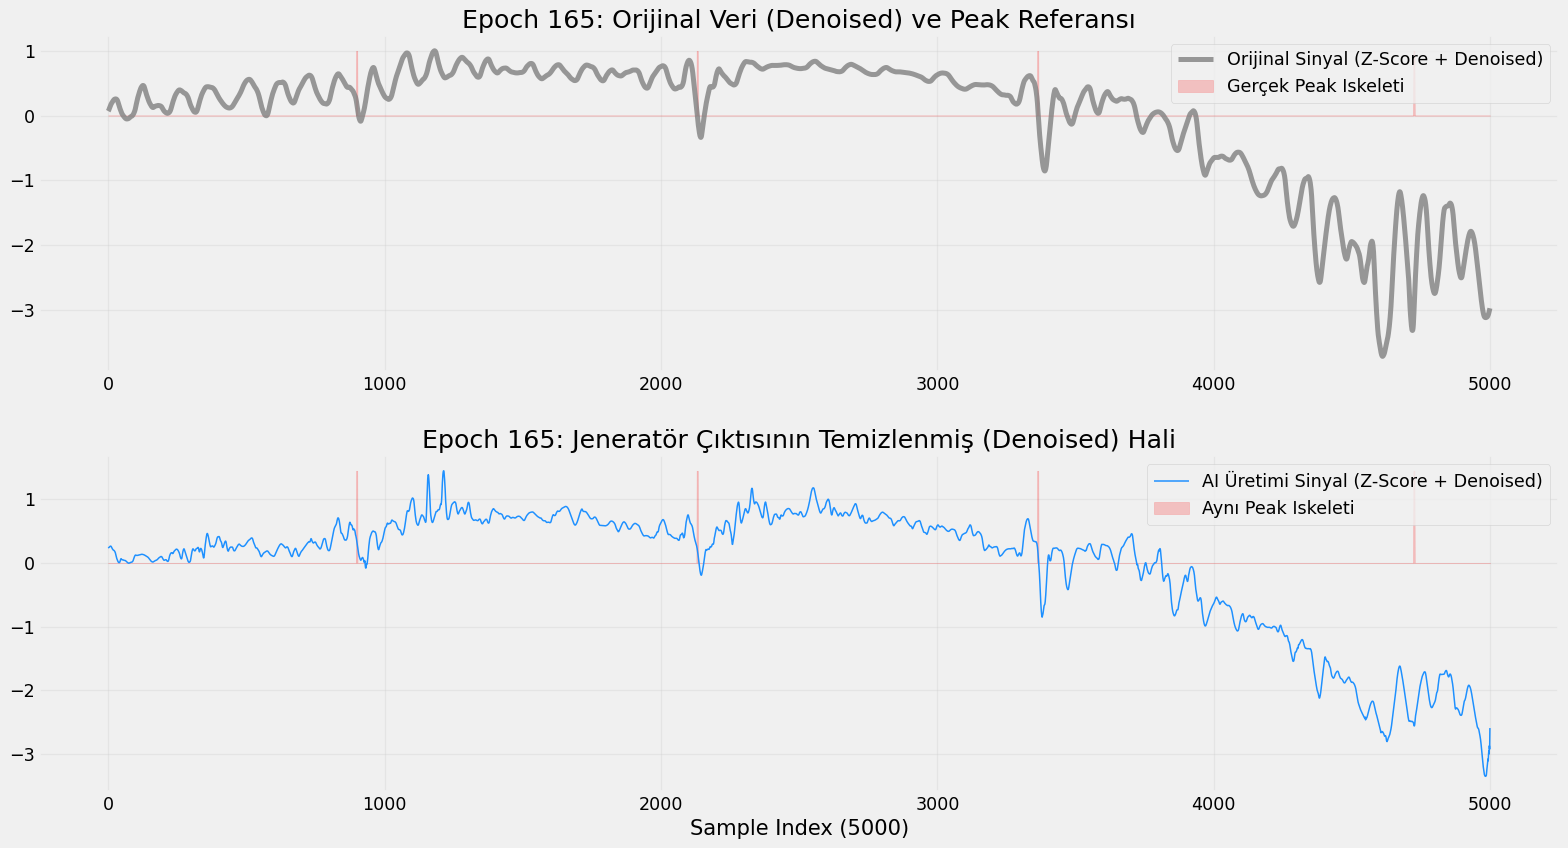

💾 Epoch 165 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 166 BAŞLADI ---
Epoch 166 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.081
Epoch 166 Özet | D_Loss: 0.0000 | G_Total: 6.28 | Rec: 7.65 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 166)
--- EPOCH 167 BAŞLADI ---
Epoch 167 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.643
Epoch 167 Özet | D_Loss: 0.0000 | G_Total: 6.24 | Rec: 7.21 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 167)
--- EPOCH 168 BAŞLADI ---
Epoch 168 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.601
Epoch 168 Özet | D_Loss: 0.0000 | G_Total: 6.25 | Rec: 7.17 | Cls: 0.86
--- EPOCH 169 BAŞLADI ---
Epoch 169 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.530
Epoch 169 Özet | D_Loss: 0.0000 | G_Total: 6.29 | Rec: 7.09 | Cls: 0.89
--- EPOCH 170 BAŞLADI ---
Epoch 170 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.680
Epoch 170 Özet | D_Loss: 0.0000 | G_Total: 6.25 | Rec: 7.17 | Cls: 1.02


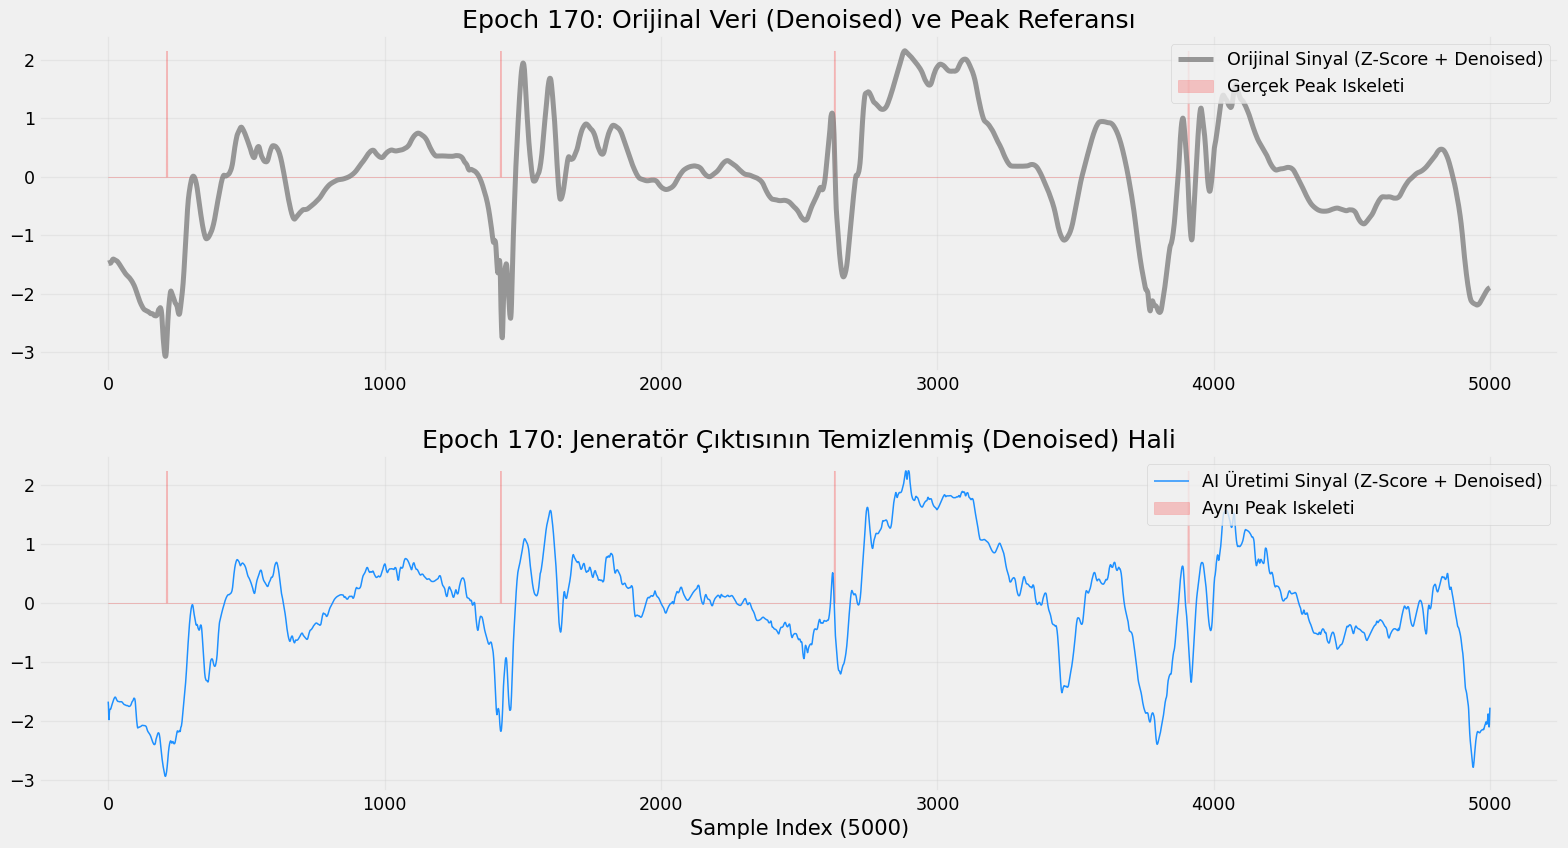

💾 Epoch 170 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 171 BAŞLADI ---
Epoch 171 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.704
Epoch 171 Özet | D_Loss: 0.0000 | G_Total: 6.22 | Rec: 7.27 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 171)
--- EPOCH 172 BAŞLADI ---
Epoch 172 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.773
Epoch 172 Özet | D_Loss: 0.0000 | G_Total: 6.25 | Rec: 7.30 | Cls: 0.95
--- EPOCH 173 BAŞLADI ---
Epoch 173 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.279
Epoch 173 Özet | D_Loss: 0.0000 | G_Total: 6.22 | Rec: 7.42 | Cls: 1.72
--- EPOCH 174 BAŞLADI ---
Epoch 174 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.833
Epoch 174 Özet | D_Loss: 0.0000 | G_Total: 6.20 | Rec: 7.25 | Cls: 1.16
Yeni En Düşük G_Loss! (Best Epoch şu an: 174)
--- EPOCH 175 BAŞLADI ---
Epoch 175 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.735
Epoch 175 Özet | D_Loss: 0.0000 | G_Total: 6.25 | Rec: 7.30 | Cls: 0.86


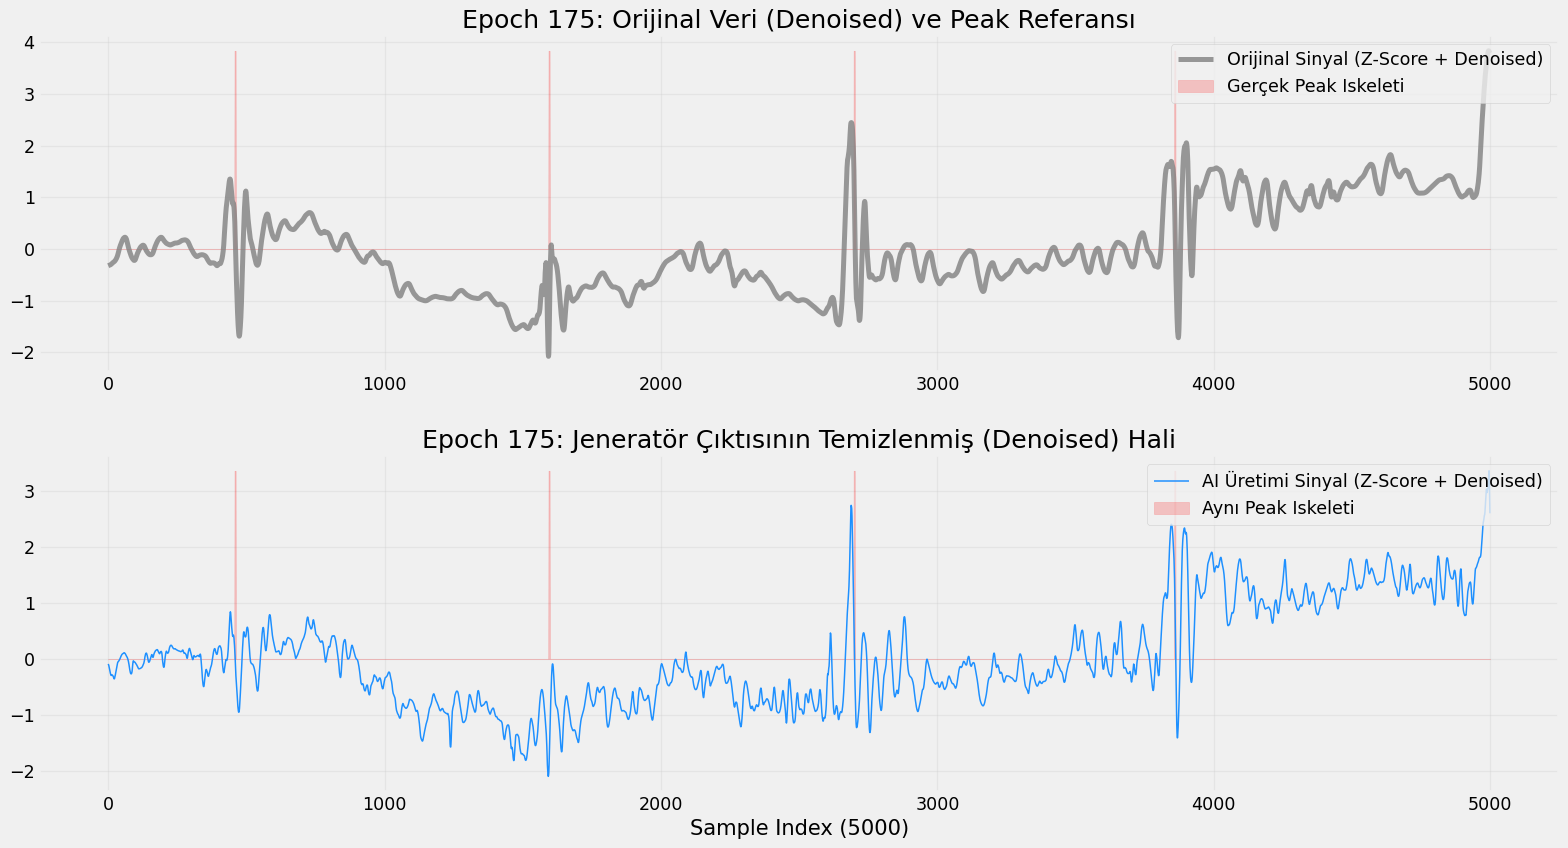

💾 Epoch 175 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 176 BAŞLADI ---
Epoch 176 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.671
Epoch 176 Özet | D_Loss: 0.0000 | G_Total: 6.19 | Rec: 7.21 | Cls: 0.93
Yeni En Düşük G_Loss! (Best Epoch şu an: 176)
--- EPOCH 177 BAŞLADI ---
Epoch 177 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.044
Epoch 177 Özet | D_Loss: 0.0116 | G_Total: 6.59 | Rec: 7.57 | Cls: 0.94
--- EPOCH 178 BAŞLADI ---
Epoch 178 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.013
Epoch 178 Özet | D_Loss: 0.0000 | G_Total: 6.32 | Rec: 7.58 | Cls: 0.86
--- EPOCH 179 BAŞLADI ---
Epoch 179 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.570
Epoch 179 Özet | D_Loss: 0.0000 | G_Total: 6.17 | Rec: 7.14 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 179)
--- EPOCH 180 BAŞLADI ---
Epoch 180 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.474
Epoch 180 Özet | D_Loss: 0.0000 | G_Total: 6.20 | Rec: 7.03 | Cls: 0.88


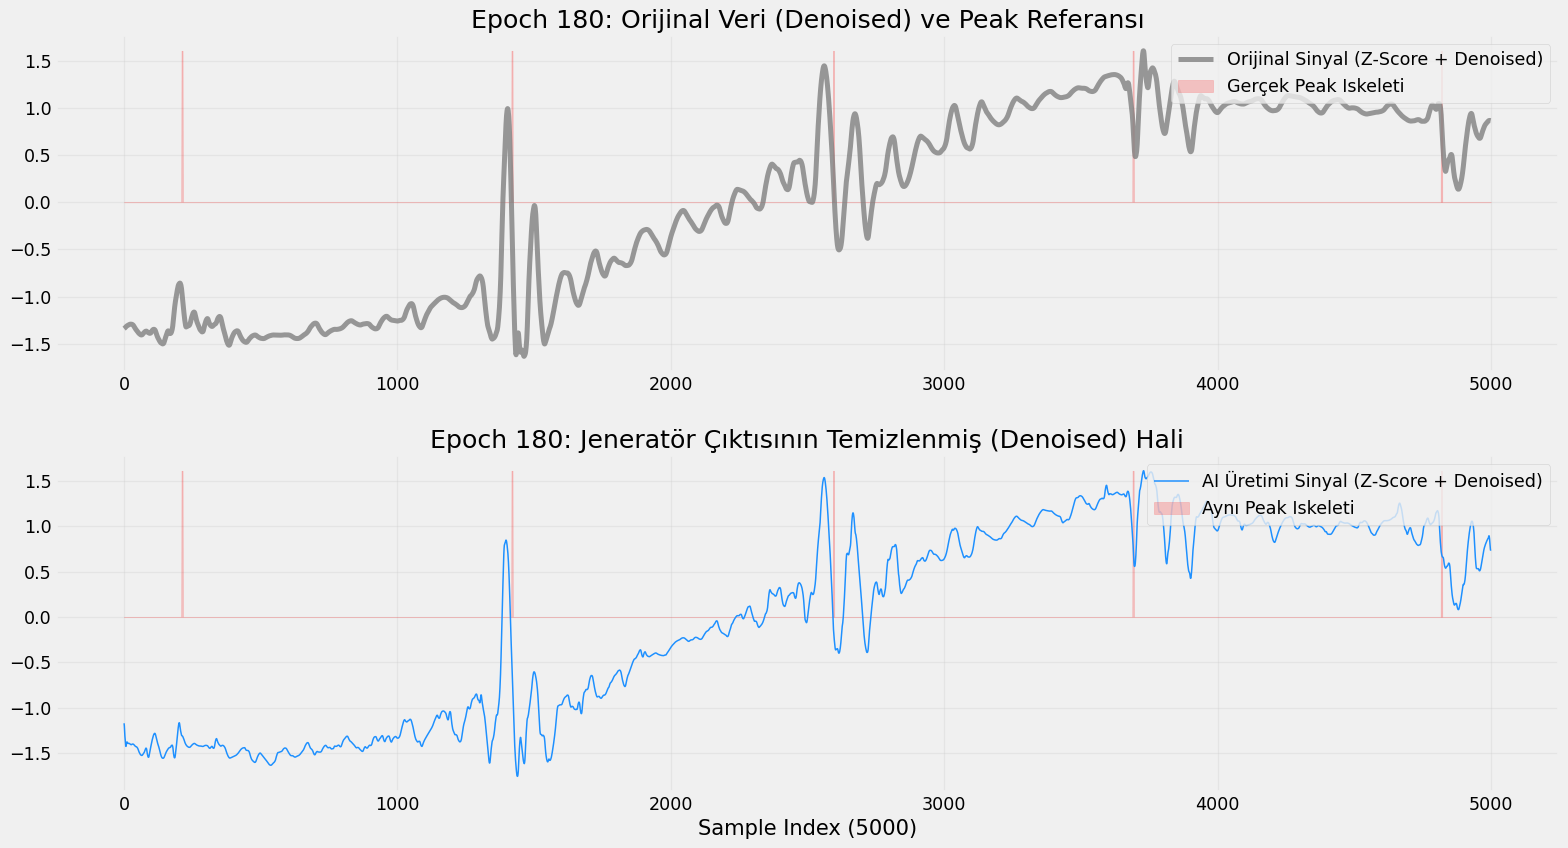

💾 Epoch 180 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 181 BAŞLADI ---
Epoch 181 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.672
Epoch 181 Özet | D_Loss: 0.0000 | G_Total: 6.17 | Rec: 7.05 | Cls: 1.25
--- EPOCH 182 BAŞLADI ---
Epoch 182 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.589
Epoch 182 Özet | D_Loss: 0.0000 | G_Total: 6.14 | Rec: 7.15 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 182)
--- EPOCH 183 BAŞLADI ---
Epoch 183 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.52
Epoch 183 Özet | D_Loss: 0.0000 | G_Total: 6.16 | Rec: 7.08 | Cls: 0.87
--- EPOCH 184 BAŞLADI ---
Epoch 184 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.574
Epoch 184 Özet | D_Loss: 0.0000 | G_Total: 6.14 | Rec: 7.14 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 184)
--- EPOCH 185 BAŞLADI ---
Epoch 185 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.504
Epoch 185 Özet | D_Loss: 0.0000 | G_Total: 6.12 | Rec: 6.93 | Cls: 1.14
Yeni En Düşük G_Loss! (Best Epoch şu an: 185)


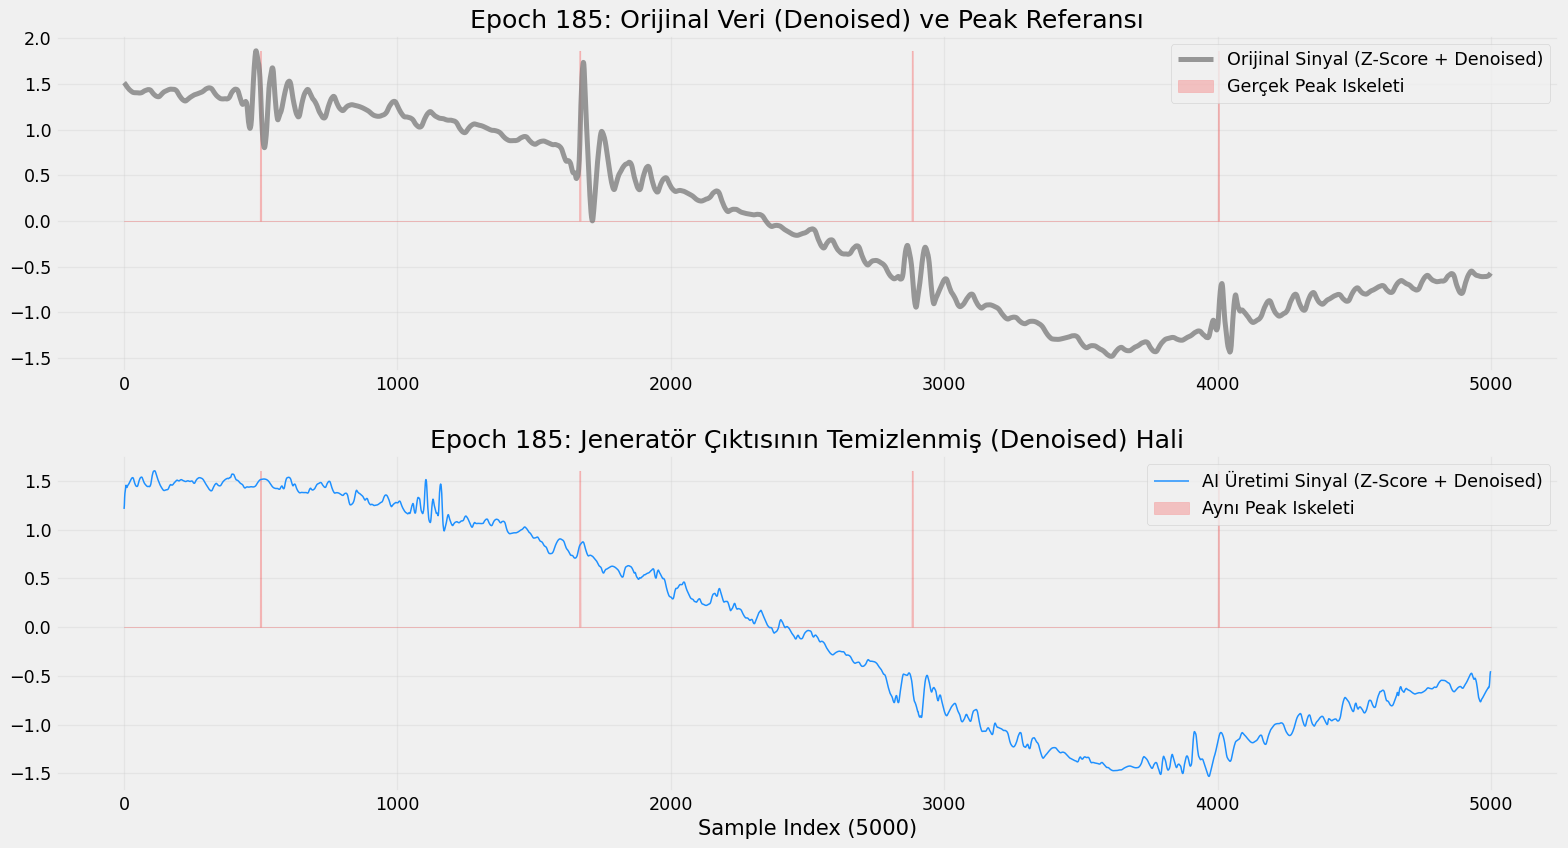

💾 Epoch 185 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 186 BAŞLADI ---
Epoch 186 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.520
Epoch 186 Özet | D_Loss: 0.0000 | G_Total: 6.13 | Rec: 7.09 | Cls: 0.86
--- EPOCH 187 BAŞLADI ---
Epoch 187 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.385
Epoch 187 Özet | D_Loss: 0.0000 | G_Total: 6.11 | Rec: 6.95 | Cls: 0.87
Yeni En Düşük G_Loss! (Best Epoch şu an: 187)
--- EPOCH 188 BAŞLADI ---
Epoch 188 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.564
Epoch 188 Özet | D_Loss: 0.0000 | G_Total: 6.07 | Rec: 7.13 | Cls: 0.86
Yeni En Düşük G_Loss! (Best Epoch şu an: 188)
--- EPOCH 189 BAŞLADI ---
Epoch 189 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.422
Epoch 189 Özet | D_Loss: 0.0000 | G_Total: 6.11 | Rec: 6.99 | Cls: 0.86
--- EPOCH 190 BAŞLADI ---
Epoch 190 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.30
Epoch 190 Özet | D_Loss: 0.0000 | G_Total: 6.07 | Rec: 6.78 | Cls: 1.03
Yeni En Düşük G_Loss! (Best Epoch şu an: 190)


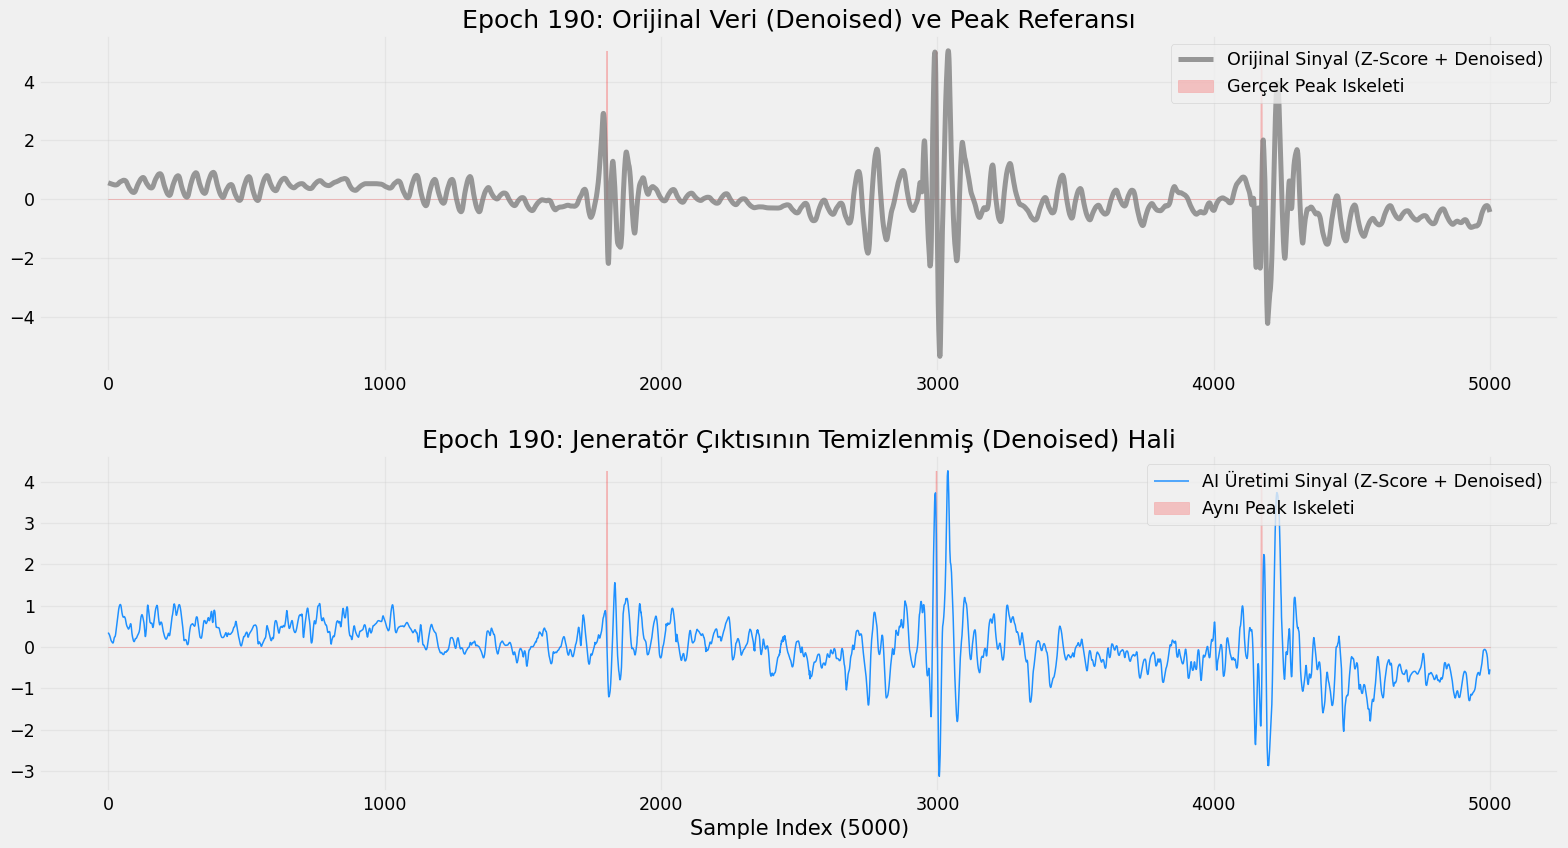

💾 Epoch 190 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 191 BAŞLADI ---
Epoch 191 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.651
Epoch 191 Özet | D_Loss: 0.0000 | G_Total: 6.04 | Rec: 7.13 | Cls: 1.03
Yeni En Düşük G_Loss! (Best Epoch şu an: 191)
--- EPOCH 192 BAŞLADI ---
Epoch 192 | Step 427/428 | D_Loss: 0.0000 | G_Total: 8.233
Epoch 192 Özet | D_Loss: 0.0000 | G_Total: 6.07 | Rec: 7.34 | Cls: 1.78
--- EPOCH 193 BAŞLADI ---
Epoch 193 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.96
Epoch 193 Özet | D_Loss: 0.0000 | G_Total: 6.09 | Rec: 7.11 | Cls: 1.70
--- EPOCH 194 BAŞLADI ---
Epoch 194 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.552
Epoch 194 Özet | D_Loss: 0.0000 | G_Total: 6.04 | Rec: 6.95 | Cls: 1.20
Yeni En Düşük G_Loss! (Best Epoch şu an: 194)
--- EPOCH 195 BAŞLADI ---
Epoch 195 | Step 427/428 | D_Loss: 0.0000 | G_Total: 7.921
Epoch 195 Özet | D_Loss: 0.0000 | G_Total: 6.04 | Rec: 7.31 | Cls: 1.21
Yeni En Düşük G_Loss! (Best Epoch şu an: 195)


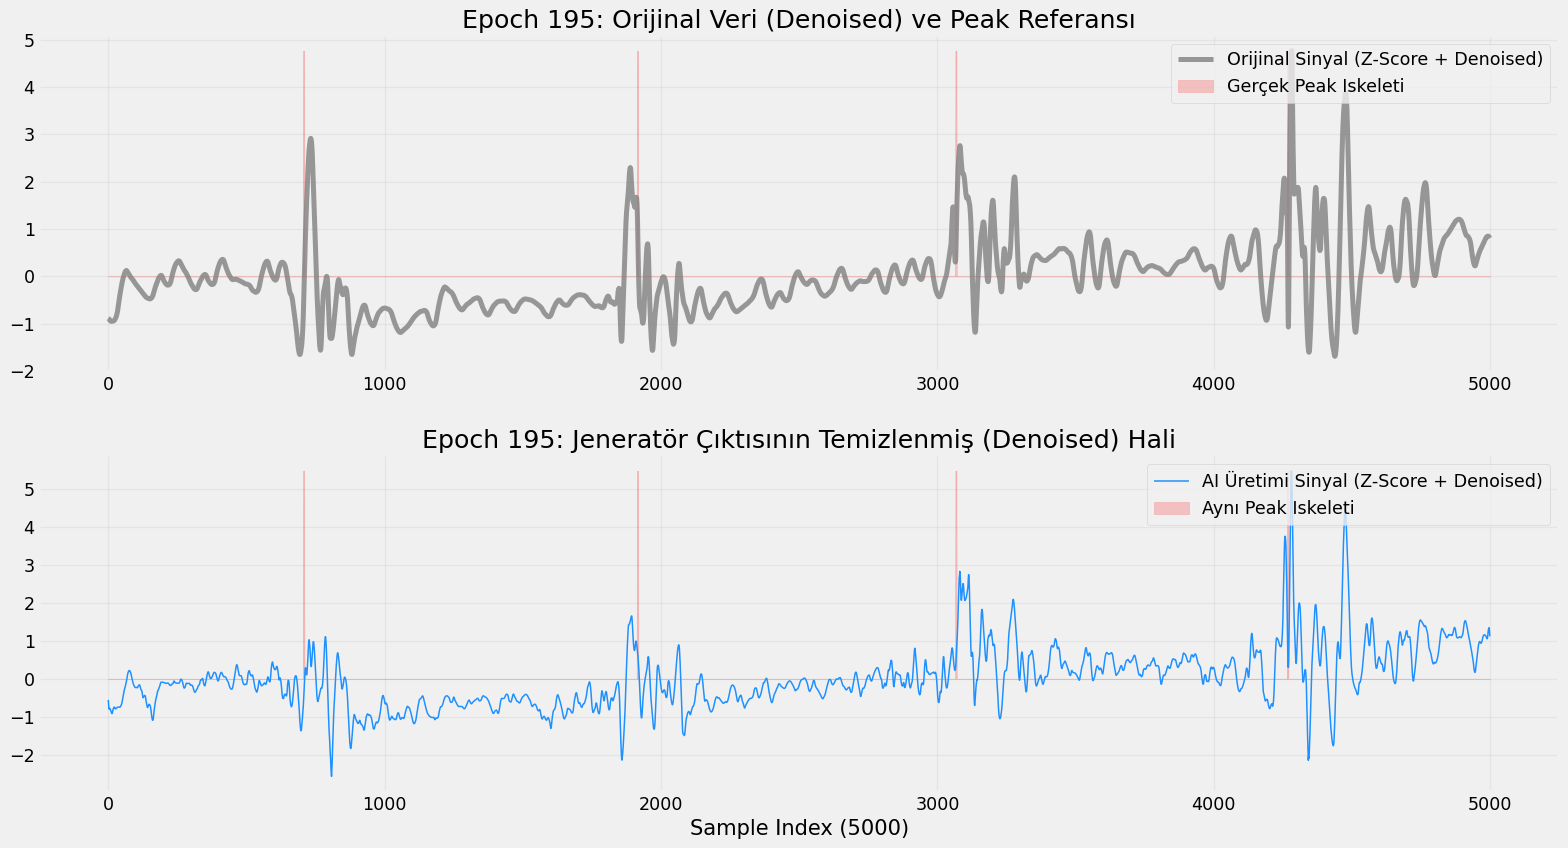

💾 Epoch 195 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 196 BAŞLADI ---
Epoch 196 | Step 344/428 | D_Loss: 0.0000 | G_Total: 4.667

In [ ]:
import time
import tensorflow as tf

EPOCHS = 500
best_g_loss = float('inf') # En düşük Generator loss'unu takip etmek için
best_epoch_num = 0

for epoch in range(EPOCHS):
    start = time.time()
    epoch_d_loss = []
    epoch_g_loss = []
    
    total_steps = len(train_seq)
    print(f"--- EPOCH {epoch+1} BAŞLADI ---")
    
    for step in range(total_steps):
        batch_data, _ = train_seq[step] 
        real_sigs = tf.convert_to_tensor(batch_data[:, :, 0:1], dtype=tf.float32)
        peaks = tf.convert_to_tensor(batch_data[:, :, 1:2], dtype=tf.float32)
        
        d_l, g_l, l_rec, l_cls = train_step(real_sigs, peaks)
        
        epoch_d_loss.append(d_l)
        epoch_g_loss.append(g_l)
        
        print(f"Epoch {epoch+1} | Step {step}/{total_steps} | D_Loss: {d_l:.4f} | G_Total: {g_l:.2f}", end='\r', flush=True)

    # Epoch ortalamaları
    avg_d_loss = tf.reduce_mean(epoch_d_loss).numpy()
    avg_g_loss = tf.reduce_mean(epoch_g_loss).numpy()
    
    print(f"\nEpoch {epoch+1} Özet | D_Loss: {avg_d_loss:.4f} | G_Total: {avg_g_loss:.2f} | Rec: {l_rec:.2f} | Cls: {l_cls:.2f}")
    
    # BEST EPOCH TAKİBİ (Matematiksel Olarak)
    if avg_g_loss < best_g_loss:
        best_g_loss = avg_g_loss
        best_epoch_num = epoch + 1
        print(f"Yeni En Düşük G_Loss! (Best Epoch şu an: {best_epoch_num})")

    # HER 5 EPOCH'TA BİR: ÇİZİM YAP VE AĞIRLIKLARI KAYDET
    if (epoch + 1) % 5 == 0:
        # 1. Çizimi model klasörüne kaydet
        visualize_epoch_results(epoch, encoder, generator, train_seq, MODEL_FOLDER)
        
        # 2. Manuel seçim yapabilmen için ağırlıkları (weights) kaydet
        enc_weight_path = os.path.join(MODEL_FOLDER, "weights", f"encoder_epoch_{epoch+1}.h5")
        gen_weight_path = os.path.join(MODEL_FOLDER, "weights", f"generator_epoch_{epoch+1}.h5")
        
        encoder.save_weights(enc_weight_path)
        generator.save_weights(gen_weight_path)
        print(f"💾 Epoch {epoch+1} görselleri ve ağırlıkları kaydedildi.")

print(f"\nEĞİTİM BİTTİ! Matematiksel Olarak En İyi Epoch: {best_epoch_num}")
print(f"Tüm ağırlıklar ve görseller '{MODEL_FOLDER}' klasöründe incelenmeyi bekliyor.")